In [1]:
from Parameterize import *
import nglview as ng

In [2]:
main_dir   = '/mnt/f/BILAYERS/CER6/gromacs_MAP2' #Main working directory, where the AA simulations are located as well
mdp_loc_BL = '/mnt/f/BILAYERS/MDPs' #This is default
mdp_loc    = '/mnt/f/AA_SIMS_WATER_IONS/MDPs'

## AA sim
GRO = 'CER6_POPC.gro'
TPR = 'CER6_POPC.tpr'
XTC = 'CER6_POPC.xtc'

I had to provide random numbers to the atoms and then include the sugars in the same resid as the rest of the lipid. I then made the simulation while with -pbc nojump, after which I wrote out every resid individually, and then cat them together again, such that I could use the pdb of just resid 1.

### Manual stuff : you will need to make the mapping and define bonds and angles. The optimization of the bonded parameters you can do iteratively

In [3]:
os.chdir(main_dir)

In [4]:
#Load atomistic universe
u = md.Universe(GRO, XTC)

In [5]:
resname = np.unique(u.select_atoms('all and not resname TIP3 POPC and not name SOD CLA').resnames)[0]

In [6]:
sel = u.select_atoms('resname {} and resid 73'.format(resname))

In [7]:
ng.show_mdanalysis(sel)

NGLWidget(max_frame=10000)

In [8]:
#Make AA sims whole for later 
#os.system('echo 0 | gmx trjconv -s {} -f {} -pbc whole -o AA_whole.xtc'.format(TPR, XTC))

### Define mapping

In [9]:
#Define manually
NOH = ['NF','HNF','C1F','OF'] #amide + carbonyl
OH  = ['C1S' , 'H1S', 'H1T', 'O1', 'HO1'] #The alcohol connecting to the sugar
GLA = ['C2F', 'H2F','O2', 'HO2', 'C3F', 'H3F','H3G'] # connected to the amide
GLB = ['C2S','H2S','C3S','C4S','H3S','O3','HO3','O4','HO4','H4S'] #two alcohols  

C1B = ['C5S','H5T','H5S','C6S','H6T','H6S','C7S','H7T','H7S','C8S','H8T','H8S','C9S','H9T','H9S']
C2B = ['C10S','H10T','H10S','C11S','H11T','H11S','C12S','H12T','H12S','C13S','H13T','H13S']
C1A = ['C5F','H5G','H5F','C6F','H6F','H6G','C7F','H7F','H7G','C8F','H8F','H8G','C9F','H9F','H9G']
C2A = ['C10F','H10F','H10G','C11F','H11F','H11G','C12F','H12F','H12G','C13F','H13F','H13G']

bead_assignments = [  NOH,   OH,     GLA,    GLB,  C1A,   C2A,   C1B,   C2B]
bead_types       = [ 'SP3d', 'TP1', 'SN4a',  'N4a', 'C1', 'C1',  'C1',  'C1']
bead_names       = [ 'NOH',  'OH',  'GLA',   'GLB', 'C1A', 'C2A', 'C1B', 'C2B']
bead_sizes       = [  'S' ,   'T',   'S',    'R'  ,  'R',   'R',   'R',   'R']
bead_charges     = [  0,      0,      0,       0,      0,     0,     0,     0]

In [10]:
flat_list = [item for sublist in bead_assignments for item in sublist]

In [11]:
all_AA_atoms = ' '.join('{}'.format(i) for i in flat_list)

In [12]:
selection_special = 'name {}'.format(all_AA_atoms)

In [13]:
selection_special

'name NF HNF C1F OF C1S H1S H1T O1 HO1 C2F H2F O2 HO2 C3F H3F H3G C2S H2S C3S C4S H3S O3 HO3 O4 HO4 H4S C5F H5G H5F C6F H6F H6G C7F H7F H7G C8F H8F H8G C9F H9F H9G C10F H10F H10G C11F H11F H11G C12F H12F H12G C13F H13F H13G C5S H5T H5S C6S H6T H6S C7S H7T H7S C8S H8T H8S C9S H9T H9S C10S H10T H10S C11S H11T H11S C12S H12T H12S C13S H13T H13S'

### Define angles, bonds, and possible dihedrals

In [14]:
#define manually
ang_tgts = [['C2A','C1A','GLA'],
            ['C1A','GLA','NOH'],
           ['GLB','NOH','OH'],
           ['NOH','OH','GLB'],
            ['OH','GLB','C1B'],
             ['OH','GLA','C1A'],
            ['GLB','C1B','C2B'],
            ['GLA','NOH','GLB'],
           ]

dist_tgts = [['C1B','C2B'],
            ['C1A','GLA'],
            ['GLA','NOH'],
            ['NOH','OH'],
             ['OH','GLB'],
            ['NOH','GLB'],
             ['GLB','C1B'],
             ['C1A','C2A']]

dihed_tgts = [['GLA','NOH','OH','GLB'],
             ['GLA','NOH','GLB','C1B'],
             ['GLB','NOH','GLA','C1A'],
             ['NOH','OH','GLB','C1B'],]

#D_ang, D_bond = make_angle_bond_dicts(ang_tgts, dist_tgts, bead_names)
D_dihed, D_ang, D_bond = make_angle_bond_dihed_dicts(ang_tgts, dist_tgts, dihed_tgts, bead_names)

bins_dihed = np.arange(-181,181,2)
bins_angl = np.arange(-1,181,2)
bins_dist = np.arange(0,15,0.2)

bins_dihed_x = (bins_dihed[1:] + bins_dihed[:-1]) / 2
bins_angl_x = (bins_angl[1:] + bins_angl[:-1]) / 2
bins_dist_x = (bins_dist[1:] + bins_dist[:-1]) / 2


List_angles = [[0],[1],[2],[3],[4],[5],[6],[7]]

List_bonds =[[0],[1],[2],[3],[4],[5],[6],[7]]

List_dihed = [[0],[1],[2],[3]]

## map from aa to cg

In [15]:
map_aa2cg(u, resname, bead_assignments, bead_names, bead_sizes, 'AA_whole.xtc', GRO)

                       :-) GROMACS - gmx traj, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2
Command line:
  gmx traj -f CER6_POPC.gro -s all_hydrogen.gro -n index.ndx -com -ng 64 -oxt cg.gro

Group     0 (  mdanalysis001) has     4 elements
Group     1 (  mdanalysis002) has     5 elements
Group     2 (  mdanalysis003) has     7 elements
Group     3 (  mdanalysis004) has    10 elements
Group     4 (  mdanalysis005) has    15 elements
Group     5 (  mdanalysis006) has    12 elements
Group     6 (  mdanalysis007) has    15 elements
Group     7 (  mdanalysis008) has    12 elements
Group     8 (  mdanalysis009) has     4 elements
Group     9 (  mdanalysis010) has     5 elements
Group    10 (  mdanalysis011) has     7 elements
Group    11 (  mdanalysis012) has    10 elements
Group    12 (  mdanalysis013) has    15 elements
Group    13 (  mdanalysis014) has    12 elements
Group    14 (  mdanalysis015) has


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

Selected 0: 'mdanalysis001'
Selected 1: 'mdanalysis002'
Selected 2: 'mdanalysis003'
Selected 3: 'mdanalysis004'
Selected 4: 'mdanalysis005'
Selected 5: 'mdanalysis006'
Selected 6: 'mdanalysis007'
Selected 7: 'mdanalysis008'
Selected 8: 'mdanalysis009'
Selected 9: 'mdanalysis010'
Selected 10: 'mdanalysis011'
Selected 11: 'mdanalysis012'
Selected 12: 'mdanalysis013'
Selected 13: 'mdanalysis014'
Selected 14: 'mdanalysis015'
Selected 15: 'mdanalysis016'
Selected 16: 'mdanalysis017'
Selected 17: 'mdanalysis018'
Selected 18: 'mdanalysis019'
Selected 19: 'mda

Group     0 (  mdanalysis001) has     4 elements
Group     1 (  mdanalysis002) has     5 elements
Group     2 (  mdanalysis003) has     7 elements
Group     3 (  mdanalysis004) has    10 elements
Group     4 (  mdanalysis005) has    15 elements
Group     5 (  mdanalysis006) has    12 elements
Group     6 (  mdanalysis007) has    15 elements
Group     7 (  mdanalysis008) has    12 elements
Group     8 (  mdanalysis009) has     4 elements
Group     9 (  mdanalysis010) has     5 elements
Group    10 (  mdanalysis011) has     7 elements
Group    11 (  mdanalysis012) has    10 elements
Group    12 (  mdanalysis013) has    15 elements
Group    13 (  mdanalysis014) has    12 elements
Group    14 (  mdanalysis015) has    15 elements
Group    15 (  mdanalysis016) has    12 elements
Group    16 (  mdanalysis017) has     4 elements
Group    17 (  mdanalysis018) has     5 elements
Group    18 (  mdanalysis019) has     7 elements
Group    19 (  mdanalysis020) has    10 elements
Group    20 (  mdana


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

Selected 0: 'mdanalysis001'
Selected 1: 'mdanalysis002'
Selected 2: 'mdanalysis003'
Selected 3: 'mdanalysis004'
Selected 4: 'mdanalysis005'
Selected 5: 'mdanalysis006'
Selected 6: 'mdanalysis007'
Selected 7: 'mdanalysis008'
Selected 8: 'mdanalysis009'
Selected 9: 'mdanalysis010'
Selected 10: 'mdanalysis011'
Selected 11: 'mdanalysis012'
Selected 12: 'mdanalysis013'
Selected 13: 'mdanalysis014'
Selected 14: 'mdanalysis015'
Selected 15: 'mdanalysis016'
Selected 16: 'mdanalysis017'
Selected 17: 'mdanalysis018'
Selected 18: 'mdanalysis019'
Selected 19: 'mda

Last frame      10000 time 1000000.000   

GROMACS reminds you: "When you get right down to it, almost every explanation Man came up with for anything until about 1926 was stupid." (Dave Barry)



### initial SASA

In [16]:
CG  = ['cg_good.gro', #GRO
       'cg.xtc']      #XTC
AA = [GRO,XTC]

In [17]:
os.chdir(main_dir)
run_SASA('CG', CG, resname, main_dir, bead_names, bead_sizes)

/home/ltr/anaconda3/envs/jupyter_env/lib/python3.10/site-packages/MDAnalysis/coordinates/XDR.py:240: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn("Reload offsets from trajectory\n "
                       :-) GROMACS - gmx sasa, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG
Command line:
  gmx sasa -f ../cg.xtc -s ../cg_good.gro -n /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG/index.ndx -ndots 4800 -probe 0.191 -or /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG/resarea_SASA.xvg -o /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG/SASA.xvg


++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
Frank Eisenhaber and Philip Lijnzaad and Patrick Argos and Chris Sander and
Michael Scharf
The Double Cube Lattice Method: Efficient Approaches to Numerical Integration
of Surface Area and Volume and to Dot Surface Contouring of Molecular
Assemblies
J. Comp. Chem. 16 (1995) pp. 273-2

entering /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG

         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

NOTE: From version 5.0 gmx sasa uses the Van der Waals radii
from the 

Reading frame    9000 time 900000.000   


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

NOTE: From version 5.0 gmx sasa uses the Van der Waals radii
from the source below. This means the results may be di

Last frame      10000 time 1000000.000   

Back Off! I just backed up /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG/resarea_SASA.xvg to /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG/#resarea_SASA.xvg.3#
Analyzed 10001 frames, last time 1000000.000

GROMACS reminds you: "Bad As This Shit Is, This Shit Ain't As Bad As You Think It Is." (Jackie Brown)

                       :-) GROMACS - gmx sasa, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG
Command line:
  gmx sasa -s gro.gro -o temp.xvg -probe 0.191 -ndots 240 -q surface.pdb


++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
Frank Eisenhaber and Philip Lijnzaad and Patrick Argos and Chris Sander and
Michael Scharf
The Double Cube Lattice Method: Efficient Approaches to Numerical Integration
of Surface Area and Volume and to Dot Surface Contouring of Molecular
Assemblies
J. Comp. Chem. 16 (1995) pp. 273-284
-------- -------- --- Thank You --- -------- ------

In [18]:
os.chdir(main_dir)
run_SASA('AA', AA, resname, main_dir, bead_names, bead_sizes, selection=selection_special)
#Im only mapping the sugars and linker, so Im only doing the SASA calculation of the beads Im mapping for comparison. 

cp: cannot stat '/data1/lisbeth/Params/Pzifer_alcoholamine/7_SASA_longer_bonds/vdwradii_AllAtom_rowland.dat': No such file or directory
                       :-) GROMACS - gmx sasa, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/AA
Command line:
  gmx sasa -f ../CER6_POPC.xtc -s ../CER6_POPC.gro -n /mnt/f/BILAYERS/CER6/gromacs_MAP2/AA/index.ndx -ndots 4800 -probe 0.191 -or /mnt/f/BILAYERS/CER6/gromacs_MAP2/AA/resarea_SASA.xvg -o /mnt/f/BILAYERS/CER6/gromacs_MAP2/AA/SASA.xvg



entering /mnt/f/BILAYERS/CER6/gromacs_MAP2/AA



++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
Frank Eisenhaber and Philip Lijnzaad and Patrick Argos and Chris Sander and
Michael Scharf
The Double Cube Lattice Method: Efficient Approaches to Numerical Integration
of Surface Area and Volume and to Dot Surface Contouring of Molecular
Assemblies
J. Comp. Chem. 16 (1995) pp. 273-284
-------- -------- --- Thank You --- -------- --------

Reading frame       0 time    0.000   
Back Off! I just backed up /mnt/f/BILAYERS/CER6/gromacs_MAP2/AA/SASA.xvg to /mnt/f/BILAYERS/CER6/gromacs_MAP2/AA/#SASA.xvg.3#
Reading frame       7 time  700.000   


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

NOTE: From version 5.0 gmx sasa uses the Van der Waals radii
from the source below. This means the results may be di

Reading frame    9000 time 900000.000   


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

NOTE: From version 5.0 gmx sasa uses the Van der Waals radii
from the source below. This means the results may be di

Last frame      10000 time 1000000.000   

Back Off! I just backed up /mnt/f/BILAYERS/CER6/gromacs_MAP2/AA/resarea_SASA.xvg to /mnt/f/BILAYERS/CER6/gromacs_MAP2/AA/#resarea_SASA.xvg.3#
Analyzed 10001 frames, last time 1000000.000

GROMACS reminds you: "The last good thing written in C was Franz Schubert's Symphony Number 9." (Erwin Dieterich)

                       :-) GROMACS - gmx sasa, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/AA
Command line:
  gmx sasa -s gro.gro -o temp.xvg -probe 0.191 -ndots 240 -q surface.pdb


++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
Frank Eisenhaber and Philip Lijnzaad and Patrick Argos and Chris Sander and
Michael Scharf
The Double Cube Lattice Method: Efficient Approaches to Numerical Integration
of Surface Area and Volume and to Dot Surface Contouring of Molecular
Assemblies
J. Comp. Chem. 16 (1995) pp. 273-284
-------- -------- --- Thank You --- ---

SASA AA: [10.246  0.666]
SASA CG: [9.665 0.656]
percent difference between the models.
5.670505563146611


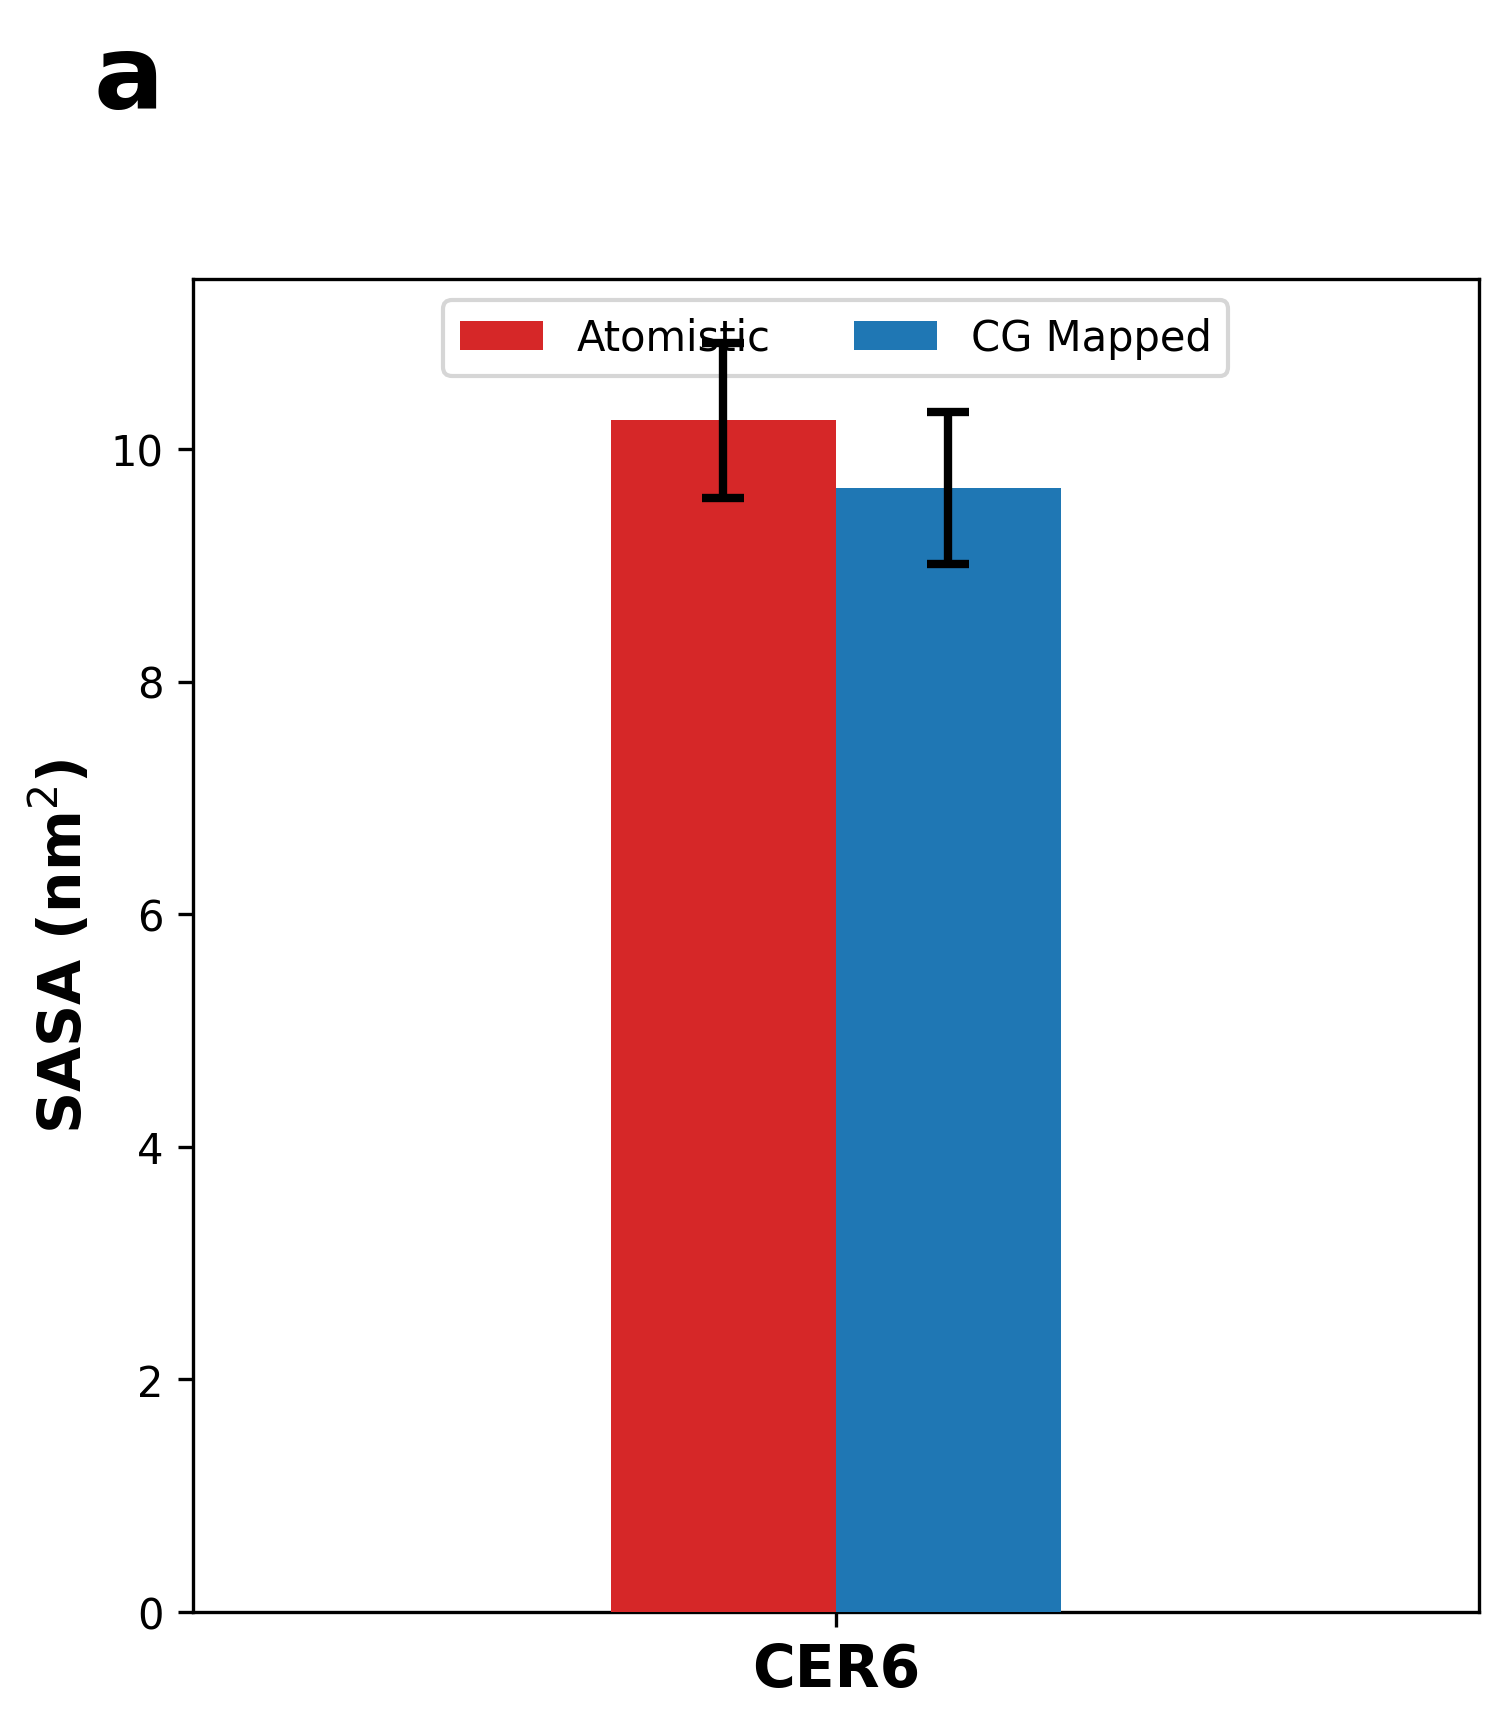

In [19]:
CG_xvg = '{}/CG/resarea_SASA.xvg'.format(main_dir)
AA_xvg = '{}/AA/resarea_SASA.xvg'.format(main_dir)

SASA_CG, SASA_AA =  plot_SASA(AA_xvg, CG_xvg, resname)

## CG in water w. 0.15 M NaCl

In [20]:
#os.mkdir('CG_WAT')
os.chdir('{}/CG_WAT'.format(main_dir))
#os.system('cp ../cg_good.gro .') 

### write an initial itp CG

In [21]:
# # #Write an initial CG itp file. You will of course need to set bond lengt, angles and so forth, but the rest is there
# write_initial_CGitp2(resname,
#     bead_names,
#     bead_sizes,
#     bead_types,
#     bead_charges,
#     D_bond,
#     D_ang,
#     D_dihed,
#     dist_tgts,
#     ang_tgts,
#     dihed_tgts)

In [22]:
!rm *tpr

rm: cannot remove '*tpr': No such file or directory


#### Setup sydtem and run for a small period of time

In [23]:
mdp_loc

'/mnt/f/AA_SIMS_WATER_IONS/MDPs'

In [24]:
prepare_setup_water(mdp_loc)
#re_run(resname, mdp_loc, maxwarn=5)
## Removed the dihedral section from the itp 

                     :-) GROMACS - gmx editconf, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT
Command line:
  gmx editconf -f res.gro -o box.gro -box 5 5 5 -bt cubic


Back Off! I just backed up box.gro to ./#box.gro.1#

GROMACS reminds you: "Above all, don't fear difficult moments. The best comes from them." (Rita Levi-Montalcini)

                     :-) GROMACS - gmx solvate, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT
Command line:
  gmx solvate -cp box.gro -cs /mnt/f/AA_SIMS_WATER_IONS/MDPs/water.gro -o watered.gro -p topol.top

Reading solute configuration
Reading solvent configuration

Initialising inter-atomic distances...
Generating solvent configuration
Will generate new solvent configuration of 1x1x1 boxes
Solvent box contains 1260 atoms in 1260 residues
Removed 66 solvent atoms due t

Note that major changes are planned in future for editconf, to improve usability and utility.
Read 8 atoms
Volume: 202.862 nm^3, corresponds to roughly 91200 electrons
No velocities found
    system size :  0.963  0.954  0.840 (nm)
    diameter    :  1.241               (nm)
    center      :  3.049  1.412  4.854 (nm)
    box vectors :  5.082  5.082  7.855 (nm)
    box angles  :  90.00  90.00  90.00 (degrees)
    box volume  : 202.86               (nm^3)
    shift       : -0.549  1.088 -2.354 (nm)
new center      :  2.500  2.500  2.500 (nm)
new box vectors :  5.000  5.000  5.000 (nm)
new box angles  :  90.00  90.00  90.00 (degrees)
new box volume  : 125.00               (nm^3)

         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this function


Output configuration contains 1201 atoms in 1194 residues
Volume                 :         125 (nm^3)
Density                :      2914.9 (g/l)
Number of solvent molecules:   1193   

Processing topology

Back Off! I just backed up topol.top to ./#topol.top.1#

GROMACS reminds you: "Above all, don't fear difficult moments. The best comes from them." (Rita Levi-Montalcini)

                      :-) GROMACS - gmx grompp, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT
Command line:
  gmx grompp -f /mnt/f/AA_SIMS_WATER_IONS/MDPs/min.mdp -c watered.gro -p topol.top -o memion.tpr -maxwarn 1

Ignoring obsolete mdp entry 'title'
Ignoring obsolete mdp entry 'cpp'
Ignoring obsolete mdp entry 'ns_type'
Replacing old mdp entry 'unconstrained_start' by 'continuation'
Replacing old mdp entry 'nstxtcout' by 'nstxout-compressed'
Replacing old mdp entry 'xtc_precision' by 'compressed-x-precision'

NOTE 1 [f

Adding line for 1193 solvent molecules with resname (W) to topology file (topol.top)


Number of degrees of freedom in T-Coupling group System is 3600.00
The integrator does not provide a ensemble temperature, there is no system ensemble temperature

NOTE 3 [file /mnt/f/AA_SIMS_WATER_IONS/MDPs/min.mdp]:
  COM removal frequency is set to (1).
  Other settings require a global communication frequency of 100.
  Note that this will require additional global communication steps,
  which will reduce performance when using multiple ranks.
  Consider setting nstcomm to a multiple of 100.


There were 3 NOTEs

GROMACS reminds you: "Life in the streets is not easy" (Marky Mark)

                      :-) GROMACS - gmx genion, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT
Command line:
  gmx genion -s memion.tpr -o memion.gro -p topol.top -pname NA -pq +1 -nname CL -nq -1 -neutral

Reading file memion.tpr, VERSION 2023.1 (single precision)
Reading file memion.tpr, VERSION 2023.1 (single p

...


Step 100  Warning: pressure scaling more than 1%, mu: 1.01779 1.01779 1.01779
step 999900, remaining wall clock time:     0 s          
Writing final coordinates.

Back Off! I just backed up r.gro to ./#r.gro.1#
step 1000000, remaining wall clock time:     0 s          
               Core t (s)   Wall t (s)        (%)
       Time:      780.305       78.041      999.9
                 (ns/day)    (hour/ns)
Performance:    11071.049        0.002

GROMACS reminds you: "I wanted to make a clever chemistry joke, but the best ones Argon." (39.948)

                      :-) GROMACS - gmx grompp, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT
Command line:
  gmx grompp -f /mnt/f/AA_SIMS_WATER_IONS/MDPs/run.mdp -c r.gro -p topol.top -o p.tpr -maxwarn 5

Ignoring obsolete mdp entry 'title'
Ignoring obsolete mdp entry 'ns_type'
Replacing old mdp entry 'nstxtcout' by 'nstxout-compressed'
Replacing old 

Setting the LD random seed to -1478542361

Generated 844 of the 356590 non-bonded parameter combinations

Excluding 1 bonded neighbours molecule type 'CER6'

Excluding 1 bonded neighbours molecule type 'W'

Excluding 1 bonded neighbours molecule type 'NA'

Excluding 1 bonded neighbours molecule type 'CL'
Analysing residue names:
There are:  1194      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...

Determining Verlet buffer for a tolerance of 0.002 kJ/mol/ps at 310 K

Calculated rlist for 1x1 atom pair-list as 1.335 nm, buffer size 0.235 nm

Set rlist, assuming 4x4 atom pair-list, to 1.258 nm, buffer size 0.158 nm

Note that mdrun will redetermine rlist based on the actual pair-list setup

This run will generate roughly 29 Mb of data


starting mdrun 'one molecule in water'
50000000 steps, 1000000.0 ps.
step 49999900, remaining wall clock time:     0 s          
Writing final coordinates.

Back Off! I just backed up p.gro to ./#p.gro.1#
step 50000000, remaining wall clock time:     0 s          
               Core t (s)   Wall t (s)        (%)
       Time:    36843.298     3684.341     1000.0
                         1h01:24
                 (ns/day)    (hour/ns)
Performance:    23450.602        0.001

GROMACS reminds you: "On the East coast, a purple patch, to show where the jolly pioneers of progress drink the jolly lager-beer" (Joseph Conrad)

                     :-) GROMACS - gmx trjconv, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT
Command line:
  gmx trjconv -f p.xtc -s p.tpr -o pbc.xtc -pbc mol

Will write xtc: Compressed trajectory (portable xdr format): xtc
Reading file p.tpr, VERSION 2023.1 (single precision)
R

Note that major changes are planned in future for trjconv, to improve usability and utility.
Select group for output
Selected 2: 'CER6'
Note that major changes are planned in future for trjconv, to improve usability and utility.
Select group for output
Selected 2: 'CER6'


Last frame       5000 time 1000000.000    ->  frame   4999 time 999800.000      
 ->  frame   5000 time 1000000.000      
Last written: frame   5000 time 1000000.000


GROMACS reminds you: "You Look Better Upside Down" (Throwing Muses)

                     :-) GROMACS - gmx trjconv, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT
Command line:
  gmx trjconv -f p.xtc -s p.tpr -o pbc.gro -pbc mol -b 0 -e 0

Will write gro: Coordinate file in Gromos-87 format
Reading file p.tpr, VERSION 2023.1 (single precision)
Reading file p.tpr, VERSION 2023.1 (single precision)
Group     0 (         System) has  1201 elements
Group     1 (          Other) has  1201 elements
Group     2 (           CER6) has     8 elements
Group     3 (              W) has  1185 elements
Group     4 (            ION) has     8 elements
Reading frame       0 time    0.000   
Precision of p.xtc is 0.01 (nm)

Back Off! I just bac

In [25]:
    ###Correct for the PBC
    p = subprocess.Popen('gmx trjconv -f p.xtc -s p.tpr -o pbc.gro -pbc mol -b 0 -e 0'
                         , stdin=subprocess.PIPE, shell=True, universal_newlines=True)
    p.communicate(resname)
    p.wait()
    ###Correct for the PBC
    p = subprocess.Popen('gmx trjconv -f p.xtc -s p.tpr -o pbc.xtc -pbc mol'
                         , stdin=subprocess.PIPE, shell=True, universal_newlines=True)
    p.communicate(resname)
    p.wait()


                     :-) GROMACS - gmx trjconv, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT
Command line:
  gmx trjconv -f p.xtc -s p.tpr -o pbc.gro -pbc mol -b 0 -e 0

Will write gro: Coordinate file in Gromos-87 format
Reading file p.tpr, VERSION 2023.1 (single precision)
Reading file p.tpr, VERSION 2023.1 (single precision)
Group     0 (         System) has  1201 elements
Group     1 (          Other) has  1201 elements
Group     2 (           CER6) has     8 elements
Group     3 (              W) has  1185 elements
Group     4 (            ION) has     8 elements
Reading frame       0 time    0.000   
Precision of p.xtc is 0.01 (nm)

Back Off! I just backed up pbc.gro to ./#pbc.gro.2#
Last frame          0 time    0.000   
 ->  frame      0 time    0.000      
Last written: frame      0 time    0.000


GROMACS reminds you: "You Look Better Upside Down" (Throwing Muses)

                

Note that major changes are planned in future for trjconv, to improve usability and utility.
Select group for output
Selected 2: 'CER6'


Reading frame    4000 time 800000.000    ->  frame   3999 time 799800.000      

Note that major changes are planned in future for trjconv, to improve usability and utility.
Select group for output
Selected 2: 'CER6'


Last frame       5000 time 1000000.000    ->  frame   4999 time 999800.000      
 ->  frame   5000 time 1000000.000      
Last written: frame   5000 time 1000000.000


GROMACS reminds you: "Millions saw the apple fall, Newton was the only one who asked why?" (Bernard Baruch)



0

### Measure bonded parameters

this is iterative. There is a re_run fucntion, to use for when you have optimized the parameters

In [26]:
#os.chdir('CG_WAT')
## Open AA   
u_aa = md.Universe('../cg_good.gro',
                   '../cg.xtc')

## Open CG
u_cg = md.Universe('pbc.gro', 'pbc.xtc')


/home/ltr/anaconda3/envs/jupyter_env/lib/python3.10/site-packages/MDAnalysis/coordinates/XDR.py:240: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn("Reload offsets from trajectory\n "


In [27]:
#ang_hist_aa, dist_hist_aa, ang_aa, dist_aa = measure_bonded_terms_simple(dist_tgts, ang_tgts, u_aa, bead_names, resname, 'AA', stride=10)
ang_hist_aa, dist_hist_aa, dihed_hist_aa, ang_aa, dist_aa, dihed_aa   = measure_bonded_terms(dist_tgts, ang_tgts, dihed_tgts, u_aa, bead_names, resname, 'AA', stride=10)

Calculating distributions...


  0%|          | 0/8 [00:00<?, ?it/s]

In [28]:
#ang_hist_cg, dist_hist_cg, ang_cg, dist_cg = measure_bonded_terms_simple(dist_tgts, ang_tgts, u_cg, bead_names, resname, 'CG', stride=10)
ang_hist_cg, dist_hist_cg, dihed_hist_cg, ang_cg, dist_cg, dihed_cg = measure_bonded_terms(dist_tgts, ang_tgts, dihed_tgts, u_cg, bead_names, resname, 'CG', stride=10)

Calculating distributions...


  0%|          | 0/1 [00:00<?, ?it/s]

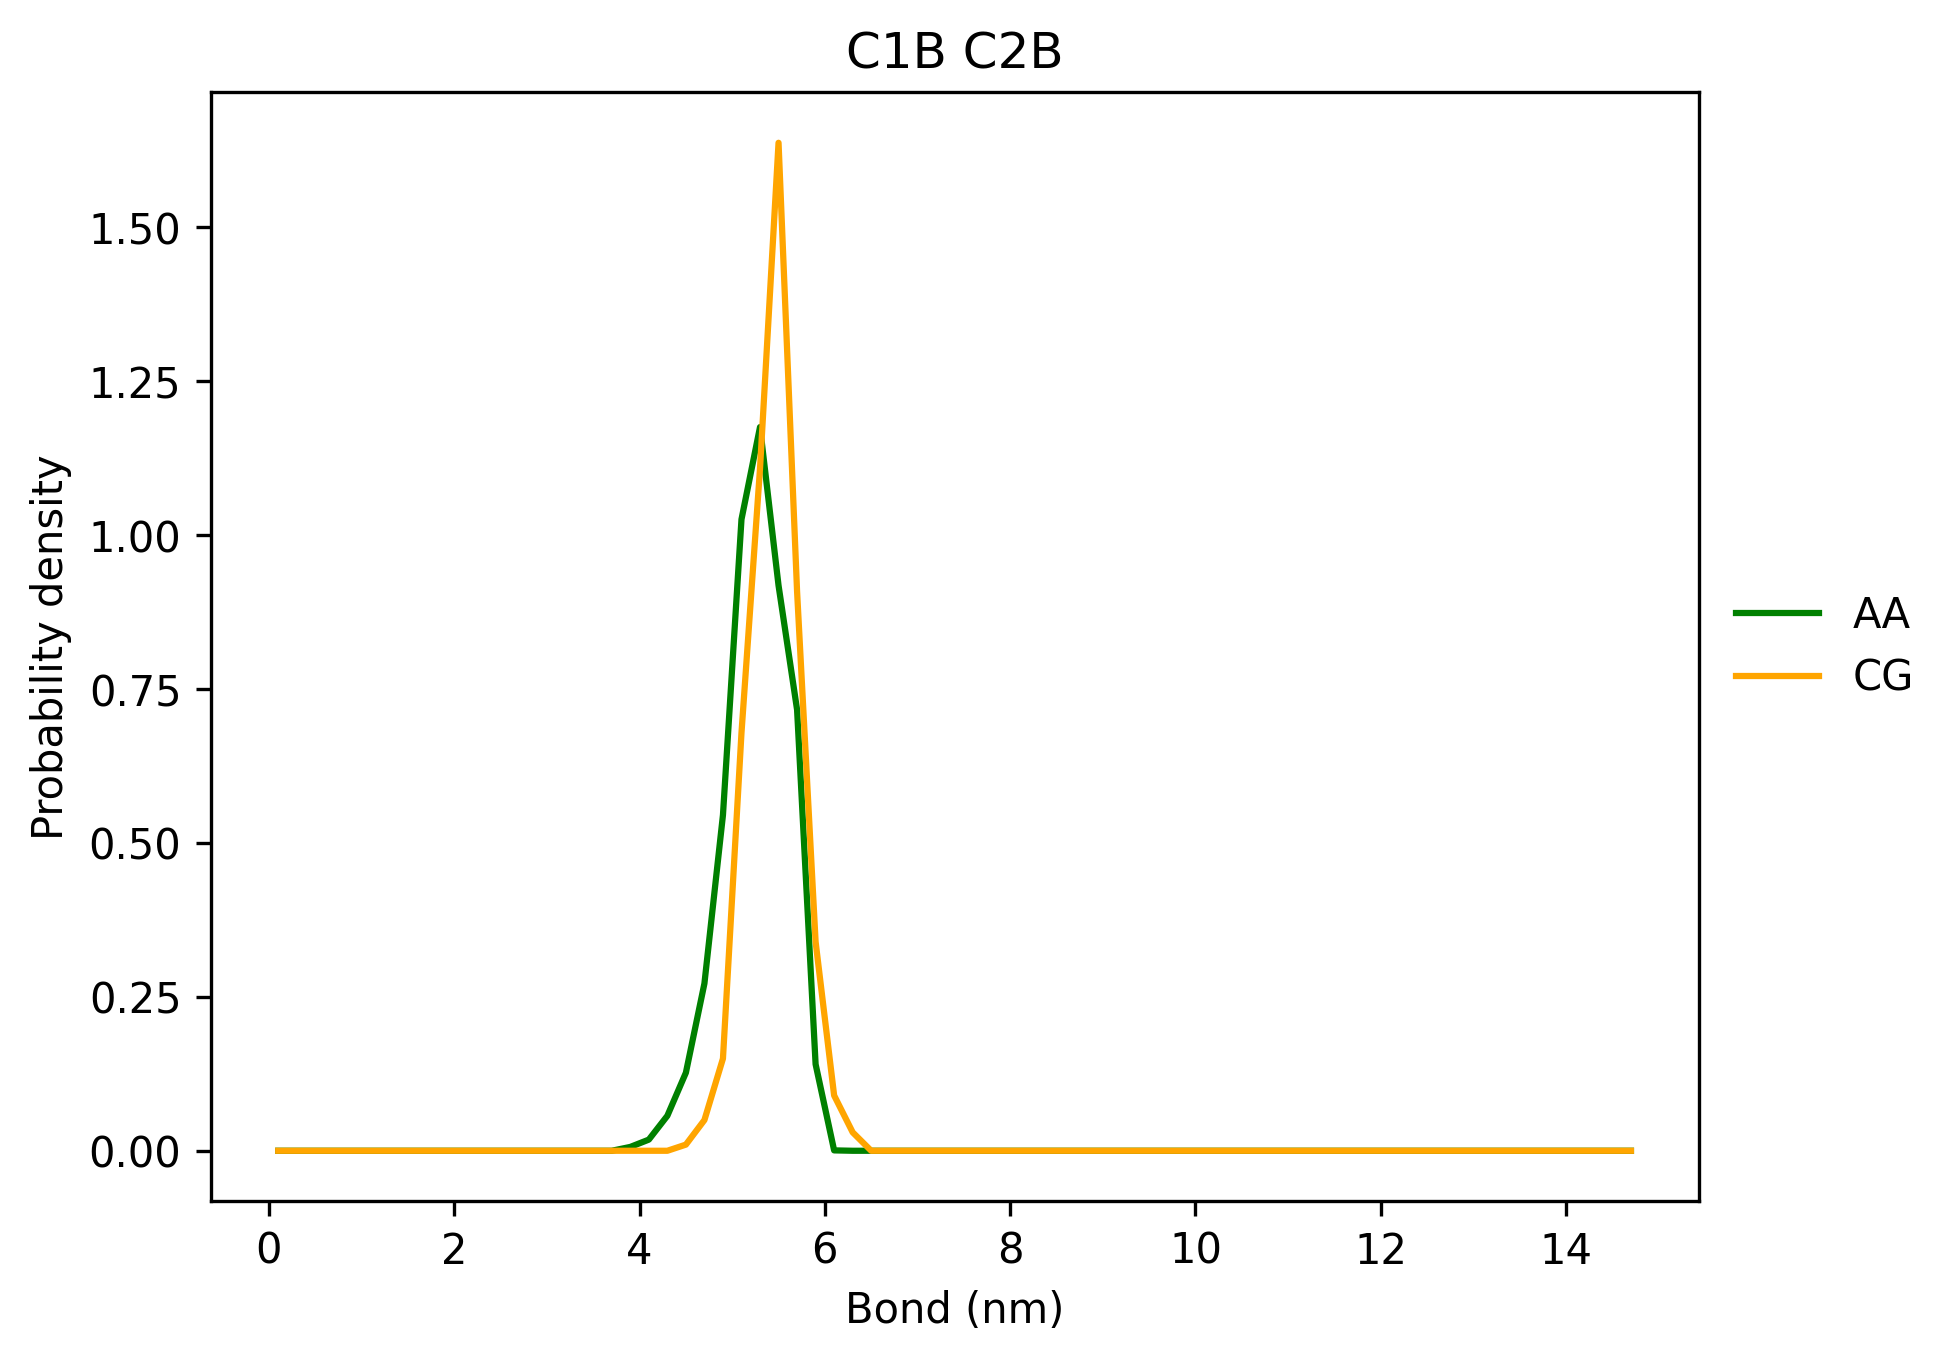

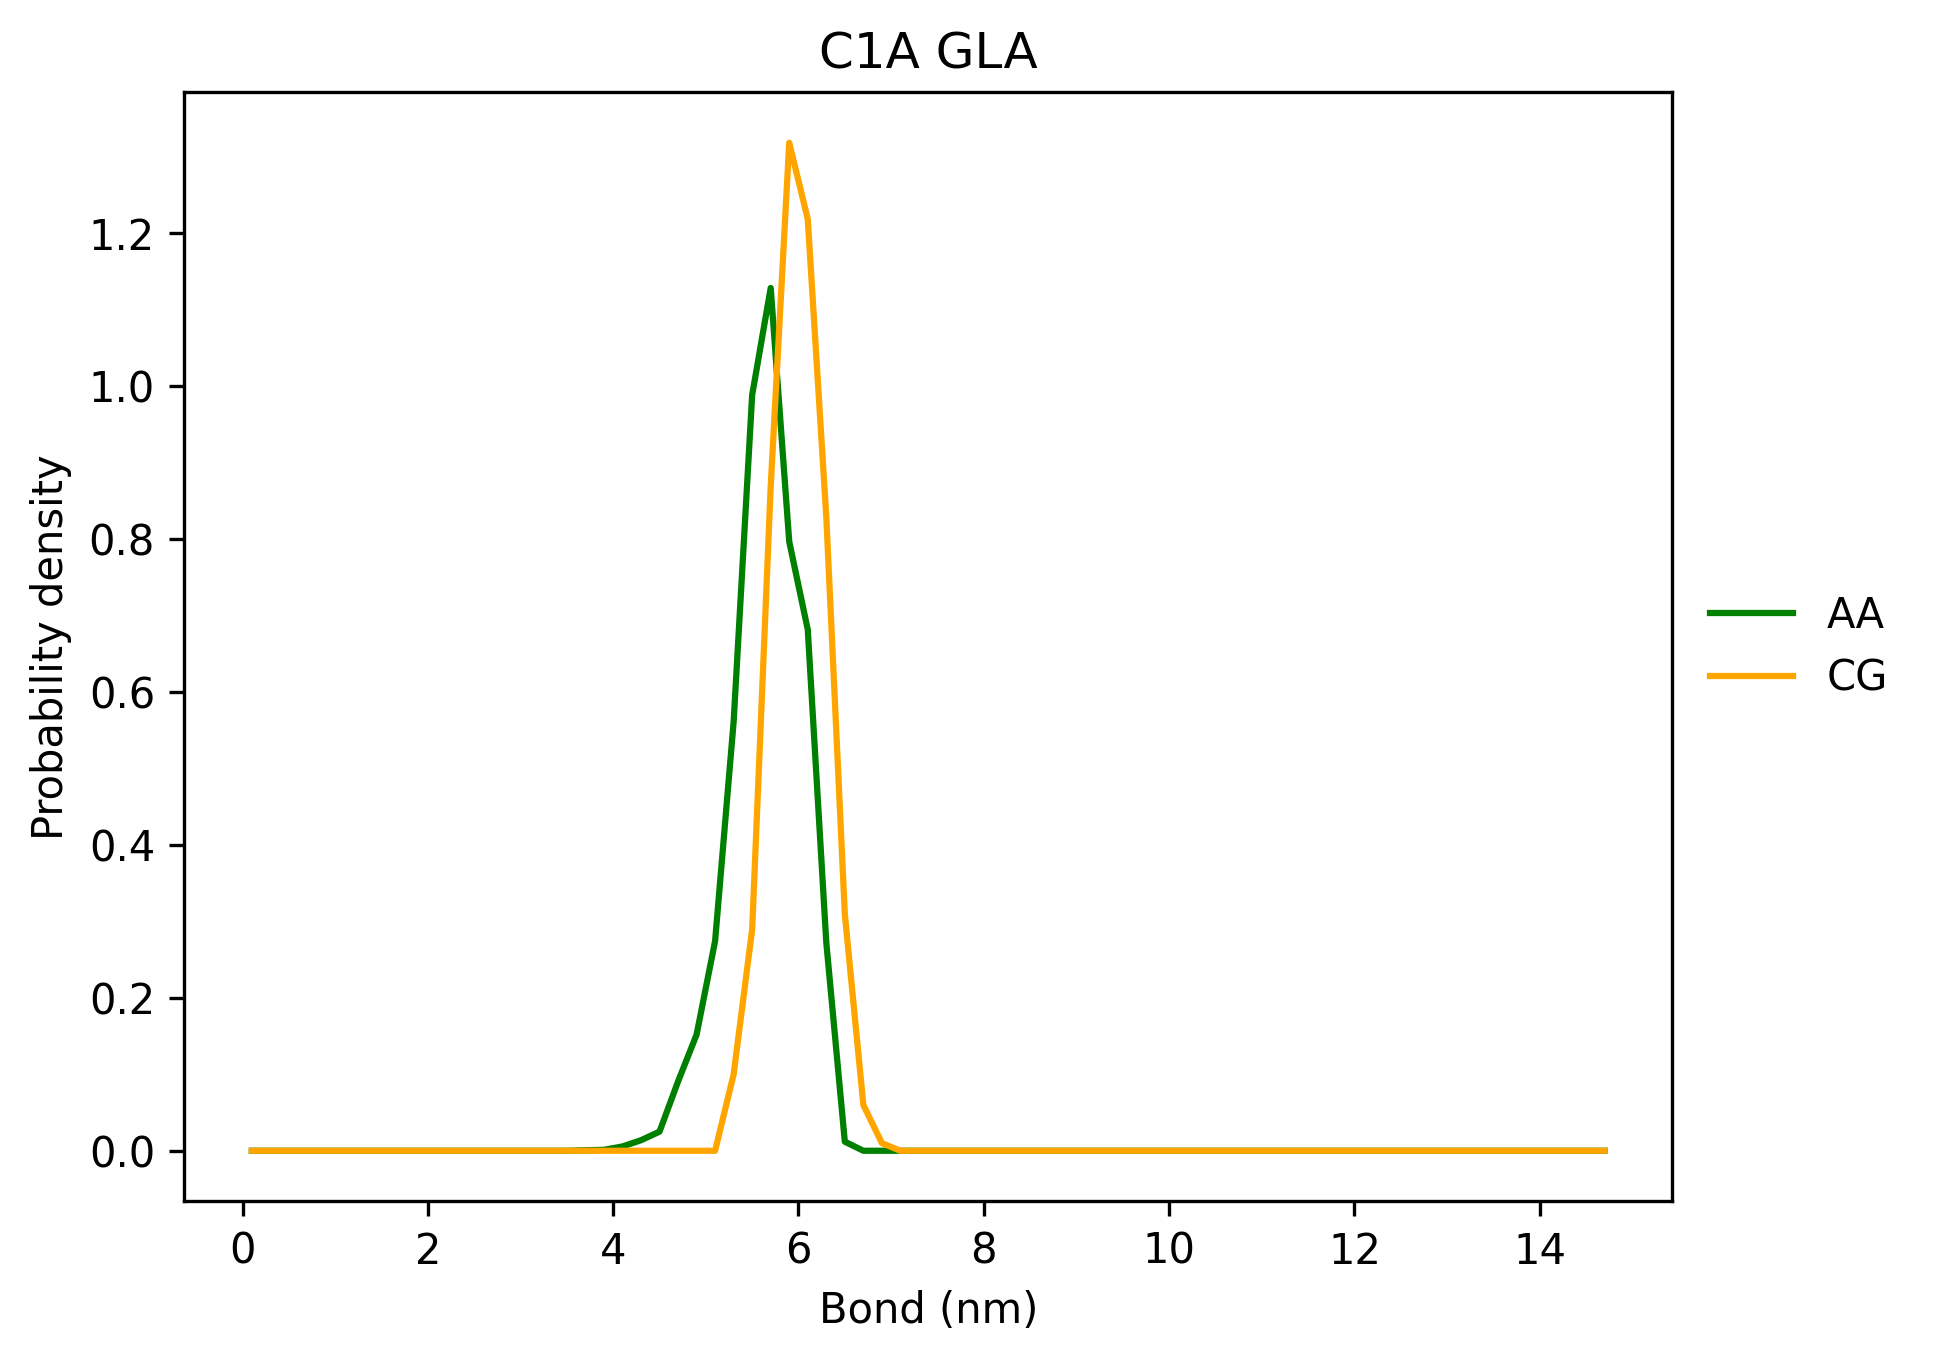

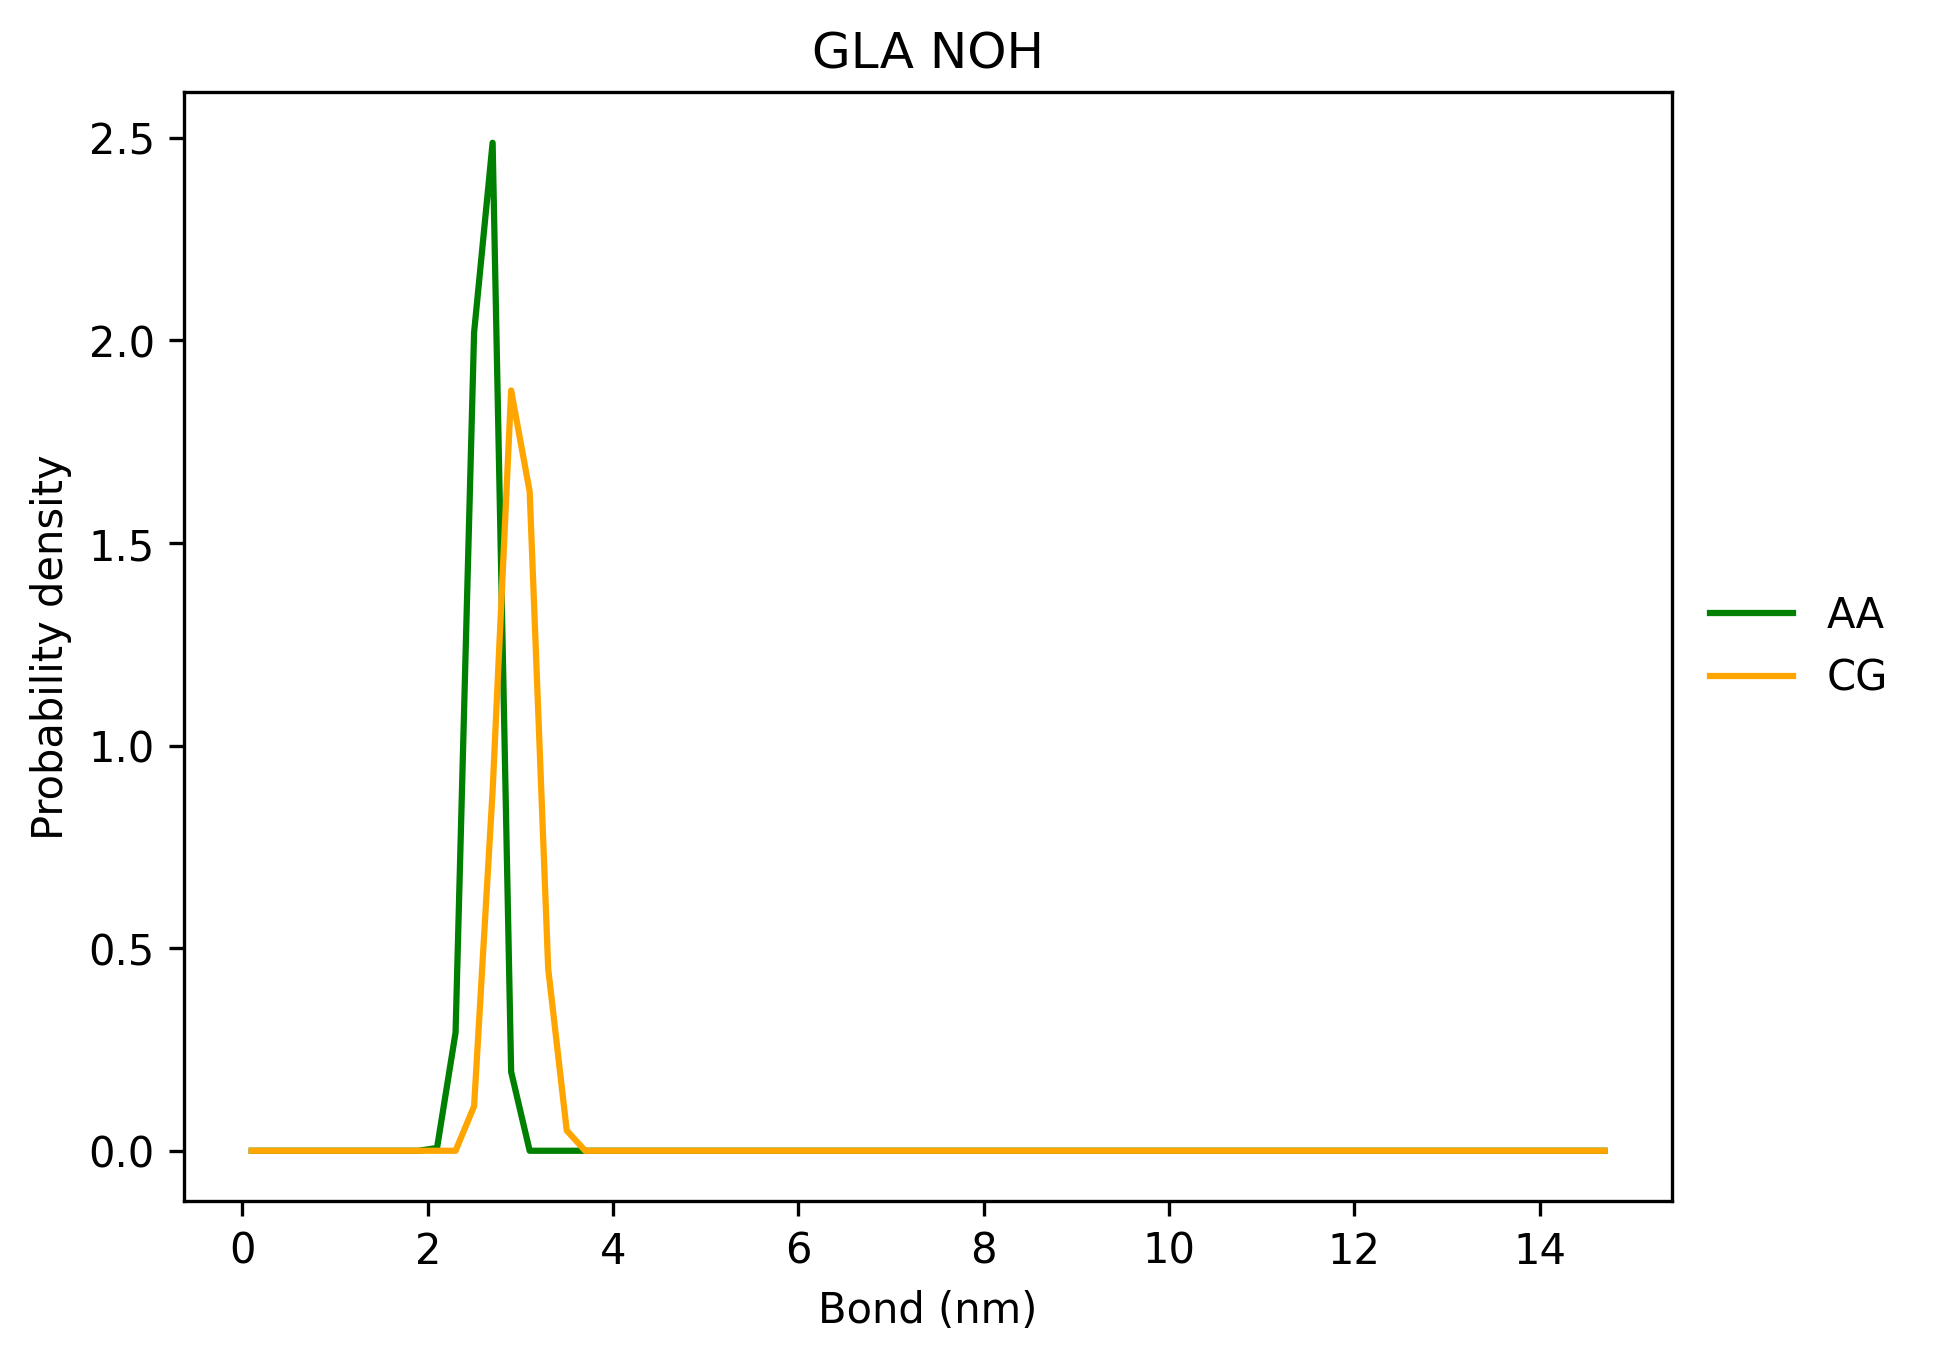

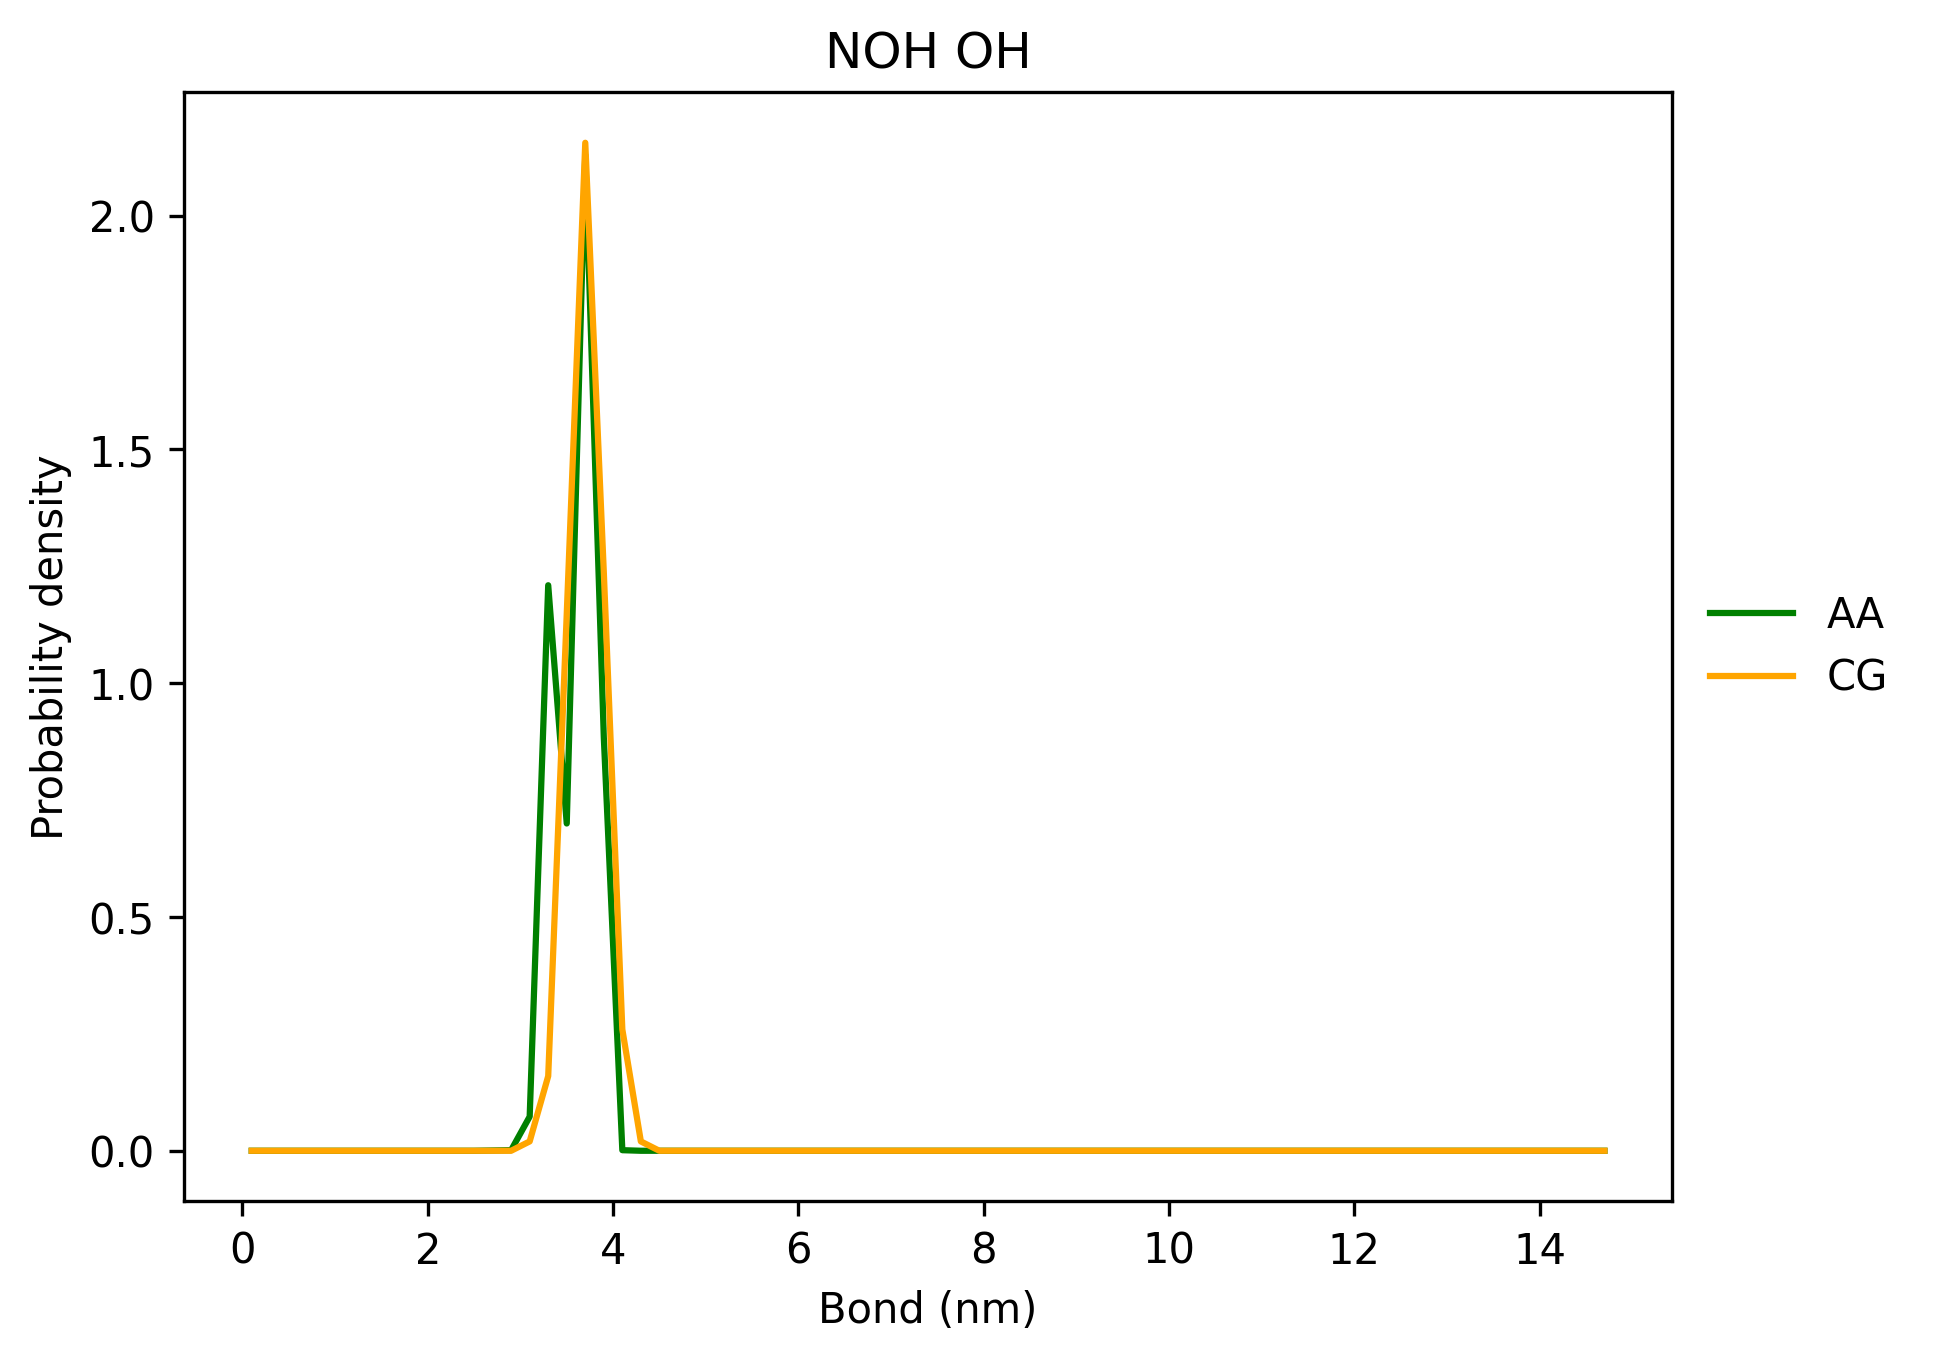

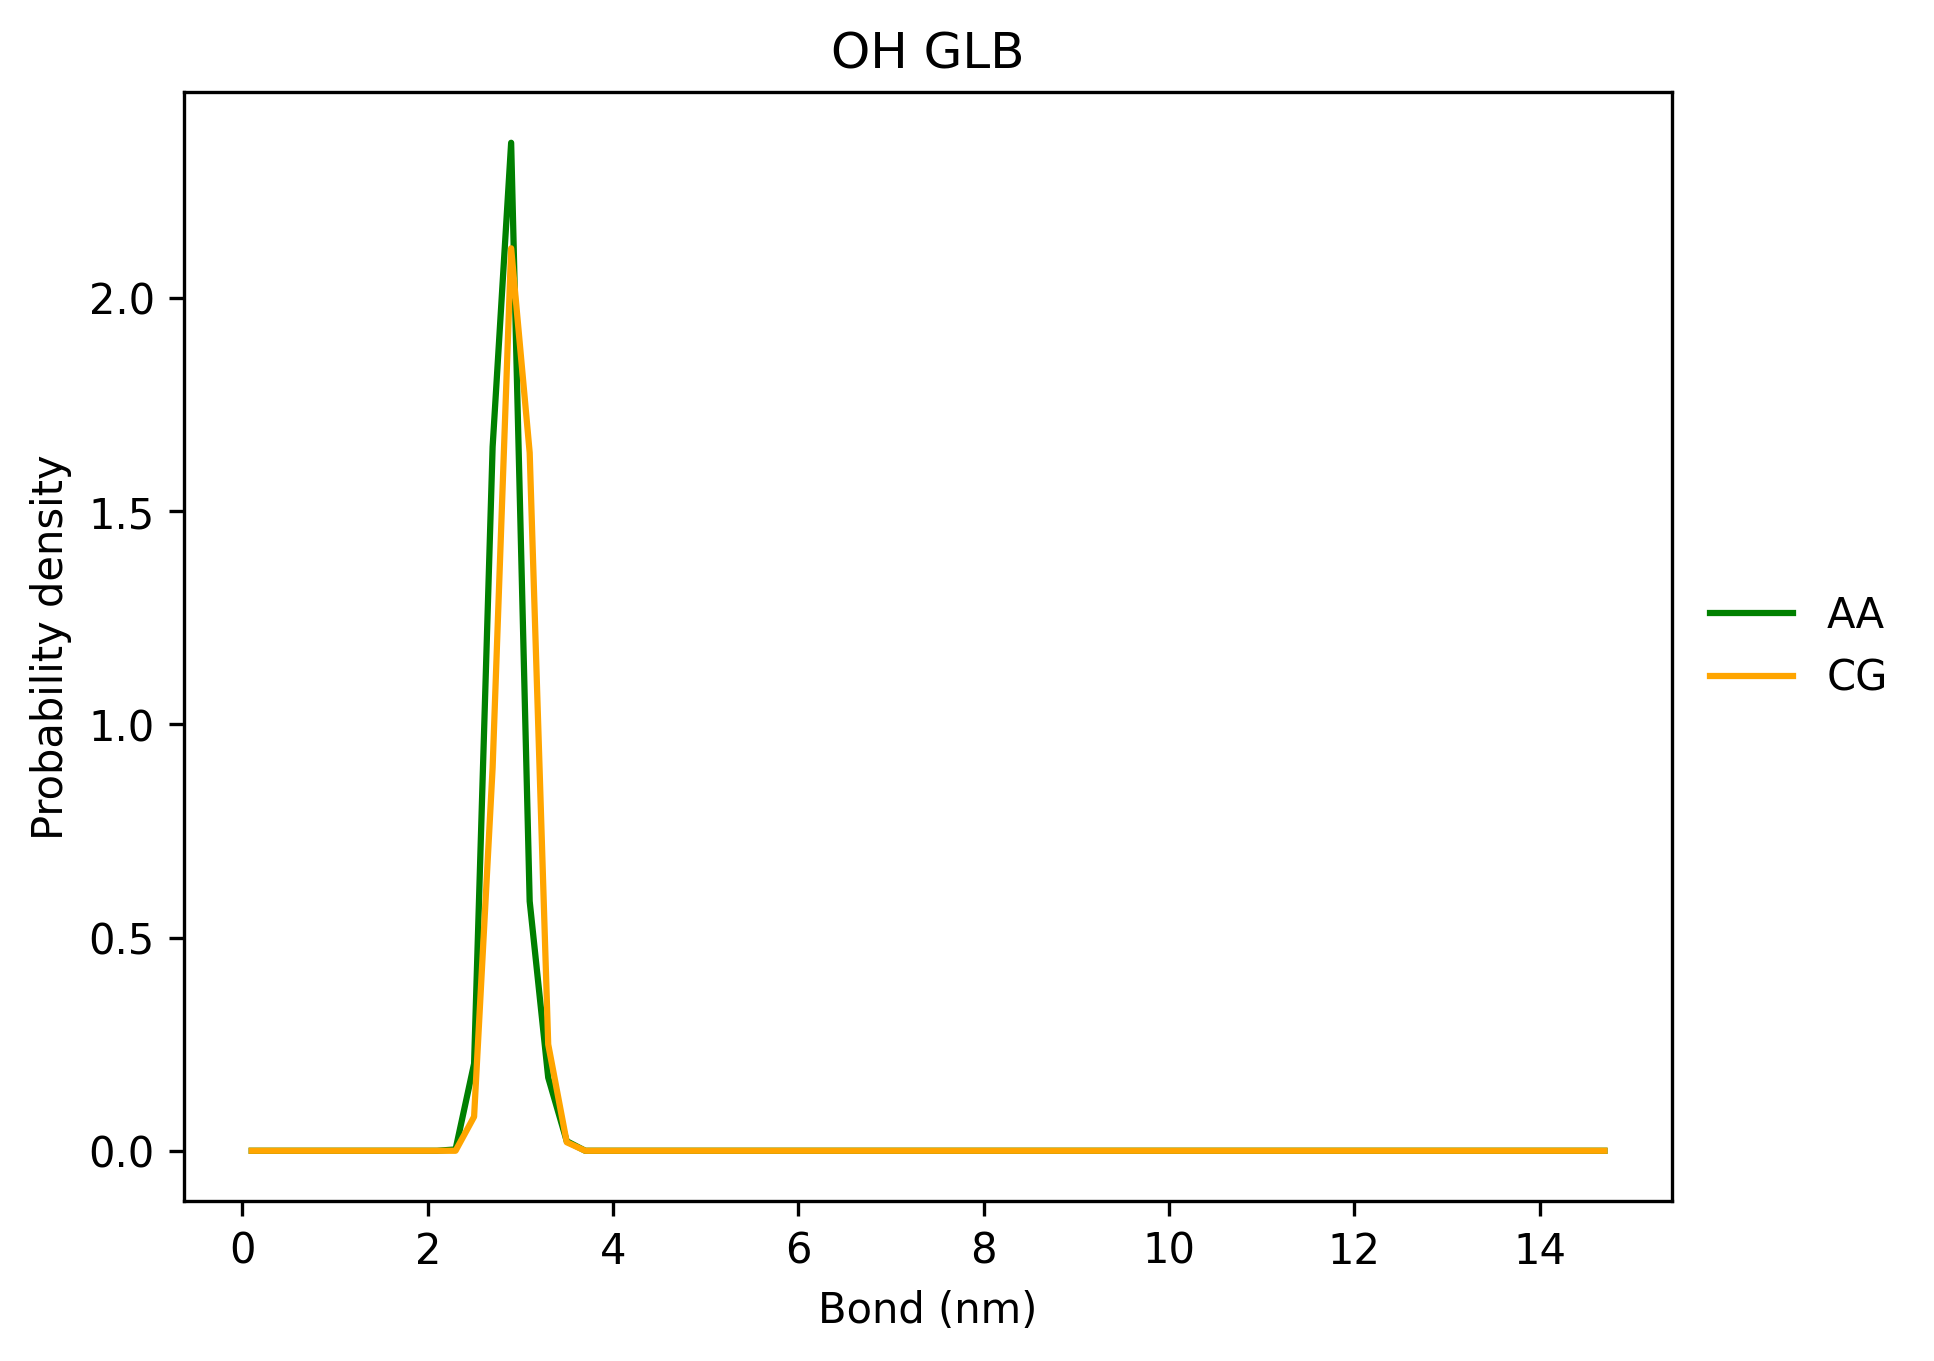

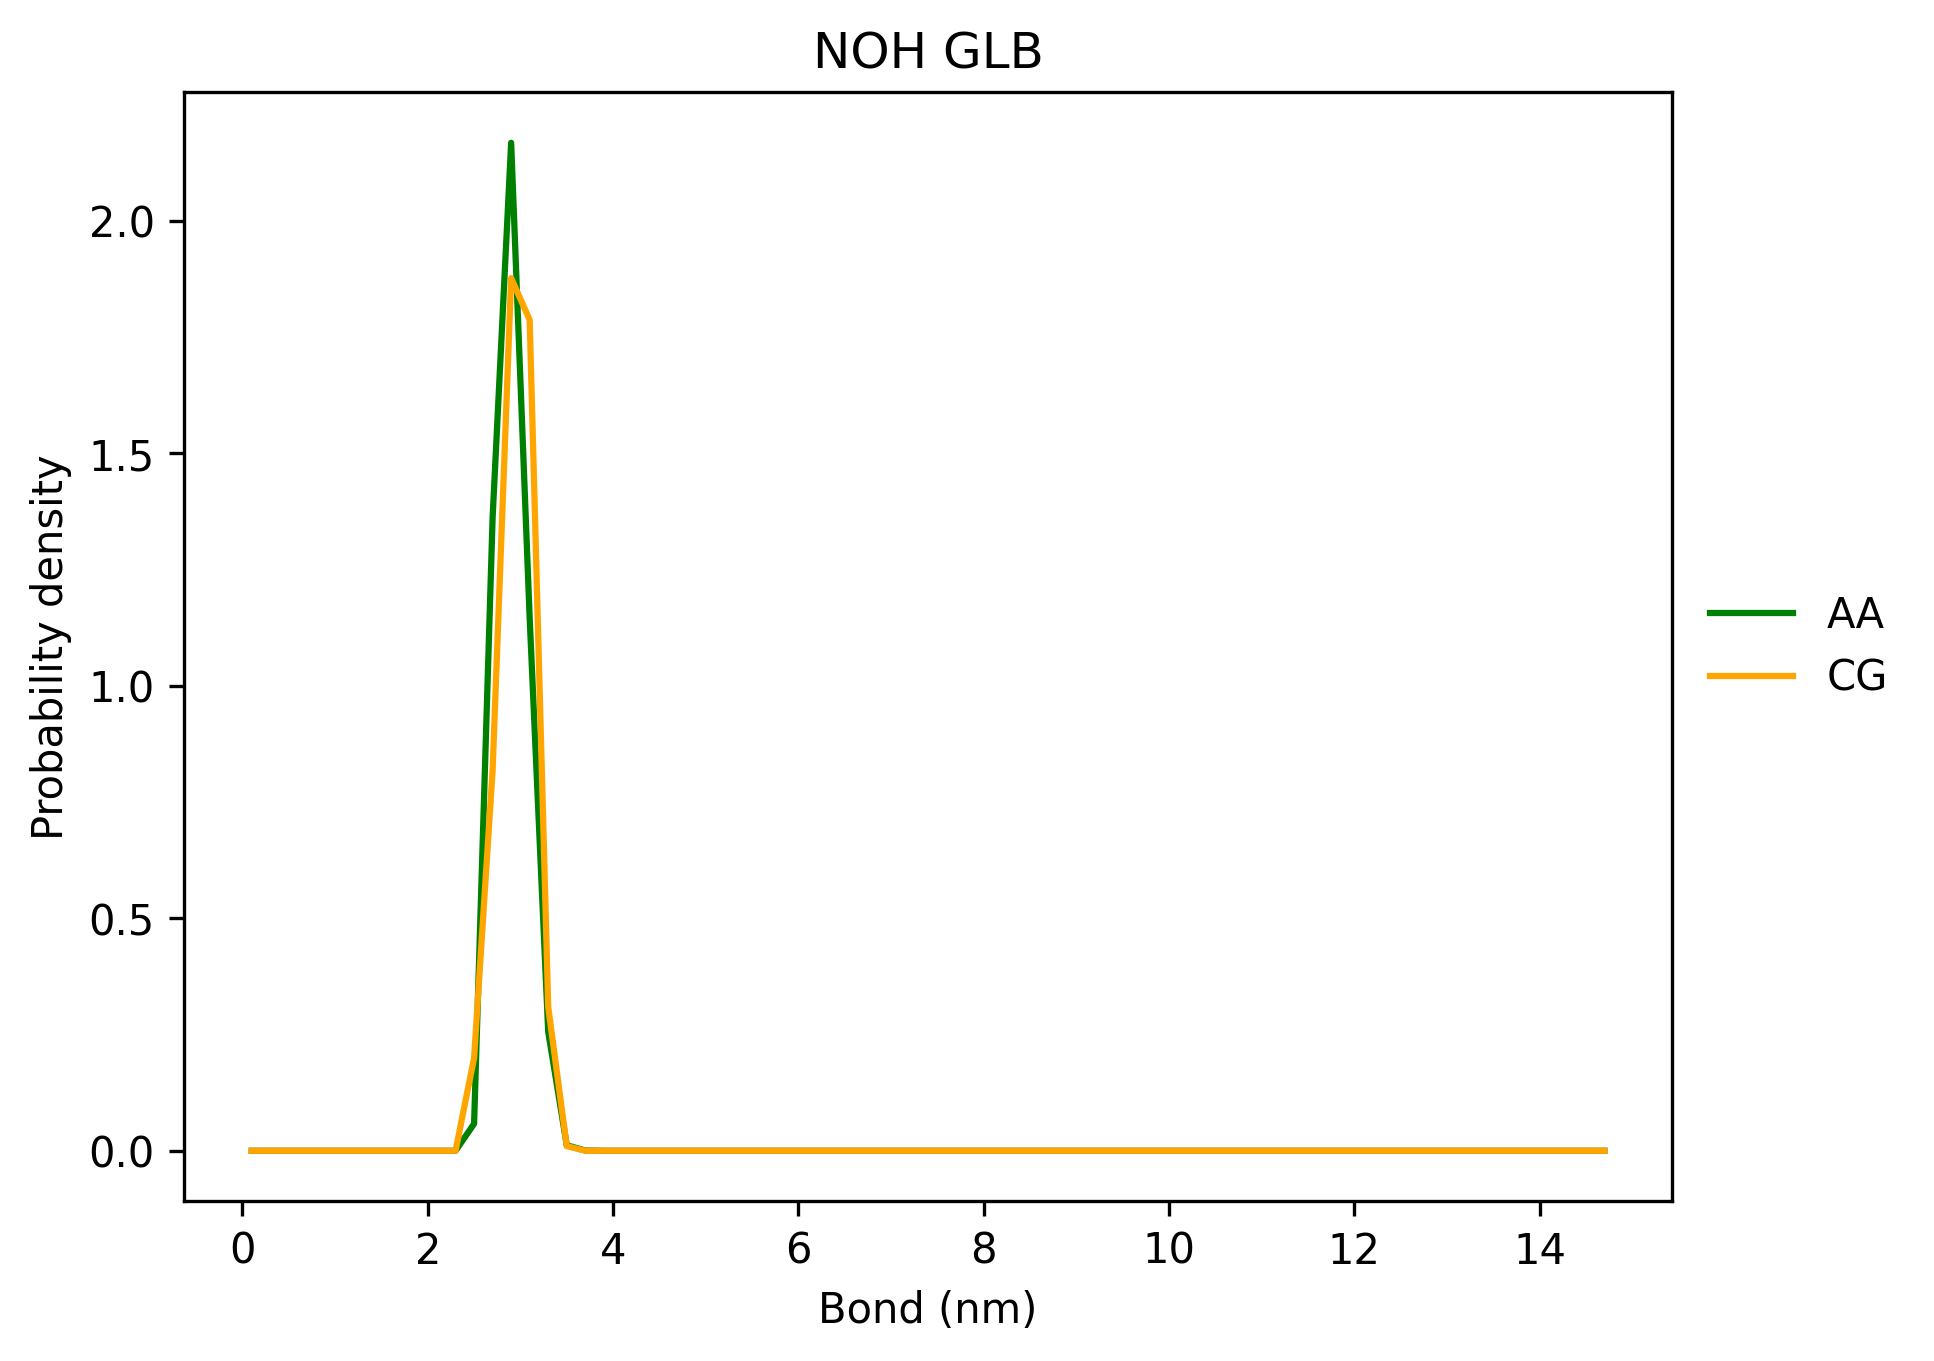

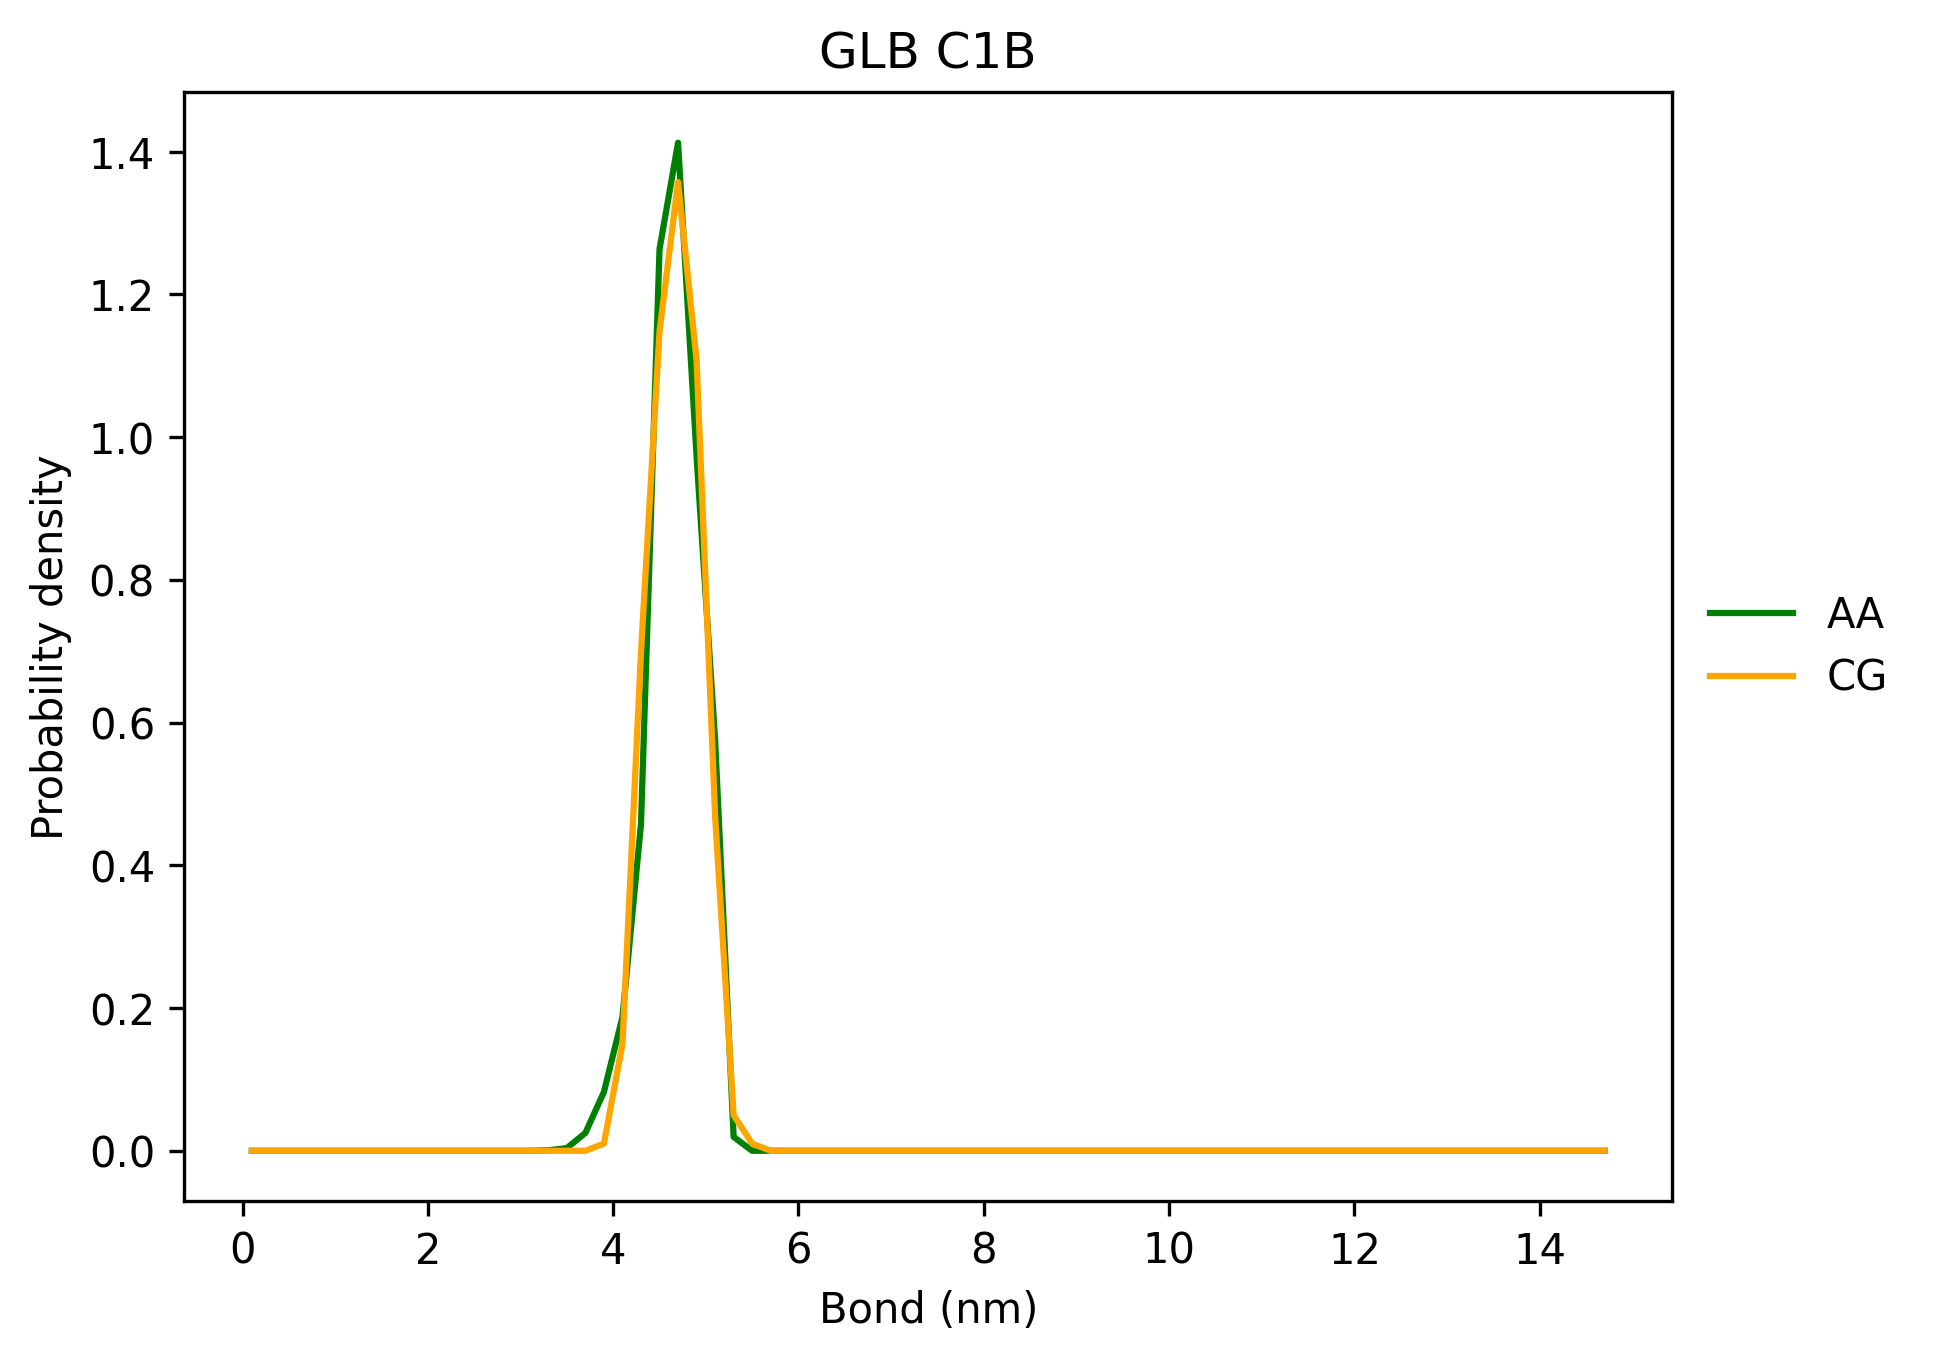

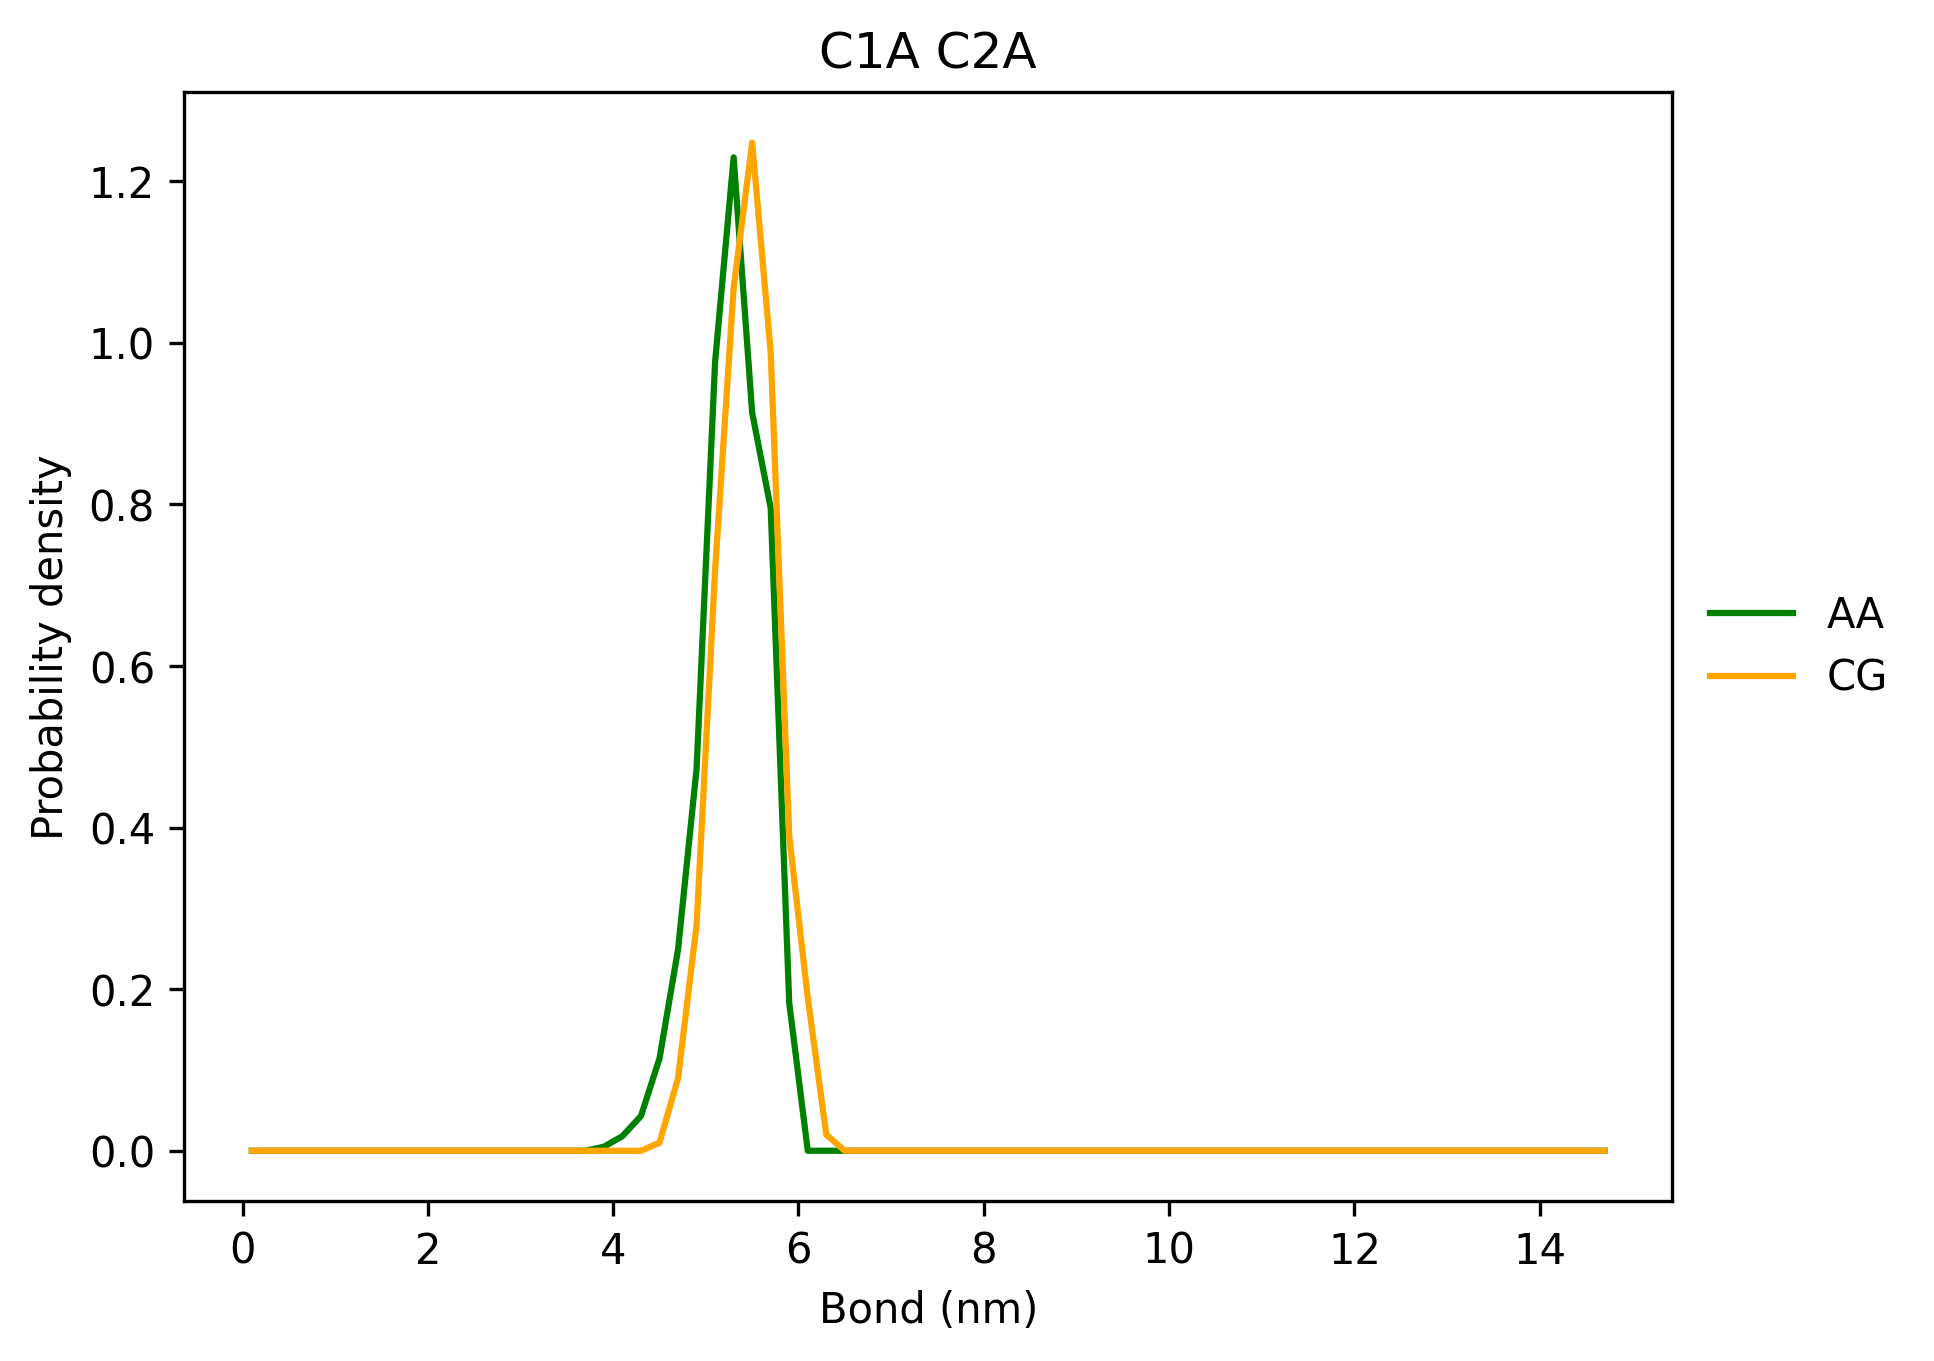

In [29]:
for bond in List_bonds:
    HAA,BAA = np.histogram(np.array(dist_aa)[bond,:], bins=bins_dist, density=True)
    HCG,BCG = np.histogram(np.array(dist_cg)[bond,:], bins=bins_dist, density=True)

    plt.plot(bins_dist_x, HAA, label='AA', color='green')
    plt.plot(bins_dist_x, HCG, label='CG', color='orange')

    title = ' '.join(i for i in dist_tgts[bond[0]])
    plt.title(title) 
    plt.xlabel('Bond (nm)')
    plt.ylabel('Probability density')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.savefig('{}_water_bond.png'.format(title), dpi=300, bbox_inches='tight')
    plt.show()

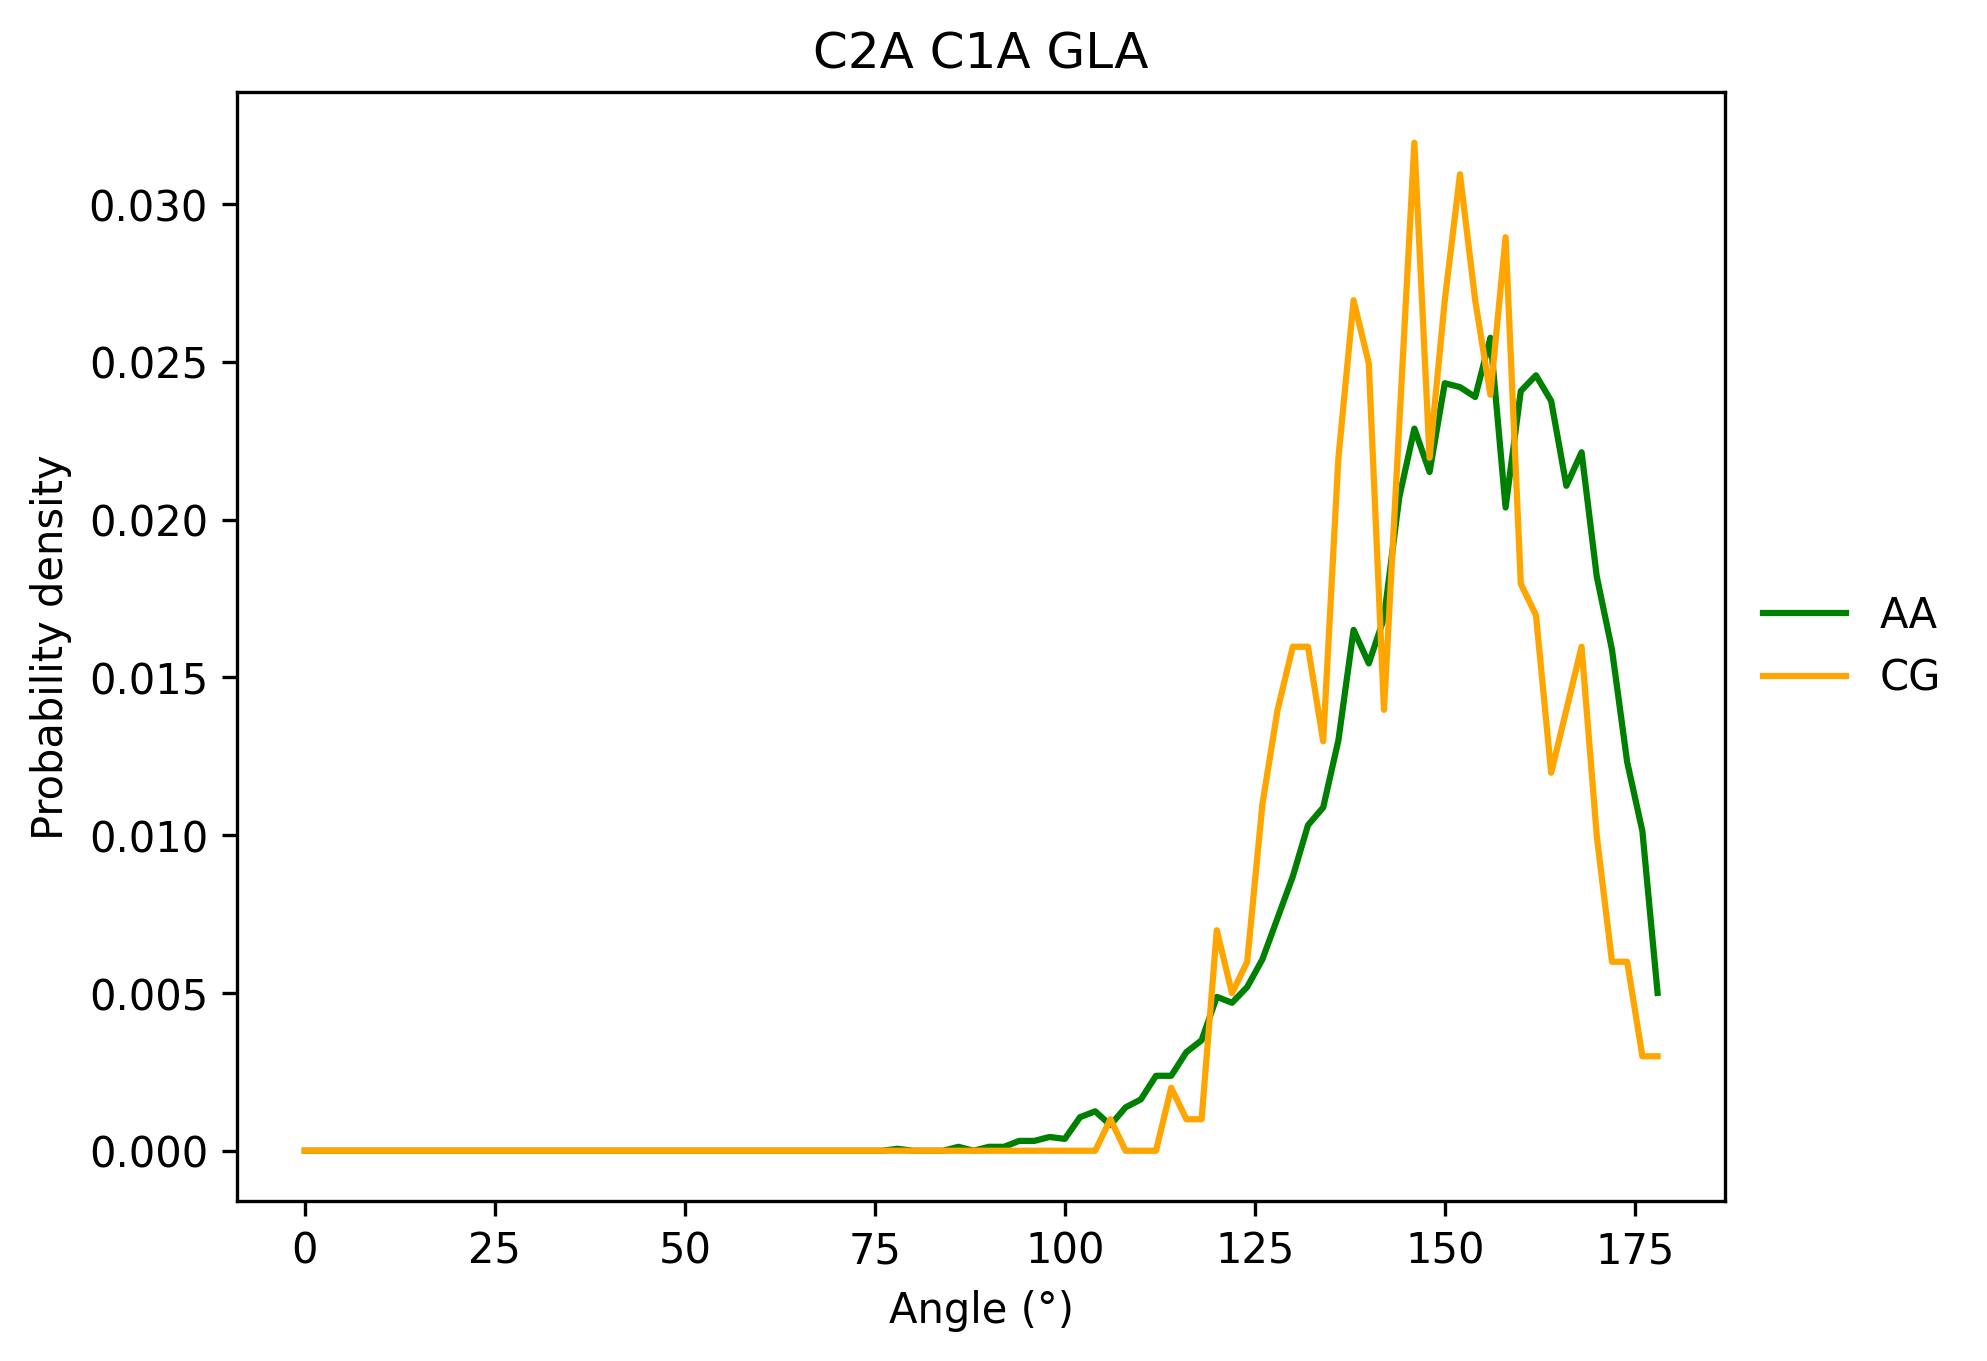

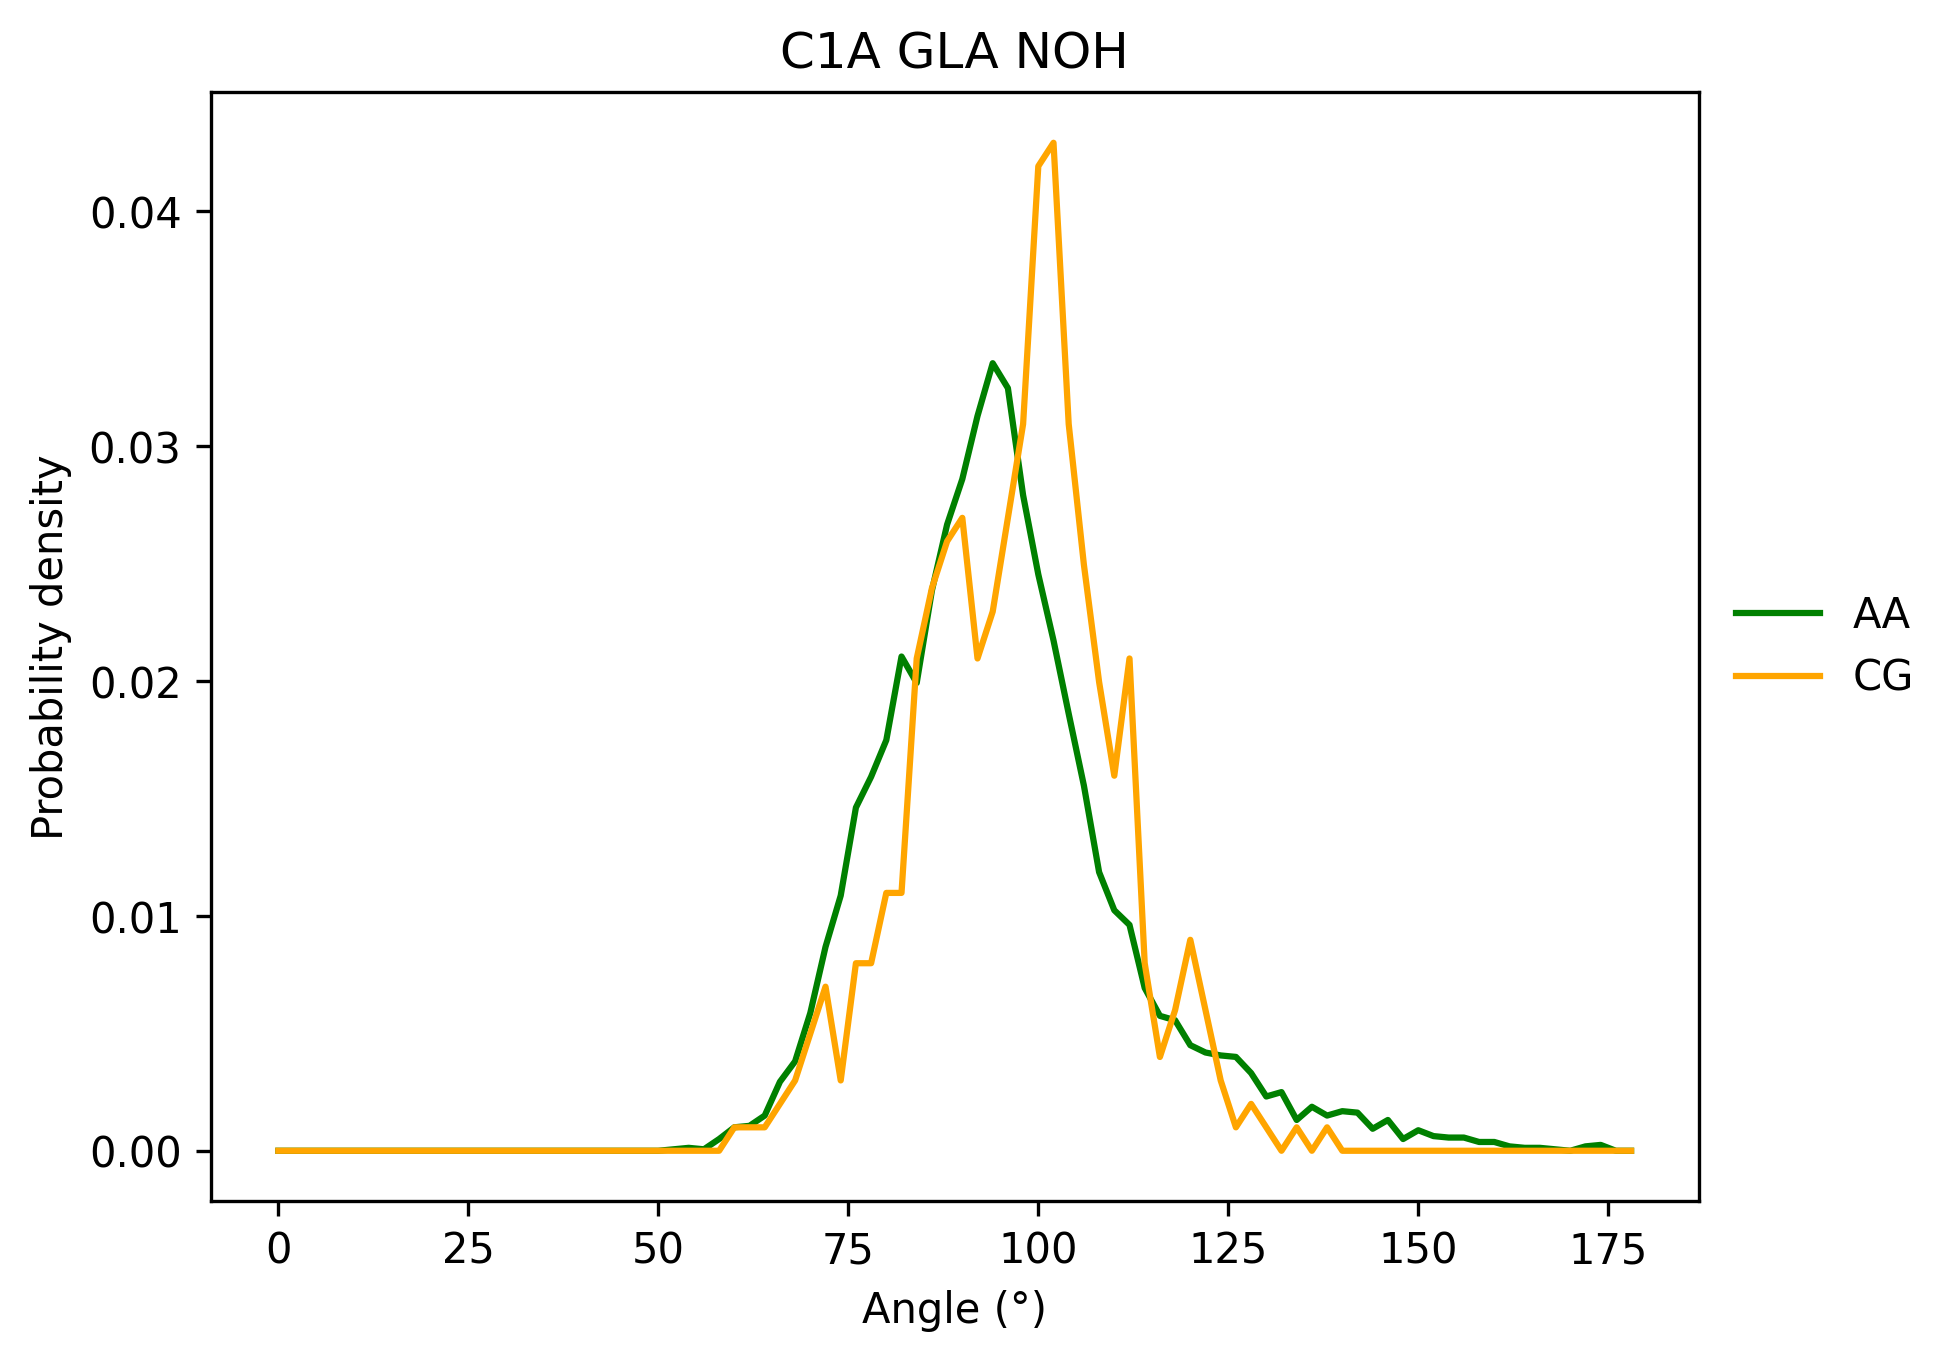

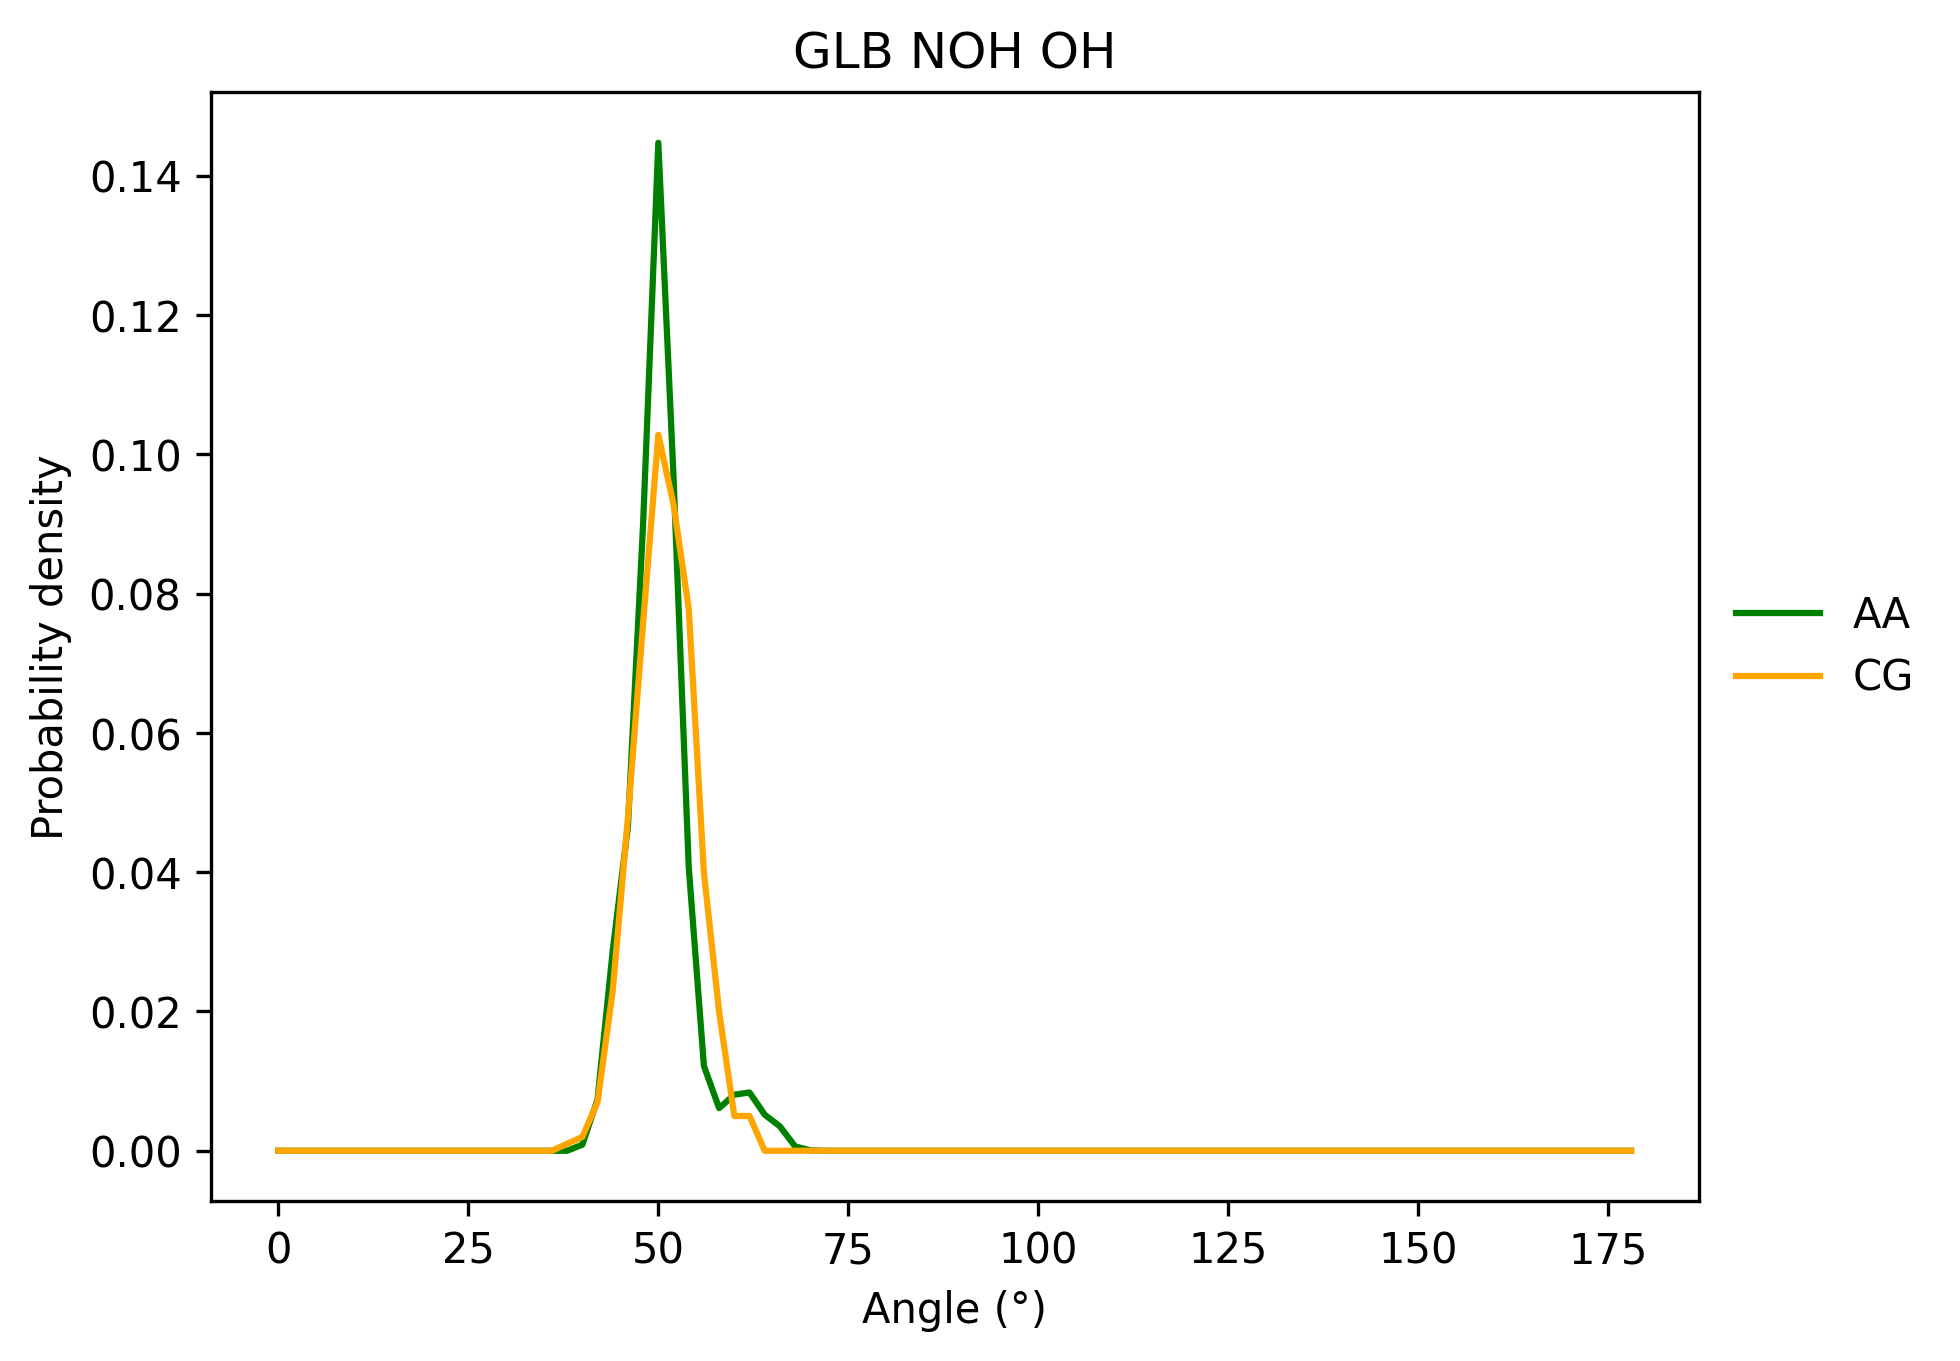

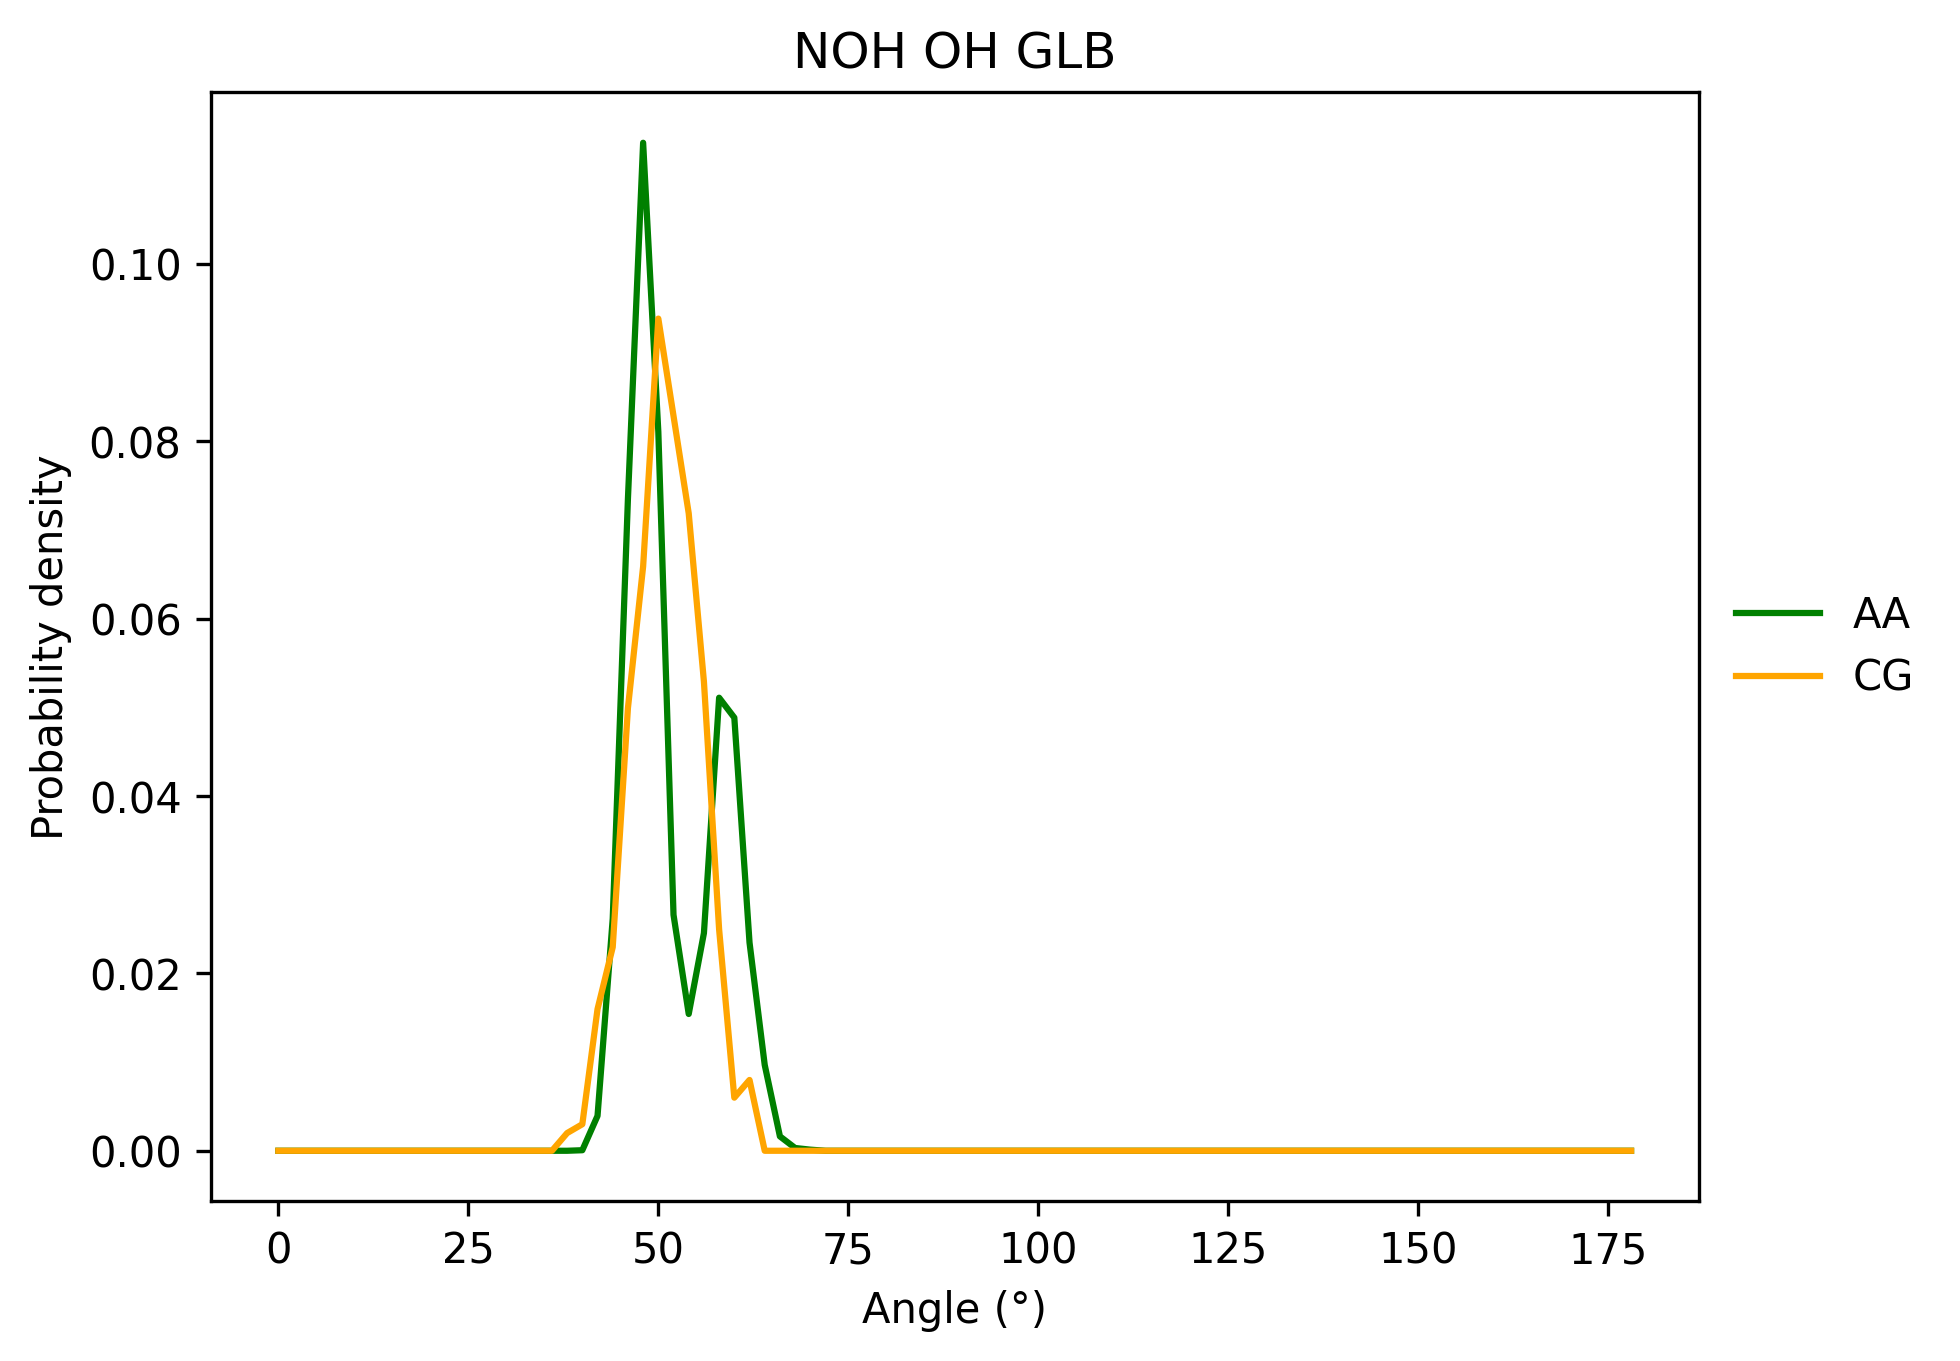

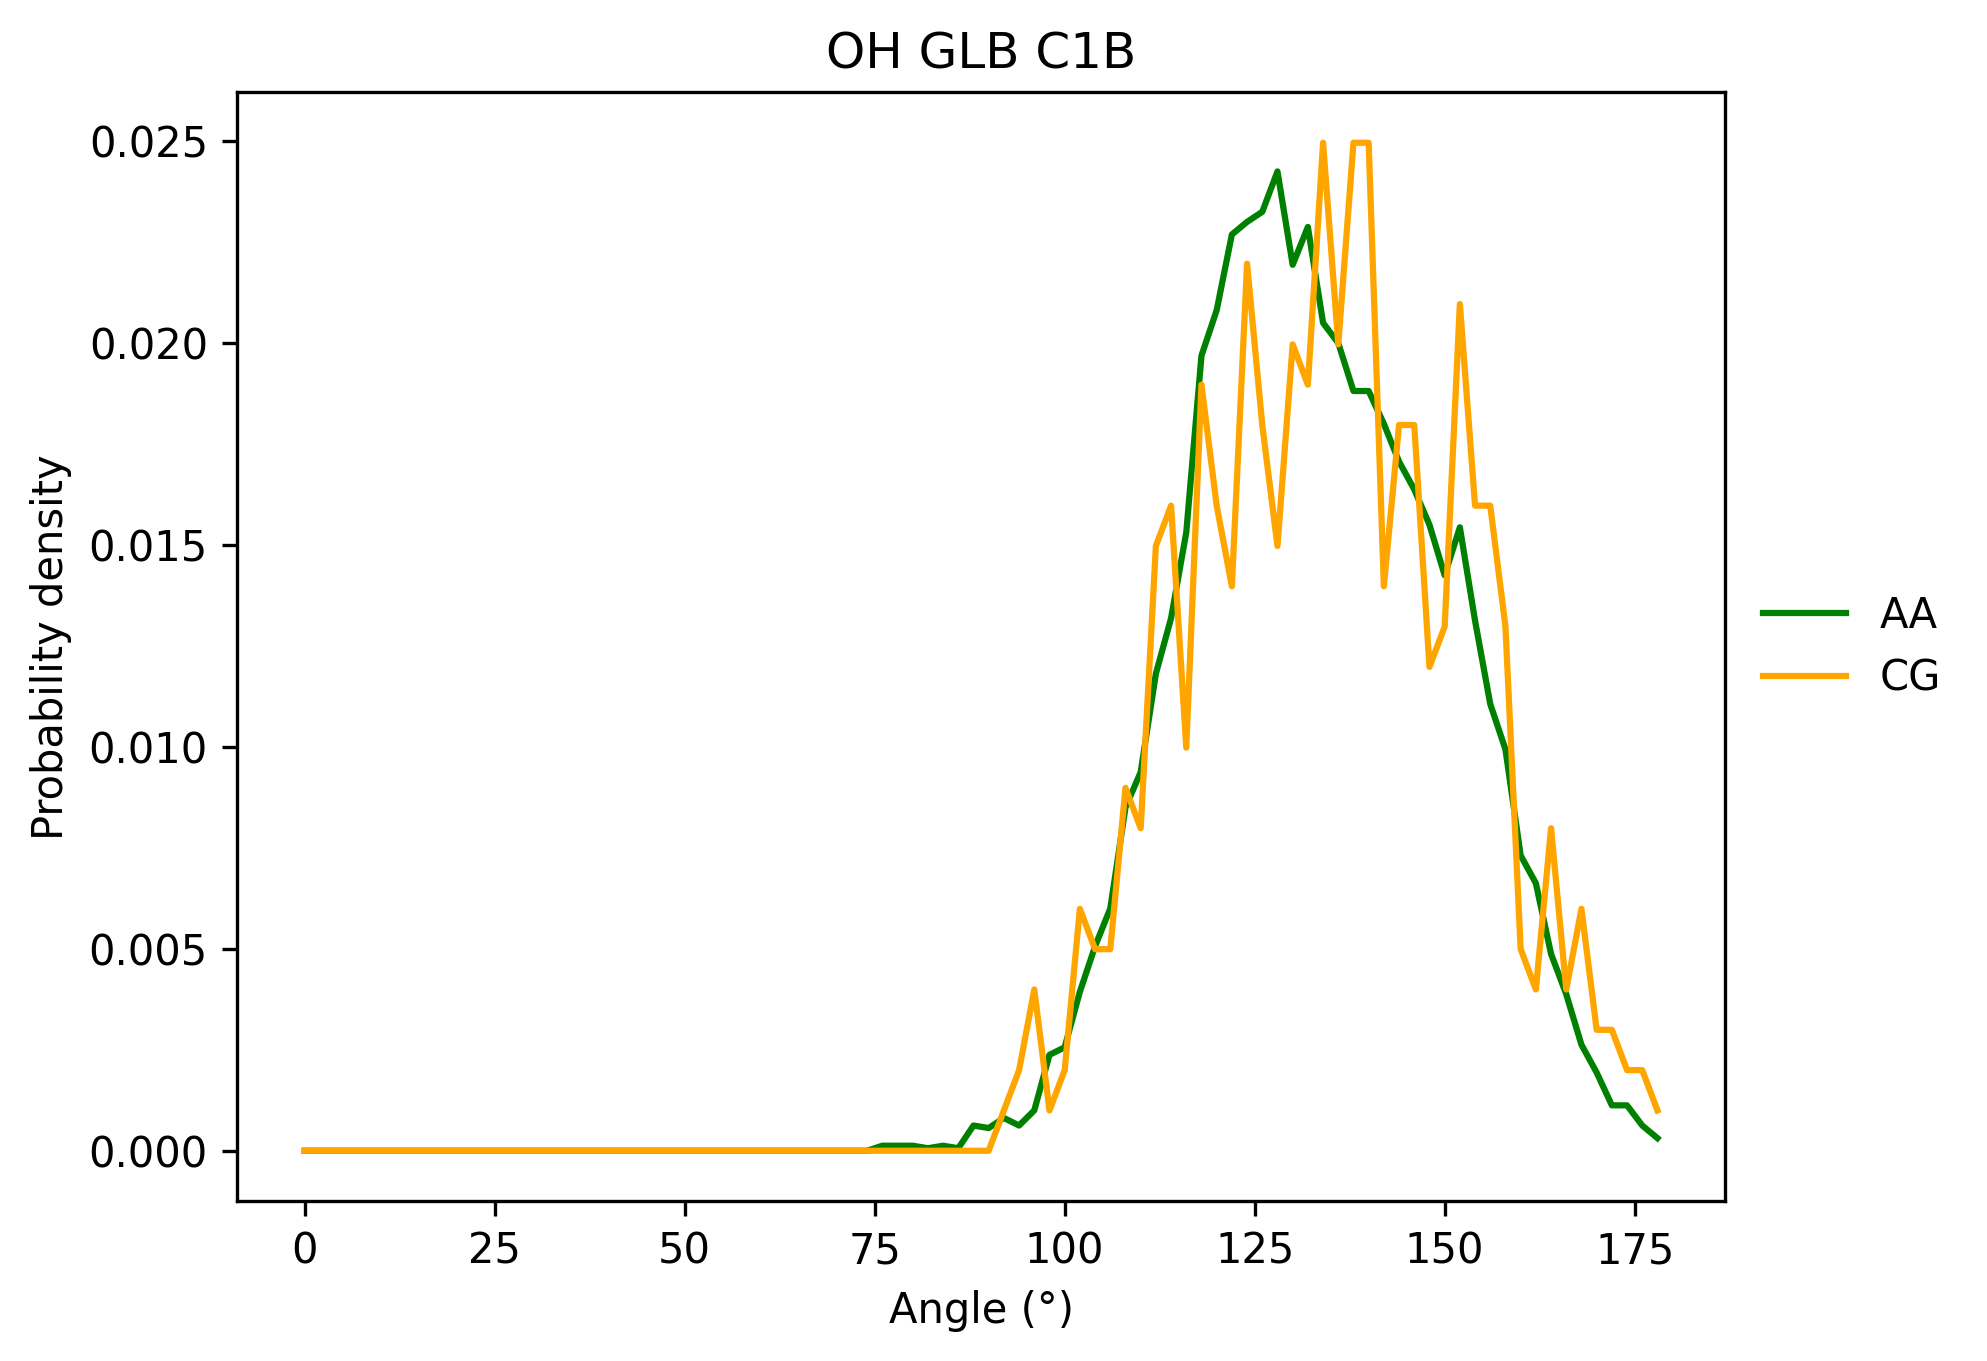

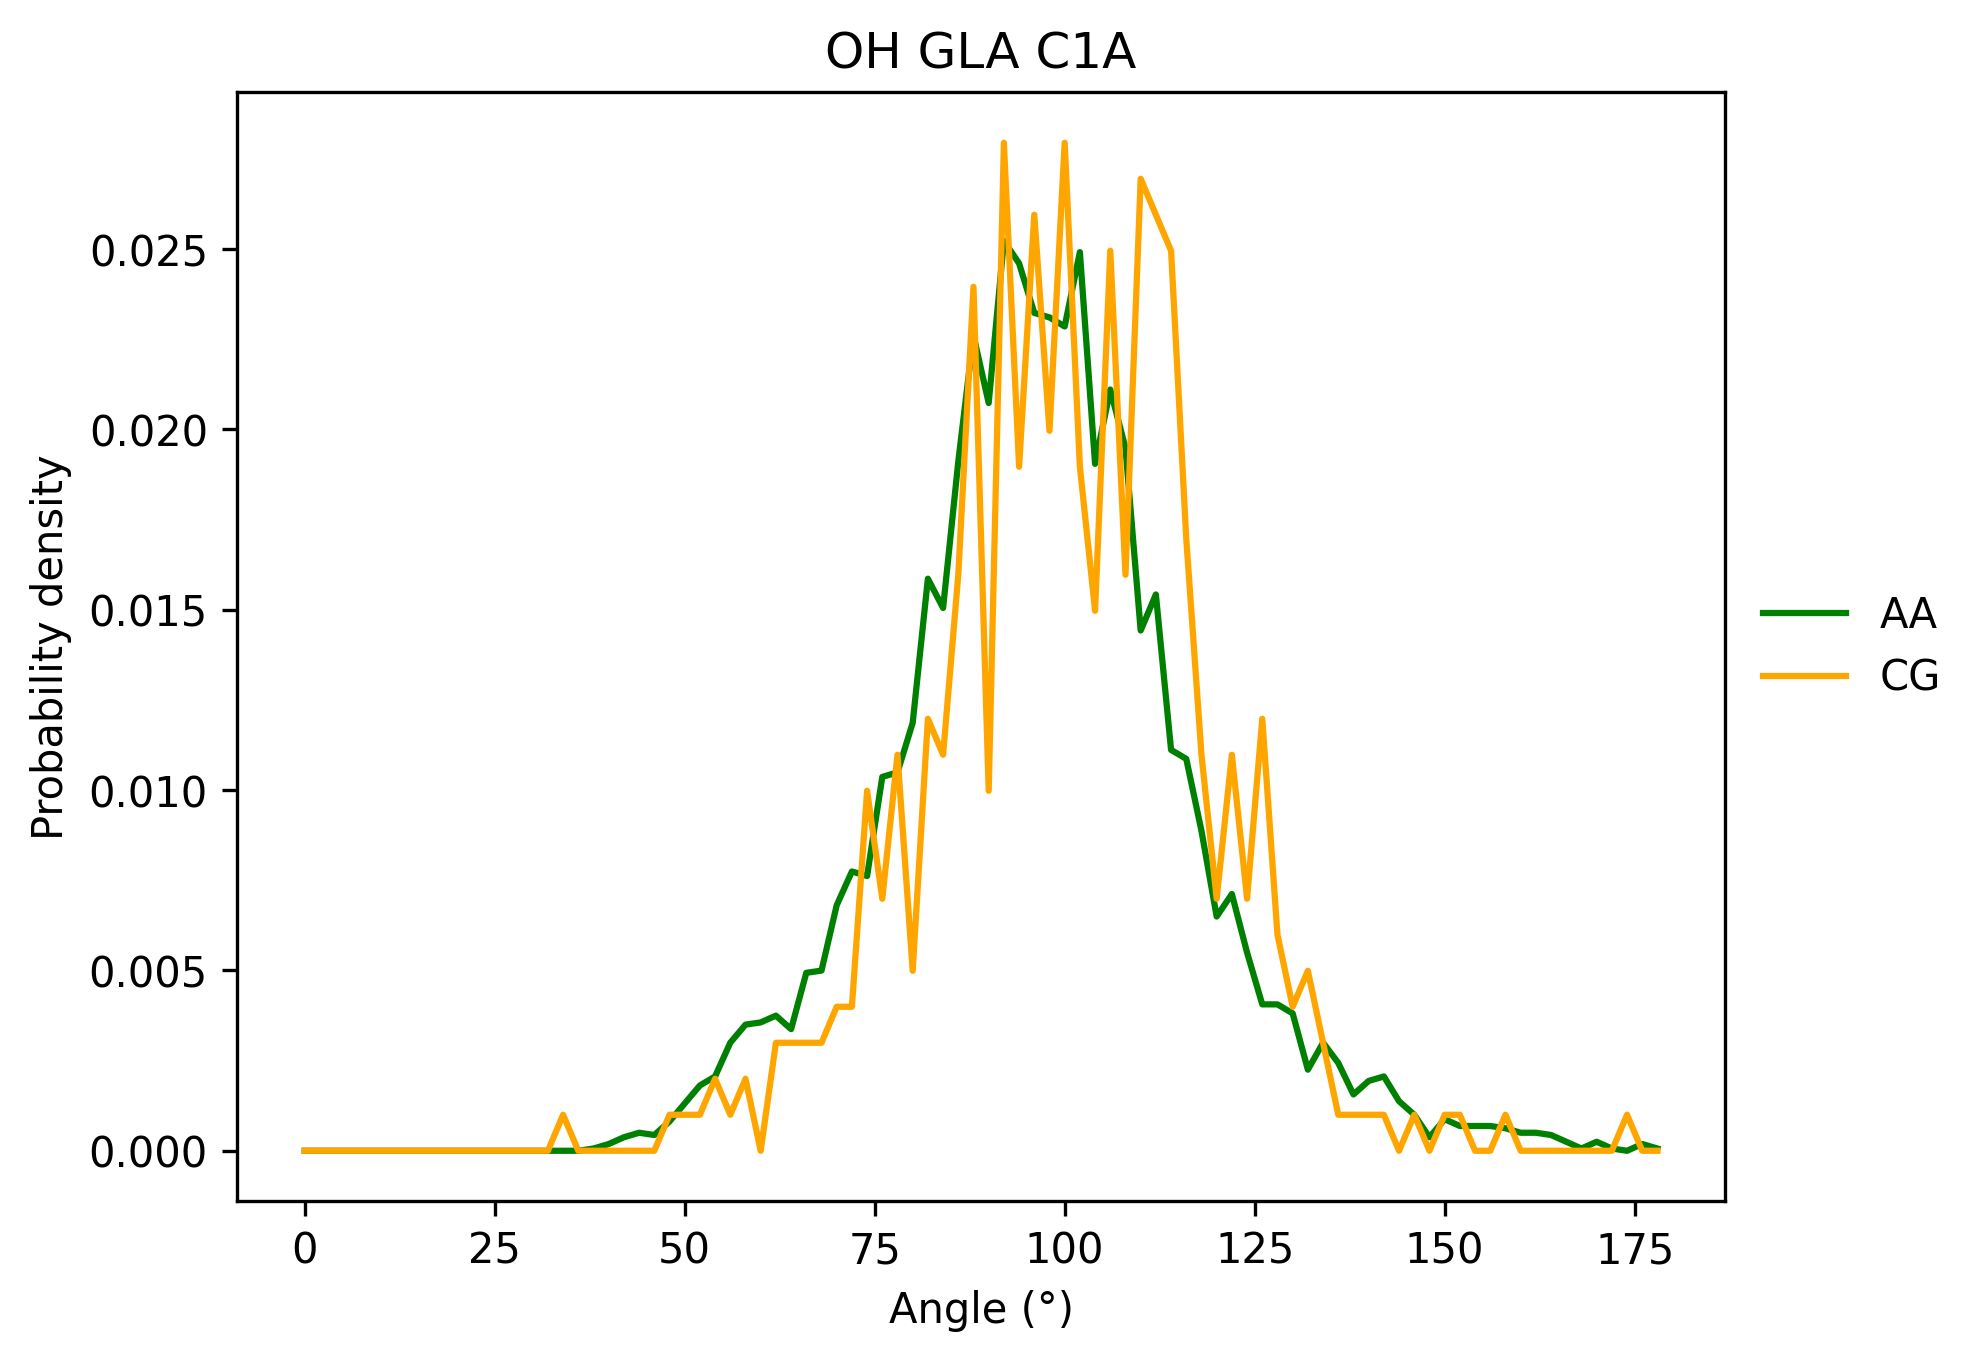

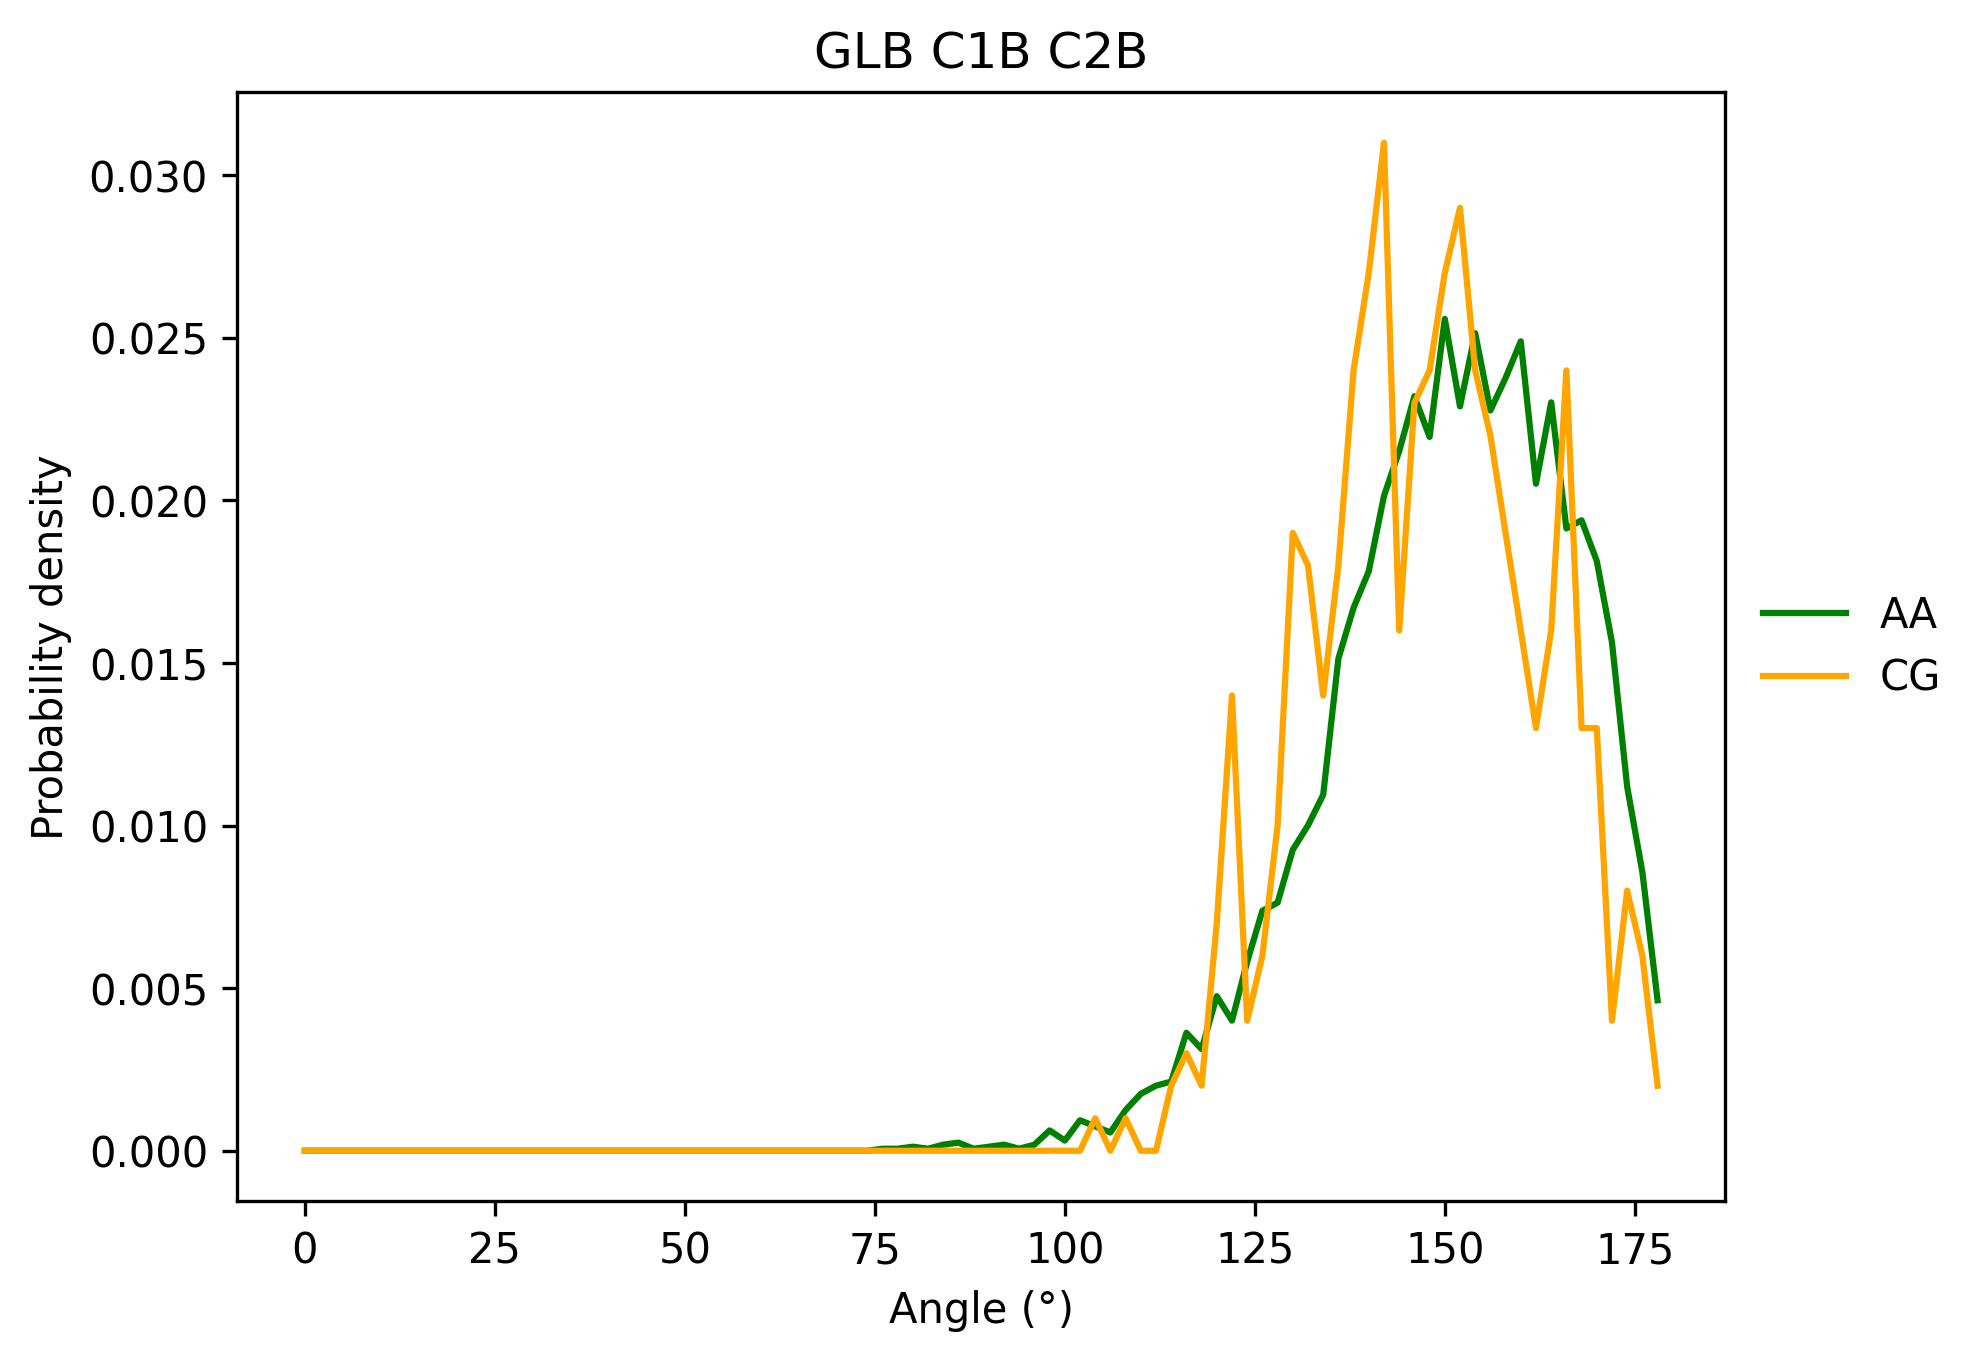

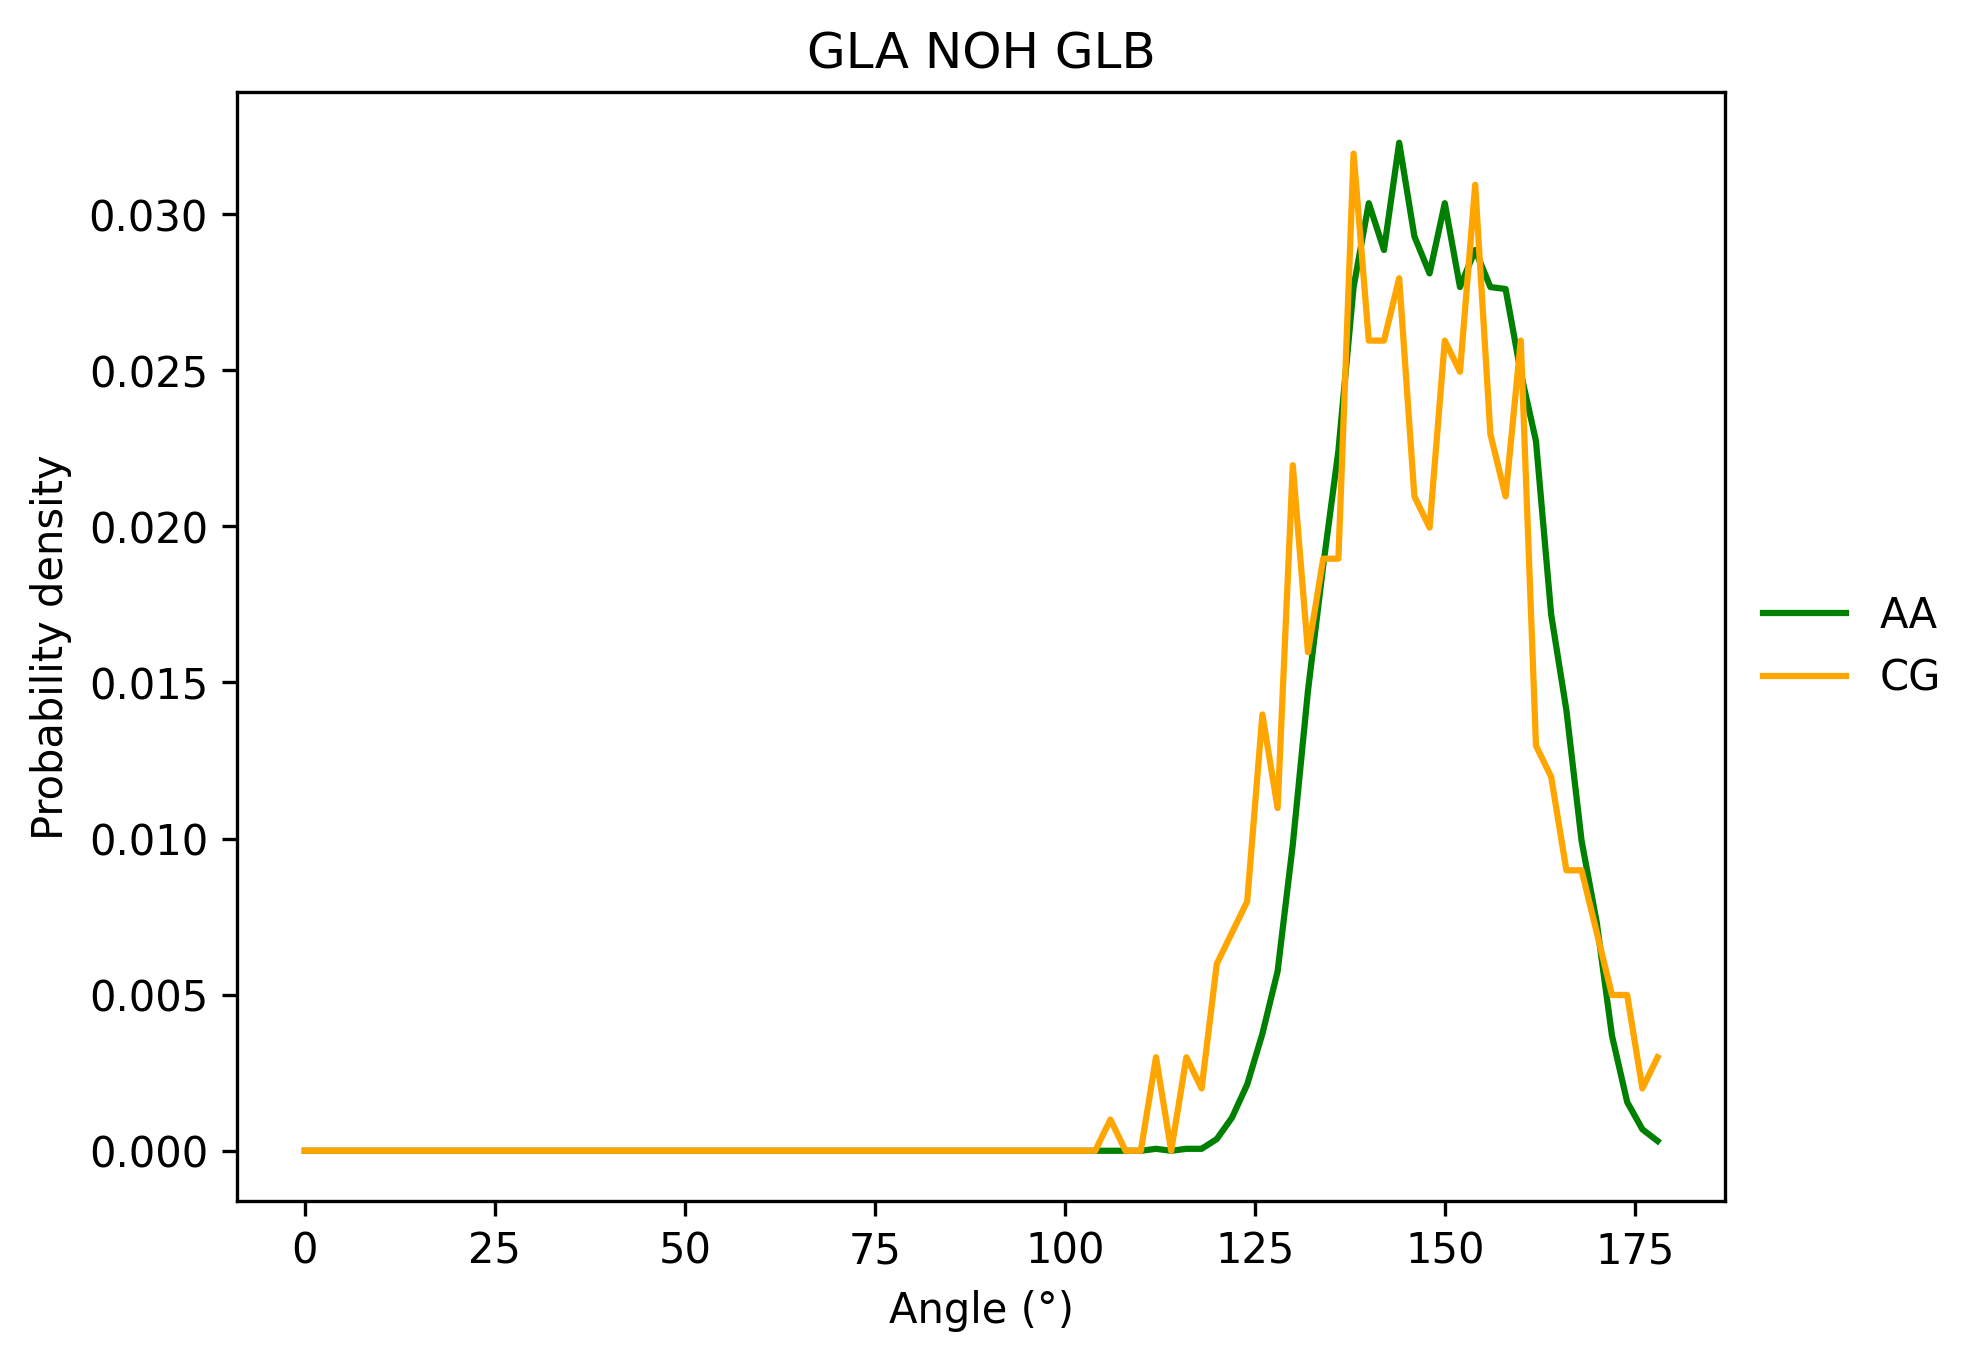

In [30]:
for angle in List_angles:
    HAA,BAA = np.histogram(np.array(ang_aa)[angle,:], bins=bins_angl, density=True)
    HCG,BCG = np.histogram(np.array(ang_cg)[angle,:], bins=bins_angl, density=True)

    plt.plot(bins_angl_x, HAA, label='AA', color='green')
    plt.plot(bins_angl_x, HCG, label='CG', color='orange')
    title = ' '.join(i for i in ang_tgts[angle[0]])
    plt.title(title) 
    plt.xlabel('Angle (°)')
    plt.ylabel('Probability density')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.savefig('{}_water_angle.png'.format(title), dpi=300, bbox_inches='tight')
    plt.show()

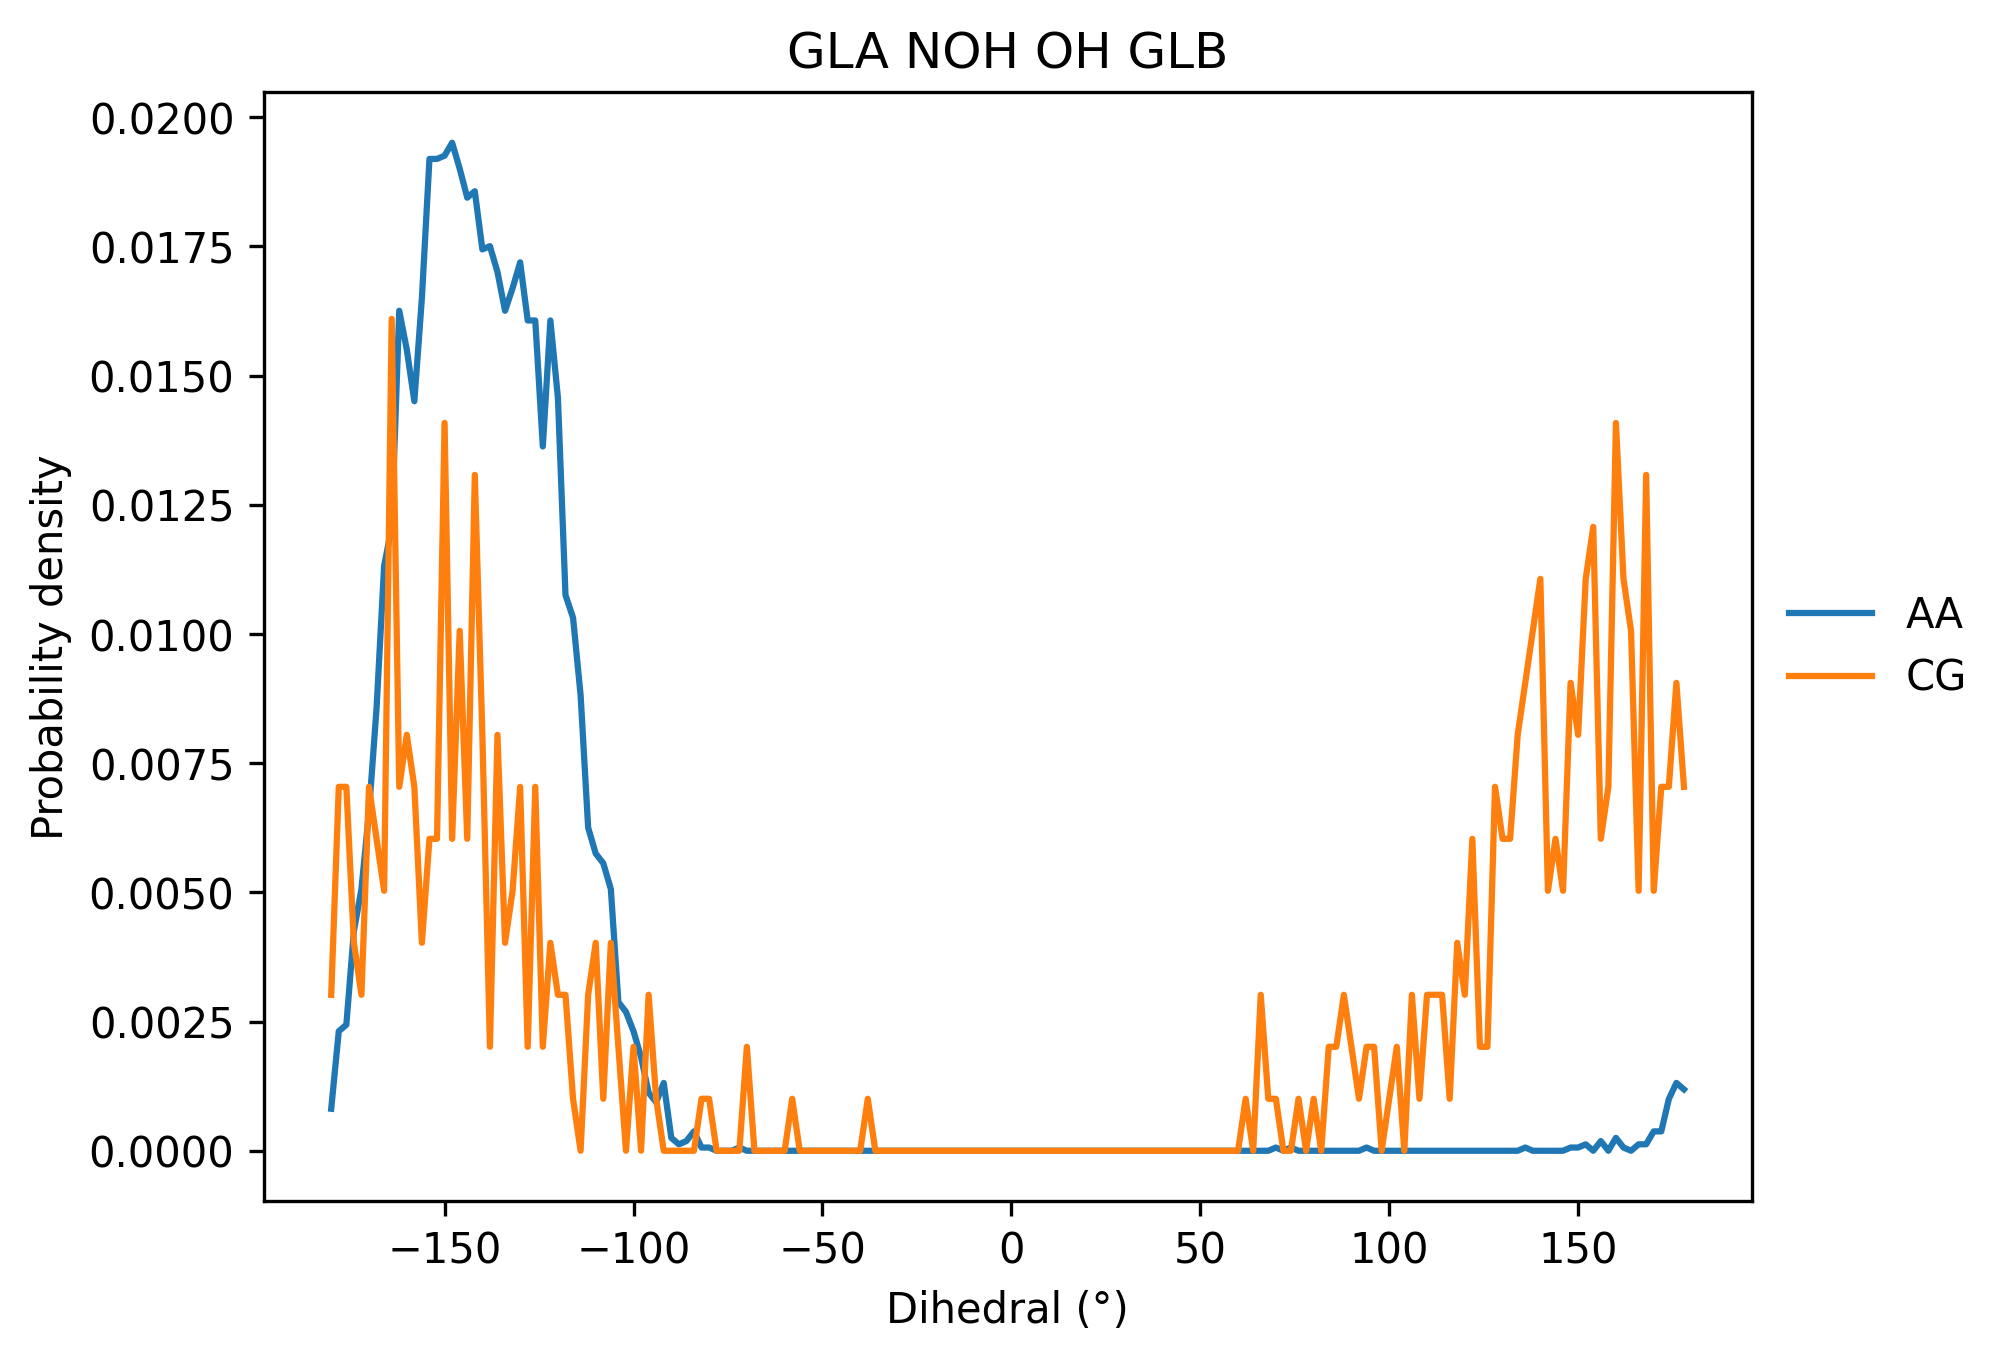

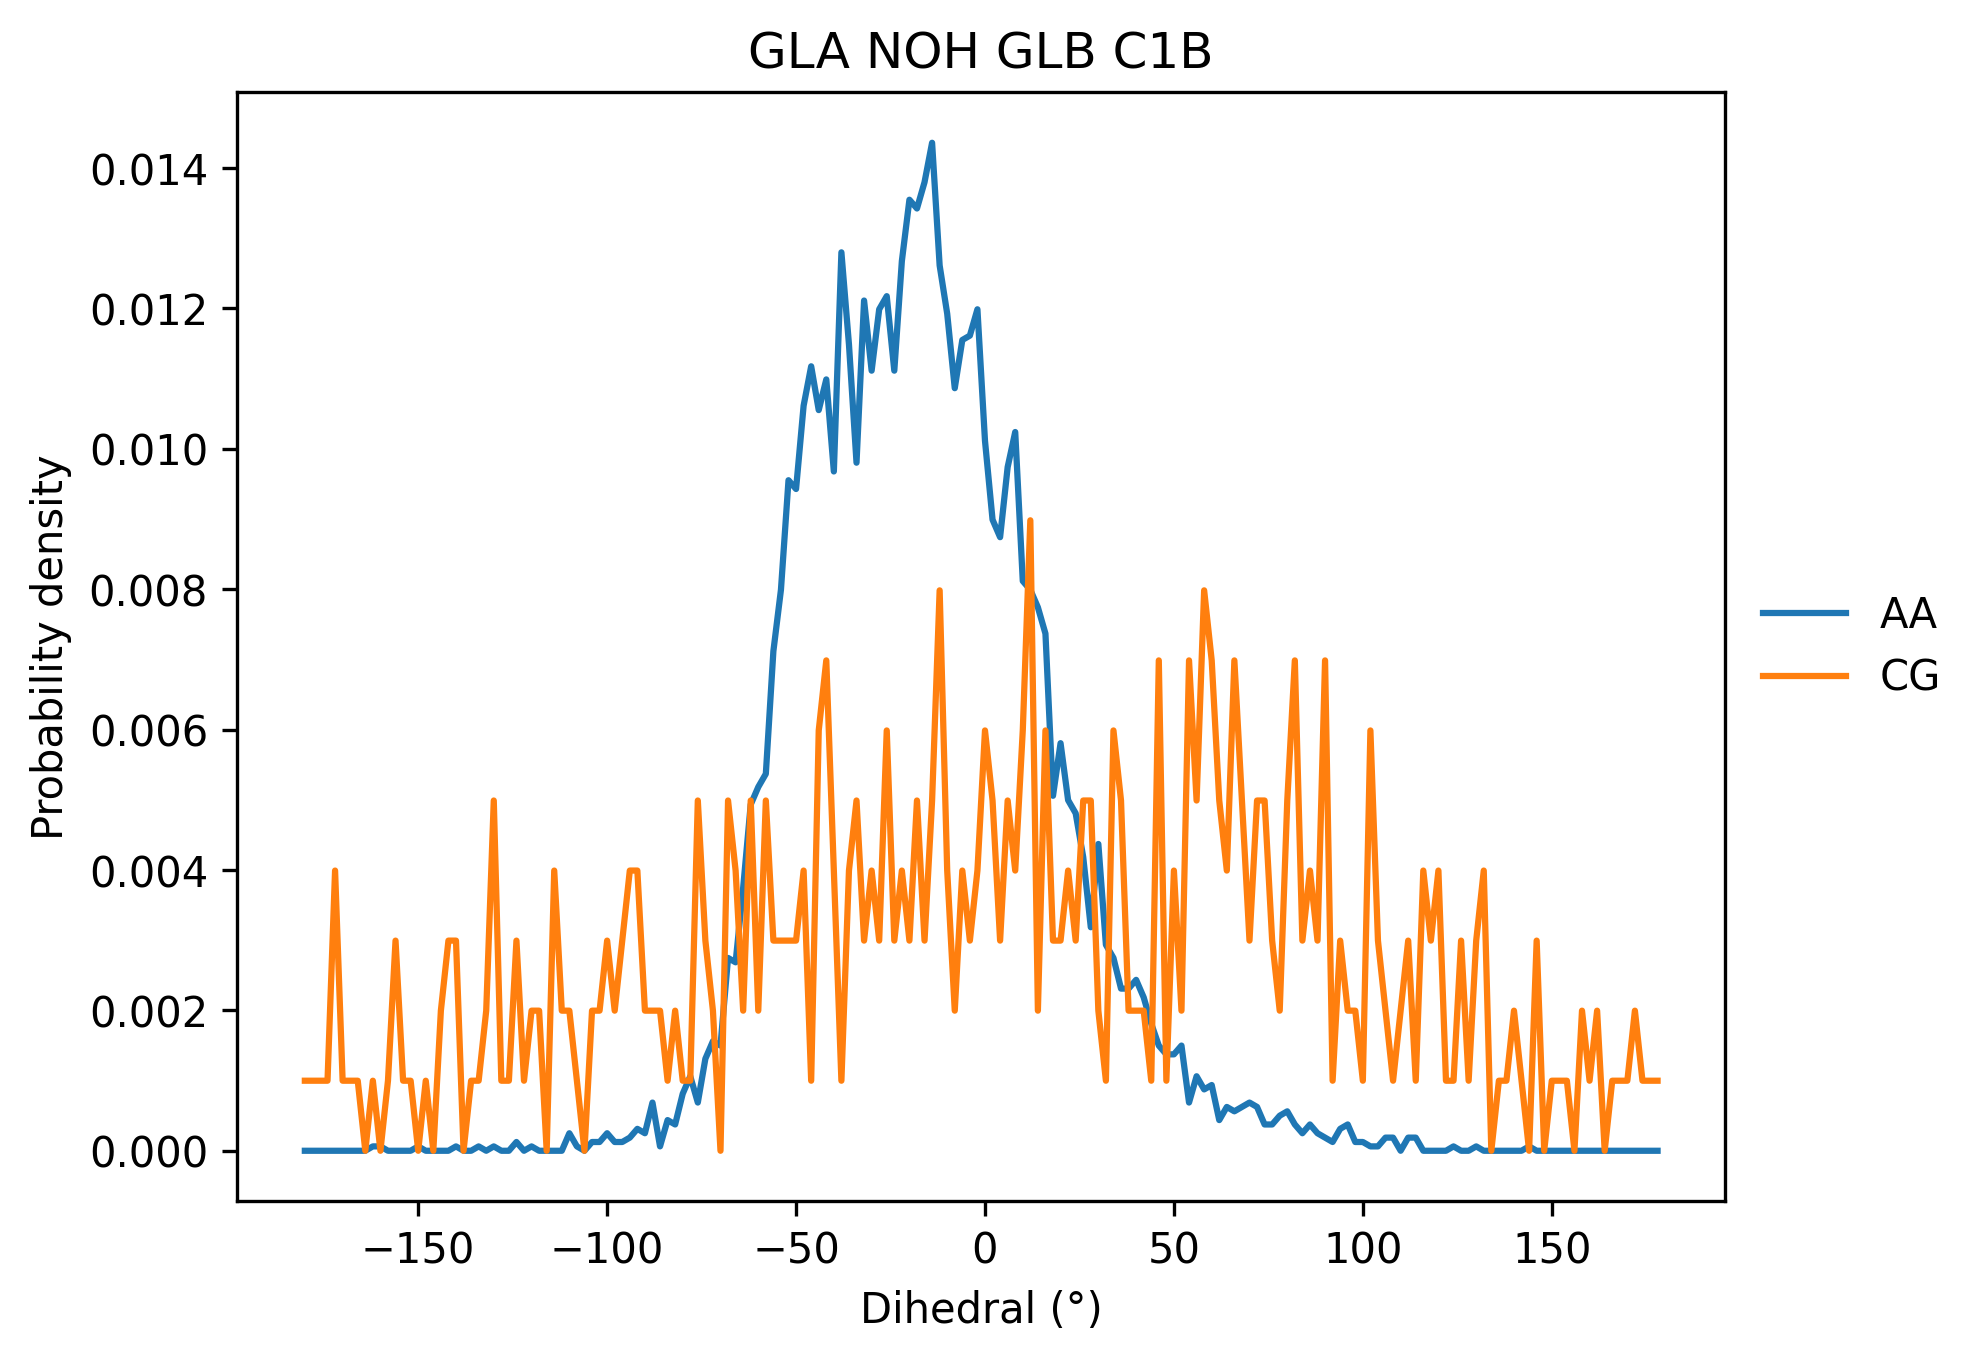

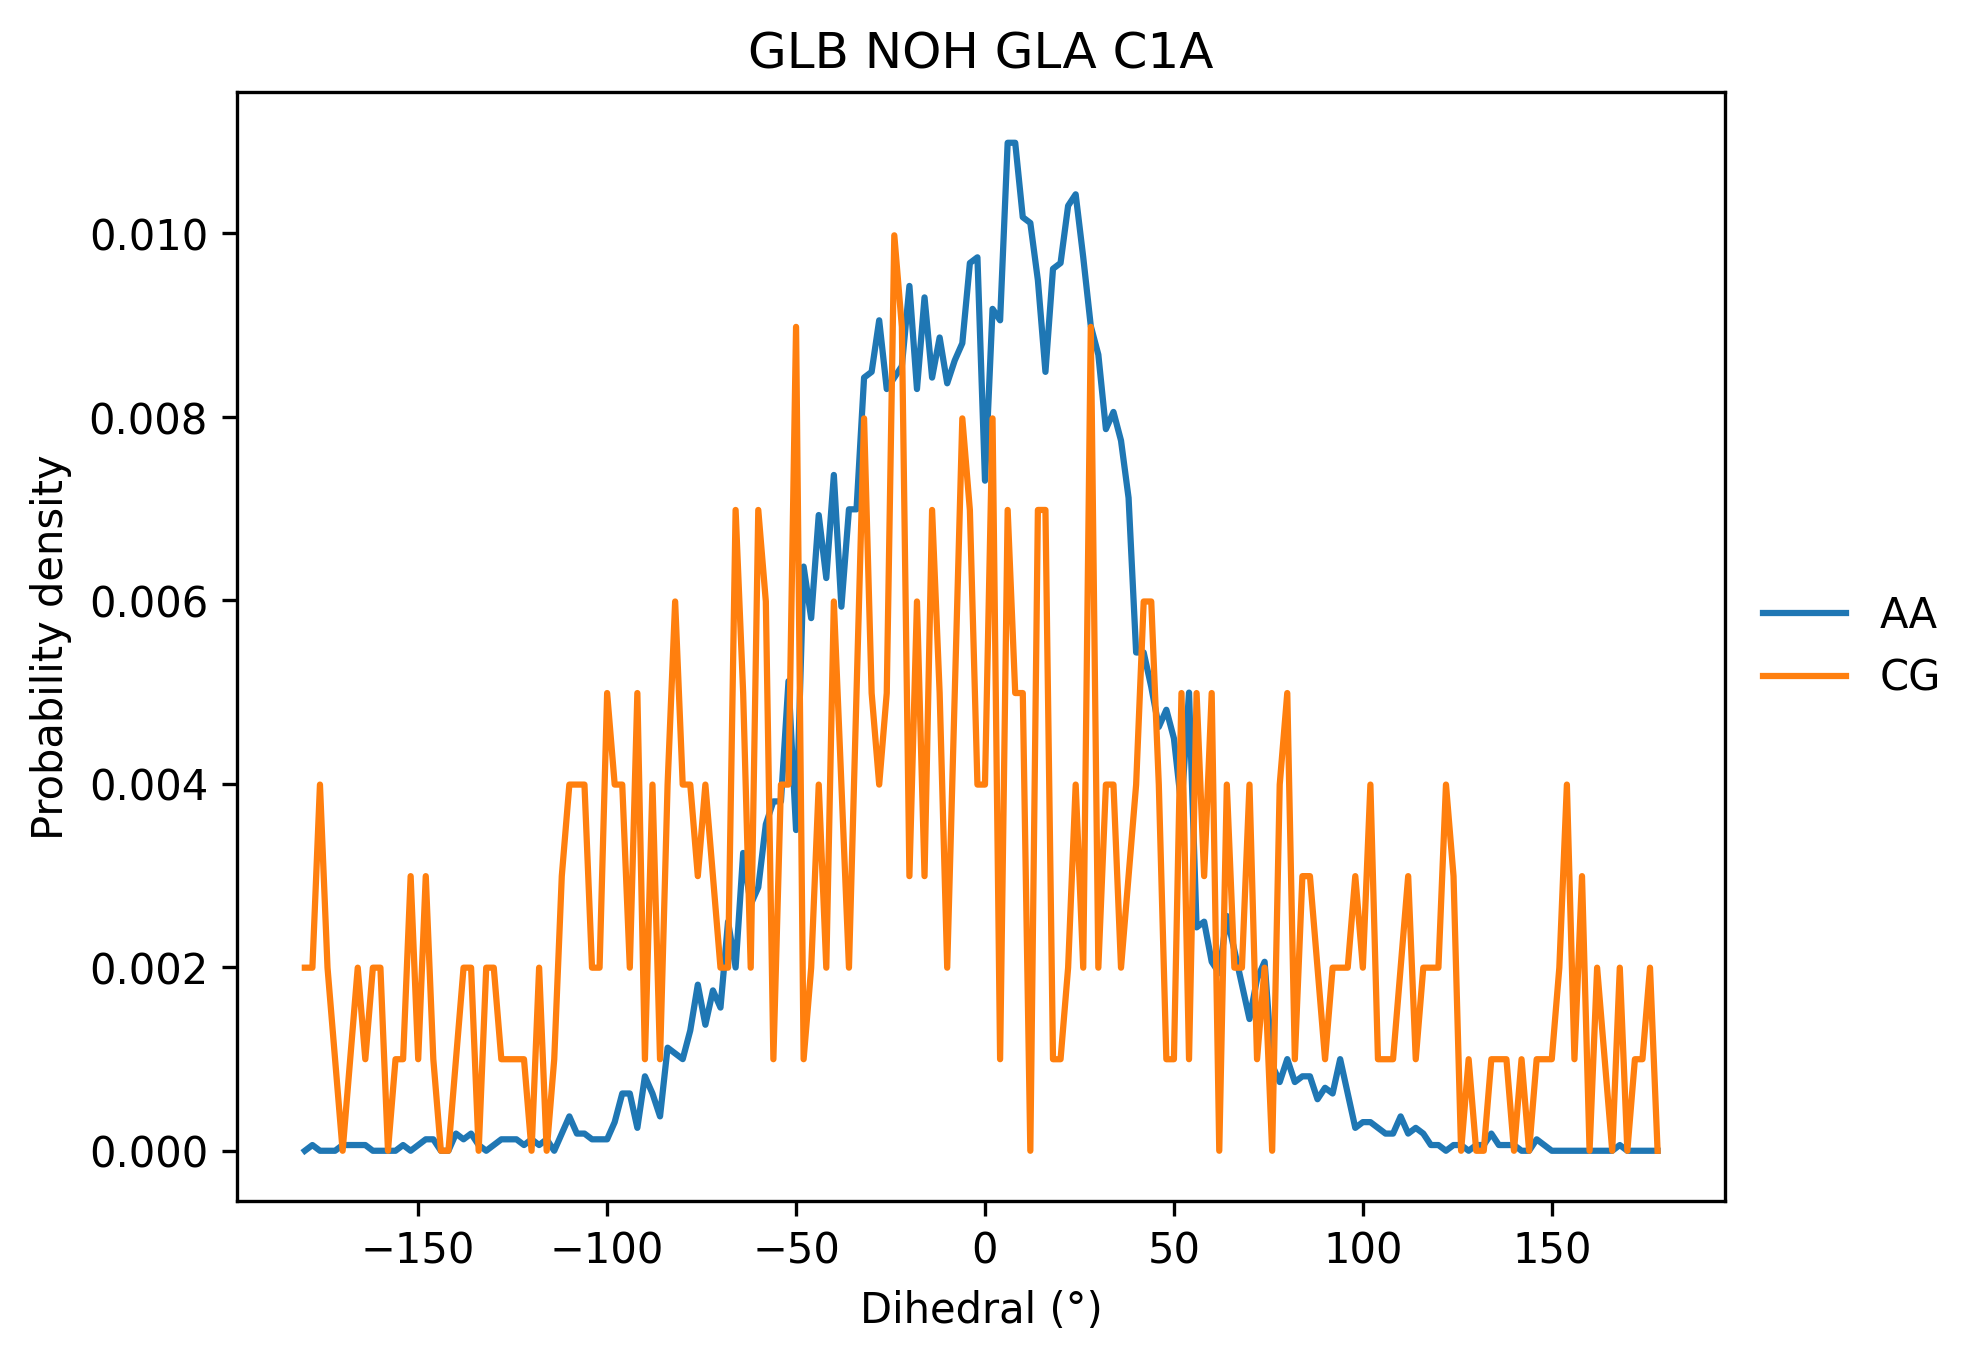

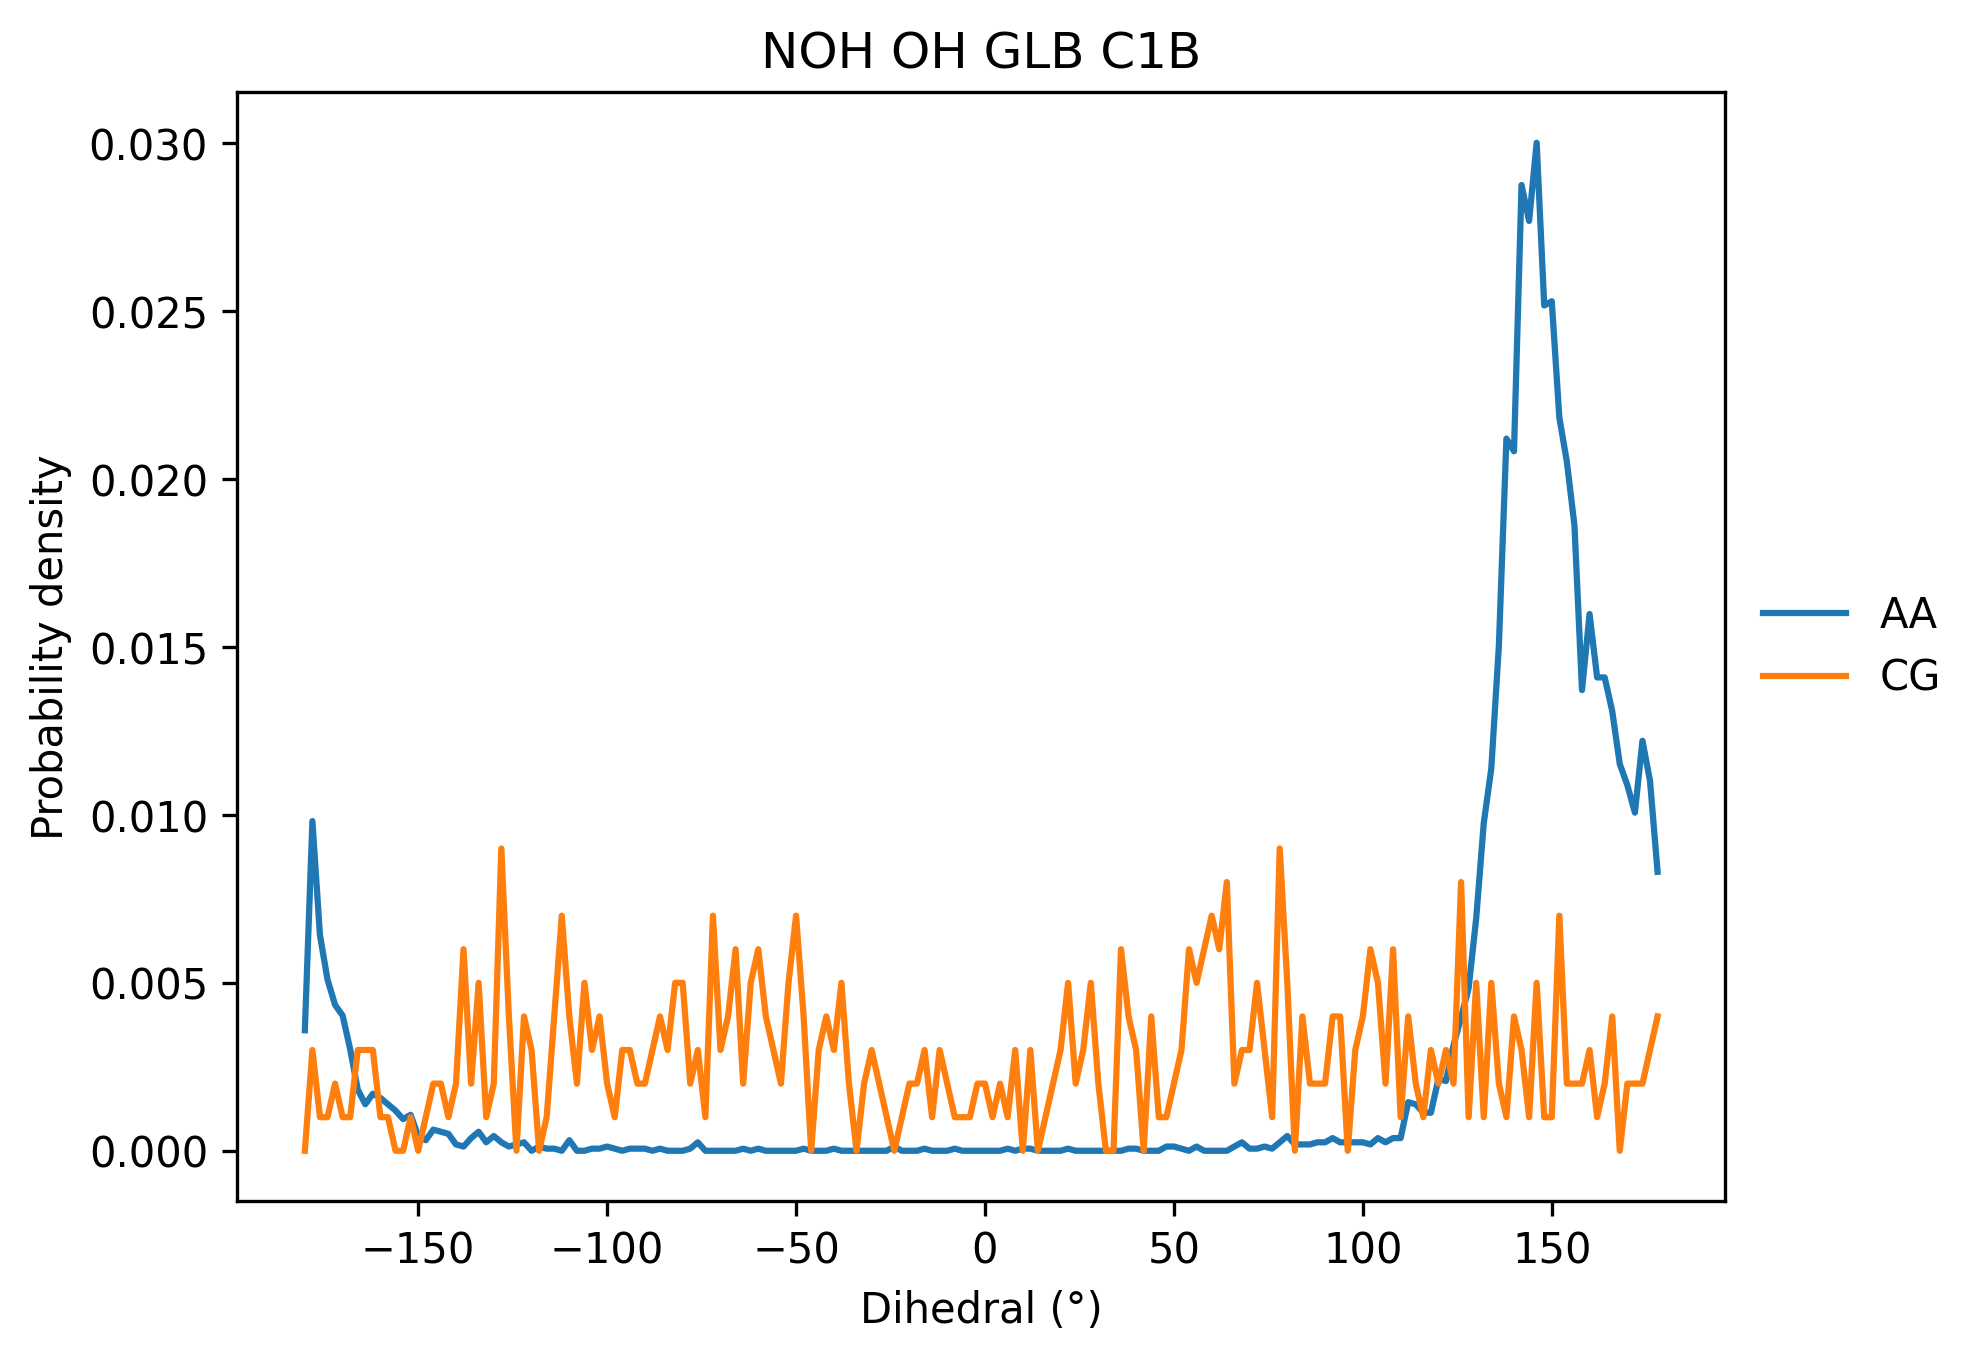

In [31]:
for dihed in List_dihed:

    HAA,BAA = np.histogram(np.array(dihed_aa)[dihed,:], bins=bins_dihed, density=True)
    HCG,BCG = np.histogram(np.array(dihed_cg)[dihed,:], bins=bins_dihed, density=True)


    plt.plot(bins_dihed_x, HAA, label='AA')
    plt.plot(bins_dihed_x, HCG, label='CG')
    title = ' '.join(i for i in dihed_tgts[dihed[0]])
    plt.title(title) 
    plt.xlabel('Dihedral (°)')
    plt.ylabel('Probability density')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.savefig('{}_water_dihedral.png'.format(title), dpi=300, bbox_inches='tight')
    plt.show()

In [32]:
pwd

'/mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT'

#### you can optimize the bonded parameters now and then re-run. 
Remember to check SASA as well

entering /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT/CG_SASA

         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

NOTE: From version 5.0 gmx sasa uses the Van der Waals rad

                       :-) GROMACS - gmx sasa, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT/CG_SASA
Command line:
  gmx sasa -f ../pbc.xtc -s ../pbc.gro -n /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT/CG_SASA/index.ndx -ndots 4800 -probe 0.191 -or /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT/CG_SASA/resarea_SASA.xvg -o /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT/CG_SASA/SASA.xvg


++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
Frank Eisenhaber and Philip Lijnzaad and Patrick Argos and Chris Sander and
Michael Scharf
The Double Cube Lattice Method: Efficient Approaches to Numerical Integration
of Surface Area and Volume and to Dot Surface Contouring of Molecular
Assemblies
J. Comp. Chem. 16 (1995) pp. 273-284
-------- -------- --- Thank You --- -------- --------

Reading frame       0 time    0.000   
Back Off! I just backed up /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_WAT/CG_SASA/SASA.xvg to /mnt/f/


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

NOTE: From version 5.0 gmx sasa uses the Van der Waals radii
from the source below. This means the results may be di

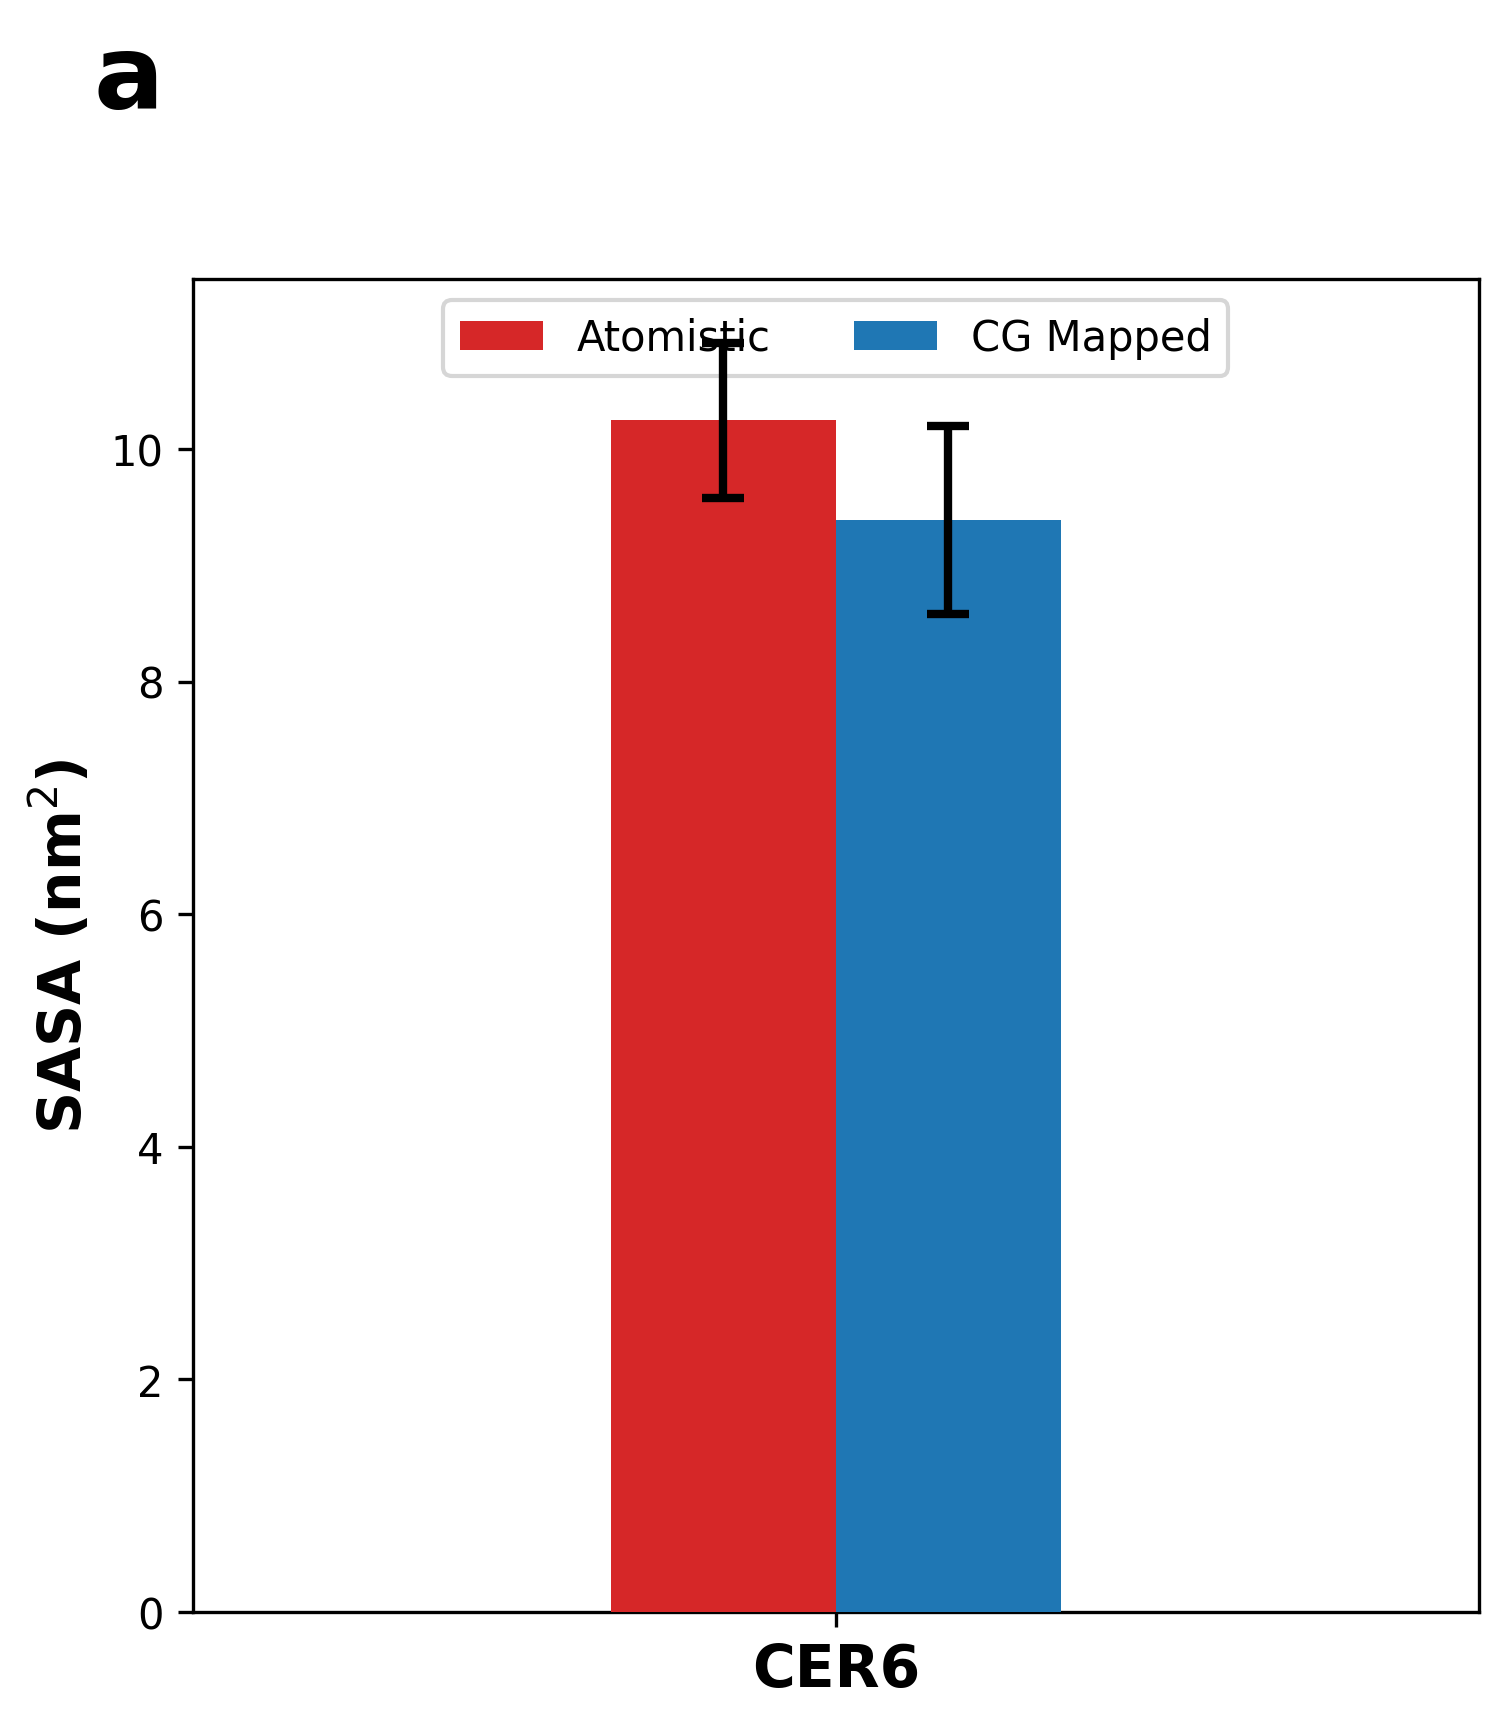

In [33]:
cg_dir =  os.getcwd()

os.chdir(cg_dir)

CG  = ['pbc.gro', #GRO
       'pbc.xtc'] #XTX

run_SASA('CG_SASA', CG, resname, cg_dir, bead_names, bead_sizes)

CG_xvg = '{}/CG_WAT/CG_SASA/resarea_SASA.xvg'.format(main_dir)
AA_xvg = '{}/AA/resarea_SASA.xvg'.format(main_dir)
plot_SASA(AA_xvg, CG_xvg, resname)
plt.savefig('SASA.png'.format(title), dpi=300, bbox_inches='tight')

In [34]:
#re_run(resname, mdp_loc, maxwarn=5)

## BL Later once you have fixes CER6 

In [35]:
os.chdir(main_dir)
#os.mkdir('CG_BL')
os.chdir('CG_BL')

In [36]:
#os.system('cp {}/CG_WAT/initial_CG.itp .'.format(main_dir))

In [37]:
#os.system('python2.7 insane.py -l CER:30 -l POPC:70 -pbc cubic -x 5 -y 5 -z 10 -sol W -o mem.gro -p topol.top')
os.system('python2.7 insane.py -l CER6:30 -l POPC:70 -pbc cubic -x 5 -y 5 -z 10 -sol W -o mem.gro -p topol.top')

; X: 5.000 (6 bins) Y: 5.000 (6 bins) in upper leaflet
; X: 5.000 (6 bins) Y: 5.000 (6 bins) in lower leaflet
; 36 lipids in upper leaflet, 36 lipids in lower leaflet
; NDX Solute 1 0
; Charge of protein: 0.000000
; NDX Membrane 1 760
; Charge of membrane: 0.000000
; Total charge: 0.000000
; NDX Solvent 761 2092
; NDX System 1 2092
; "I mean, the good stuff is just INSANE" --Julia Ormond


0

In [38]:
#os.system("sed -i 's/{}/KC2/g' initial_CG.itp".format(resname))
!rm *.tpr

rm: cannot remove '*.tpr': No such file or directory


In [39]:
prepare_setup_BL('initial_CG.itp', mdp_loc_BL)

                      :-) GROMACS - gmx grompp, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_BL
Command line:
  gmx grompp -f /mnt/f/BILAYERS/MDPs/min.mdp -c mem.gro -p topol.top -o memion.tpr -maxwarn 5


WARNING 1 [file /mnt/f/BILAYERS/MDPs/min.mdp, line 331]:
  Unknown left-hand 'QMMMscheme' in parameter file



WARNING 2 [file /mnt/f/BILAYERS/MDPs/min.mdp, line 331]:
  Unknown left-hand 'MMChargeScaleFactor' in parameter file



NOTE 1 [file /mnt/f/BILAYERS/MDPs/min.mdp]:
  With Verlet lists the optimal nstlist is >= 10, with GPUs >= 20. Note
  that with the Verlet scheme, nstlist has no effect on the accuracy of
  your simulation.

Number of degrees of freedom in T-Coupling group rest is 6273.00
The integrator does not provide a ensemble temperature, there is no system ensemble temperature

There was 1 NOTE

There were 2 WARNINGs

GROMACS reminds you: "Here's something fun to do: Next time 

Setting the LD random seed to 1795075798

Generated 844 of the 356590 non-bonded parameter combinations

Excluding 1 bonded neighbours molecule type 'CER6'

Excluding 1 bonded neighbours molecule type 'POPC'

Excluding 1 bonded neighbours molecule type 'CER6'

Excluding 1 bonded neighbours molecule type 'POPC'

Excluding 1 bonded neighbours molecule type 'W'
Analysing residue names:
There are:  1402      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...

This run will generate roughly 0 Mb of data


Number of degrees of freedom in T-Coupling group rest is 6273.00
The integrator does not provide a ensemble temperature, there is no system ensemble temperature

There was 1 NOTE

There were 2 WARNINGs

GROMACS reminds you: "Here's something fun to do: Next time you approach a conversation say 'I want to talk to someone technical... Oh! There's a woman!' and walk straight over to her." (Patty Lopez)

                      :-) GROMACS - gmx genion, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_BL
Command line:
  gmx genion -s memion_2.tpr -o memion_2.gro -p topol.top -pname NA -pq +1 -nname CL -nq -1 -np 14 -nn 14

Reading file memion_2.tpr, VERSION 2023.1 (single precision)
Reading file memion_2.tpr, VERSION 2023.1 (single precision)
Group     0 (         System) has  2092 elements
Group     1 (          Other) has  2092 elements
Group     2 (           CER6) has   160 elements
Group     3 (     

Setting the LD random seed to 2141190135

Generated 844 of the 356590 non-bonded parameter combinations

Excluding 1 bonded neighbours molecule type 'CER6'

Excluding 1 bonded neighbours molecule type 'POPC'

Excluding 1 bonded neighbours molecule type 'CER6'

Excluding 1 bonded neighbours molecule type 'POPC'

Excluding 1 bonded neighbours molecule type 'W'
Analysing residue names:
There are:  1402      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...

This run will generate roughly 0 Mb of data
Will try to add 14 NA ions and 14 CL ions.
Select a continuous group of solvent molecules
Selected 4: 'W'

Processing topology
Replacing 28 solute molecules in topology file (topol.top)  by 14 NA and 14 CL ions.


Number of degrees of freedom in T-Coupling group rest is 6273.00
The integrator does not provide a ensemble temperature, there is no system ensemble temperature

There was 1 NOTE

There were 2 WARNINGs

GROMACS reminds you: "Never, I said never, compare with experiment" (Magnus Bergh)

                      :-) GROMACS - gmx mdrun, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_BL
Command line:
  gmx mdrun -v -deffnm m -nt 5


Back Off! I just backed up m.log to ./#m.log.1#
Reading file m.tpr, VERSION 2023.1 (single precision)
Using 1 MPI thread
Using 5 OpenMP threads 


NOTE: The number of threads is not equal to the number of (logical) cpus
      and the -pin option is set to auto: will not pin threads to cpus.
      This can lead to significant performance degradation.
      Consider using -pin on (and -pinoffset in case you run multiple jobs).

Back Off! I just backed up m.trr to ./#m.trr.1#



...

Step=  115, Dmax= 4.6e-02 nm, Epot= -6.24429e+04 Fmax= 4.66204e+03, atom= 2065
Step=  116, Dmax= 5.5e-02 nm, Epot= -6.24556e+04 Fmax= 1.31698e+03, atom= 2065
Step=  118, Dmax= 3.3e-02 nm, Epot= -6.25806e+04 Fmax= 1.48325e+03, atom= 2084
Step=  119, Dmax= 4.0e-02 nm, Epot= -6.25983e+04 Fmax= 2.05291e+03, atom= 2065
Step=  120, Dmax= 4.8e-02 nm, Epot= -6.26420e+04 Fmax= 1.46249e+03, atom= 2069
Step=  121, Dmax= 5.7e-02 nm, Epot= -6.26523e+04 Fmax= 4.56911e+03, atom= 2084
Step=  122, Dmax= 6.9e-02 nm, Epot= -6.26635e+04 Fmax= 1.14959e+03, atom= 2065
Step=  124, Dmax= 4.1e-02 nm, Epot= -6.29014e+04 Fmax= 1.82897e+03, atom= 2065
Step=  125, Dmax= 4.9e-02 nm, Epot= -6.29162e+04 Fmax= 1.30122e+03, atom= 2065
Step=  127, Dmax= 3.0e-02 nm, Epot= -6.30337e+04 Fmax= 1.26079e+03, atom= 2069
Step=  128, Dmax= 3.6e-02 nm, Epot= -6.30406e+04 Fmax= 2.94586e+03, atom= 2065
Step=  129, Dmax= 4.3e-02 nm, Epot= -6.30708e+04 Fmax= 1.21847e+03, atom= 2065
Step=  131, Dmax= 2.6e-02 nm, Epot= -6.31942e+04 Fma

Setting the LD random seed to -654738705

Generated 844 of the 356590 non-bonded parameter combinations

Excluding 1 bonded neighbours molecule type 'CER6'

Excluding 1 bonded neighbours molecule type 'POPC'

Excluding 1 bonded neighbours molecule type 'CER6'

Excluding 1 bonded neighbours molecule type 'POPC'

Excluding 1 bonded neighbours molecule type 'W'

Excluding 1 bonded neighbours molecule type 'NA'

Excluding 1 bonded neighbours molecule type 'CL'

Setting gen_seed to -1562916997

Velocities were taken from a Maxwell distribution at 310 K

Determining Verlet buffer for a tolerance of 0.002 kJ/mol/ps at 310 K

Calculated rlist for 1x1 atom pair-list as 1.199 nm, buffer size 0.099 nm

Set rlist, assuming 4x4 atom pair-list, to 1.156 nm, buffer size 0.056 nm

Note that mdrun will redetermine rlist based on the actual pair-list setup

This run will generate roughly 112 Mb of data


step 999900, remaining wall clock time:     0 s          
Writing final coordinates.

Back Off! I just backed up r.gro to ./#r.gro.1#
step 1000000, remaining wall clock time:     0 s          
               Core t (s)   Wall t (s)        (%)
       Time:      652.305      130.473      500.0
                 (ns/day)    (hour/ns)
Performance:     6622.075        0.004

GROMACS reminds you: "What Kind Of Guru are You, Anyway ?" (F. Zappa)

                      :-) GROMACS - gmx grompp, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_BL
Command line:
  gmx grompp -f /mnt/f/BILAYERS/MDPs/prod_310.mdp -c r.gro -p topol.top -o p.tpr -n index.ndx -maxwarn 5

Ignoring obsolete mdp entry 'title'
Ignoring obsolete mdp entry 'ns_type'
Replacing old mdp entry 'nstxtcout' by 'nstxout-compressed'
Replacing old mdp entry 'xtc_precision' by 'compressed-x-precision'
Number of degrees of freedom in T-Coupling grou

Setting the LD random seed to -11542597

Generated 844 of the 356590 non-bonded parameter combinations

Excluding 1 bonded neighbours molecule type 'CER6'

Excluding 1 bonded neighbours molecule type 'POPC'

Excluding 1 bonded neighbours molecule type 'CER6'

Excluding 1 bonded neighbours molecule type 'POPC'

Excluding 1 bonded neighbours molecule type 'W'

Excluding 1 bonded neighbours molecule type 'NA'

Excluding 1 bonded neighbours molecule type 'CL'

Determining Verlet buffer for a tolerance of 0.002 kJ/mol/ps at 310 K

Calculated rlist for 1x1 atom pair-list as 1.334 nm, buffer size 0.234 nm

Set rlist, assuming 4x4 atom pair-list, to 1.252 nm, buffer size 0.152 nm

Note that mdrun will redetermine rlist based on the actual pair-list setup

This run will generate roughly 208 Mb of data


step 99999900, remaining wall clock time:     0 s          
Writing final coordinates.

Back Off! I just backed up p.gro to ./#p.gro.1#
step 100000000, remaining wall clock time:     0 s          
               Core t (s)   Wall t (s)        (%)
       Time:    65524.097    13104.832      500.0
                         3h38:24
                 (ns/day)    (hour/ns)
Performance:    13185.977        0.002

GROMACS reminds you: "Here are all the 'gmx' tools... but no gmx writethesis" (Christian Blau)



In [40]:
    ###Correct for the PBC
    p = subprocess.Popen('gmx trjconv -f p.xtc -s p.tpr -o pbc.gro -pbc mol -b 0 -e 0'
                         , stdin=subprocess.PIPE, shell=True, universal_newlines=True)
    p.communicate('CER')
    p.wait()
    ###Correct for the PBC
    p = subprocess.Popen('gmx trjconv -f p.xtc -s p.tpr -o pbc.xtc -pbc mol'
                         , stdin=subprocess.PIPE, shell=True, universal_newlines=True)
    p.communicate('CER')
    p.wait()


                     :-) GROMACS - gmx trjconv, 2023.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /mnt/f/BILAYERS/CER6/gromacs_MAP2/CG_BL
Command line:
  gmx trjconv -f p.xtc -s p.tpr -o pbc.gro -pbc mol -b 0 -e 0

Will write gro: Coordinate file in Gromos-87 format
Reading file p.tpr, VERSION 2023.1 (single precision)
Reading file p.tpr, VERSION 2023.1 (single precision)
Group     0 (         System) has  2092 elements
Group     1 (          Other) has  2092 elements
Group     2 (           CER6) has   160 elements
Group     3 (           POPC) has   600 elements
Group     4 (              W) has  1304 elements
Group     5 (            ION) has    28 elements
Reading frame       0 time    0.000   
Precision of p.xtc is 0.01 (nm)

Back Off! I just backed up pbc.gro to ./#pbc.gro.1#
Last frame          0 time    0.000   
 ->  frame      0 time    0.000      
Last written: frame      0 time    0.000


GROMACS reminds you: "Here are all th

Note that major changes are planned in future for trjconv, to improve usability and utility.
Select group for output
Selected 2: 'CER6'


Reading frame    9000 time 1800000.000    ->  frame   8999 time 1799800.000      

Note that major changes are planned in future for trjconv, to improve usability and utility.
Select group for output
Selected 2: 'CER6'


Last frame      10000 time 2000000.000    ->  frame   9999 time 1999800.000      
 ->  frame  10000 time 2000000.000      
Last written: frame  10000 time 2000000.000


GROMACS reminds you: "There is no reason for any individual to have a computer in his home." (Ken Olsen, head of Digital Equipment Corp.)



0

In [41]:
#os.chdir('CG_WAT')
## Open AA   
u_aa = md.Universe('../cg_good.gro',
                   '../cg.xtc')

## Open CG
u_cg = md.Universe('pbc.gro', 'pbc.xtc')


/home/ltr/anaconda3/envs/jupyter_env/lib/python3.10/site-packages/MDAnalysis/coordinates/XDR.py:240: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn("Reload offsets from trajectory\n "


In [42]:
ang_hist_aa, dist_hist_aa, ang_aa, dist_aa = measure_bonded_terms_simple(dist_tgts, ang_tgts, u_aa, bead_names, resname, 'AA', stride=10)

Calculating distributions...


  0%|          | 0/8 [00:00<?, ?it/s]

In [47]:
ang_hist_cg, dist_hist_cg, ang_cg, dist_cg = measure_bonded_terms_simple(dist_tgts, ang_tgts, u_cg, bead_names, 'CER6', 'CG', stride=10)

Calculating distributions...


  0%|          | 0/20 [00:00<?, ?it/s]

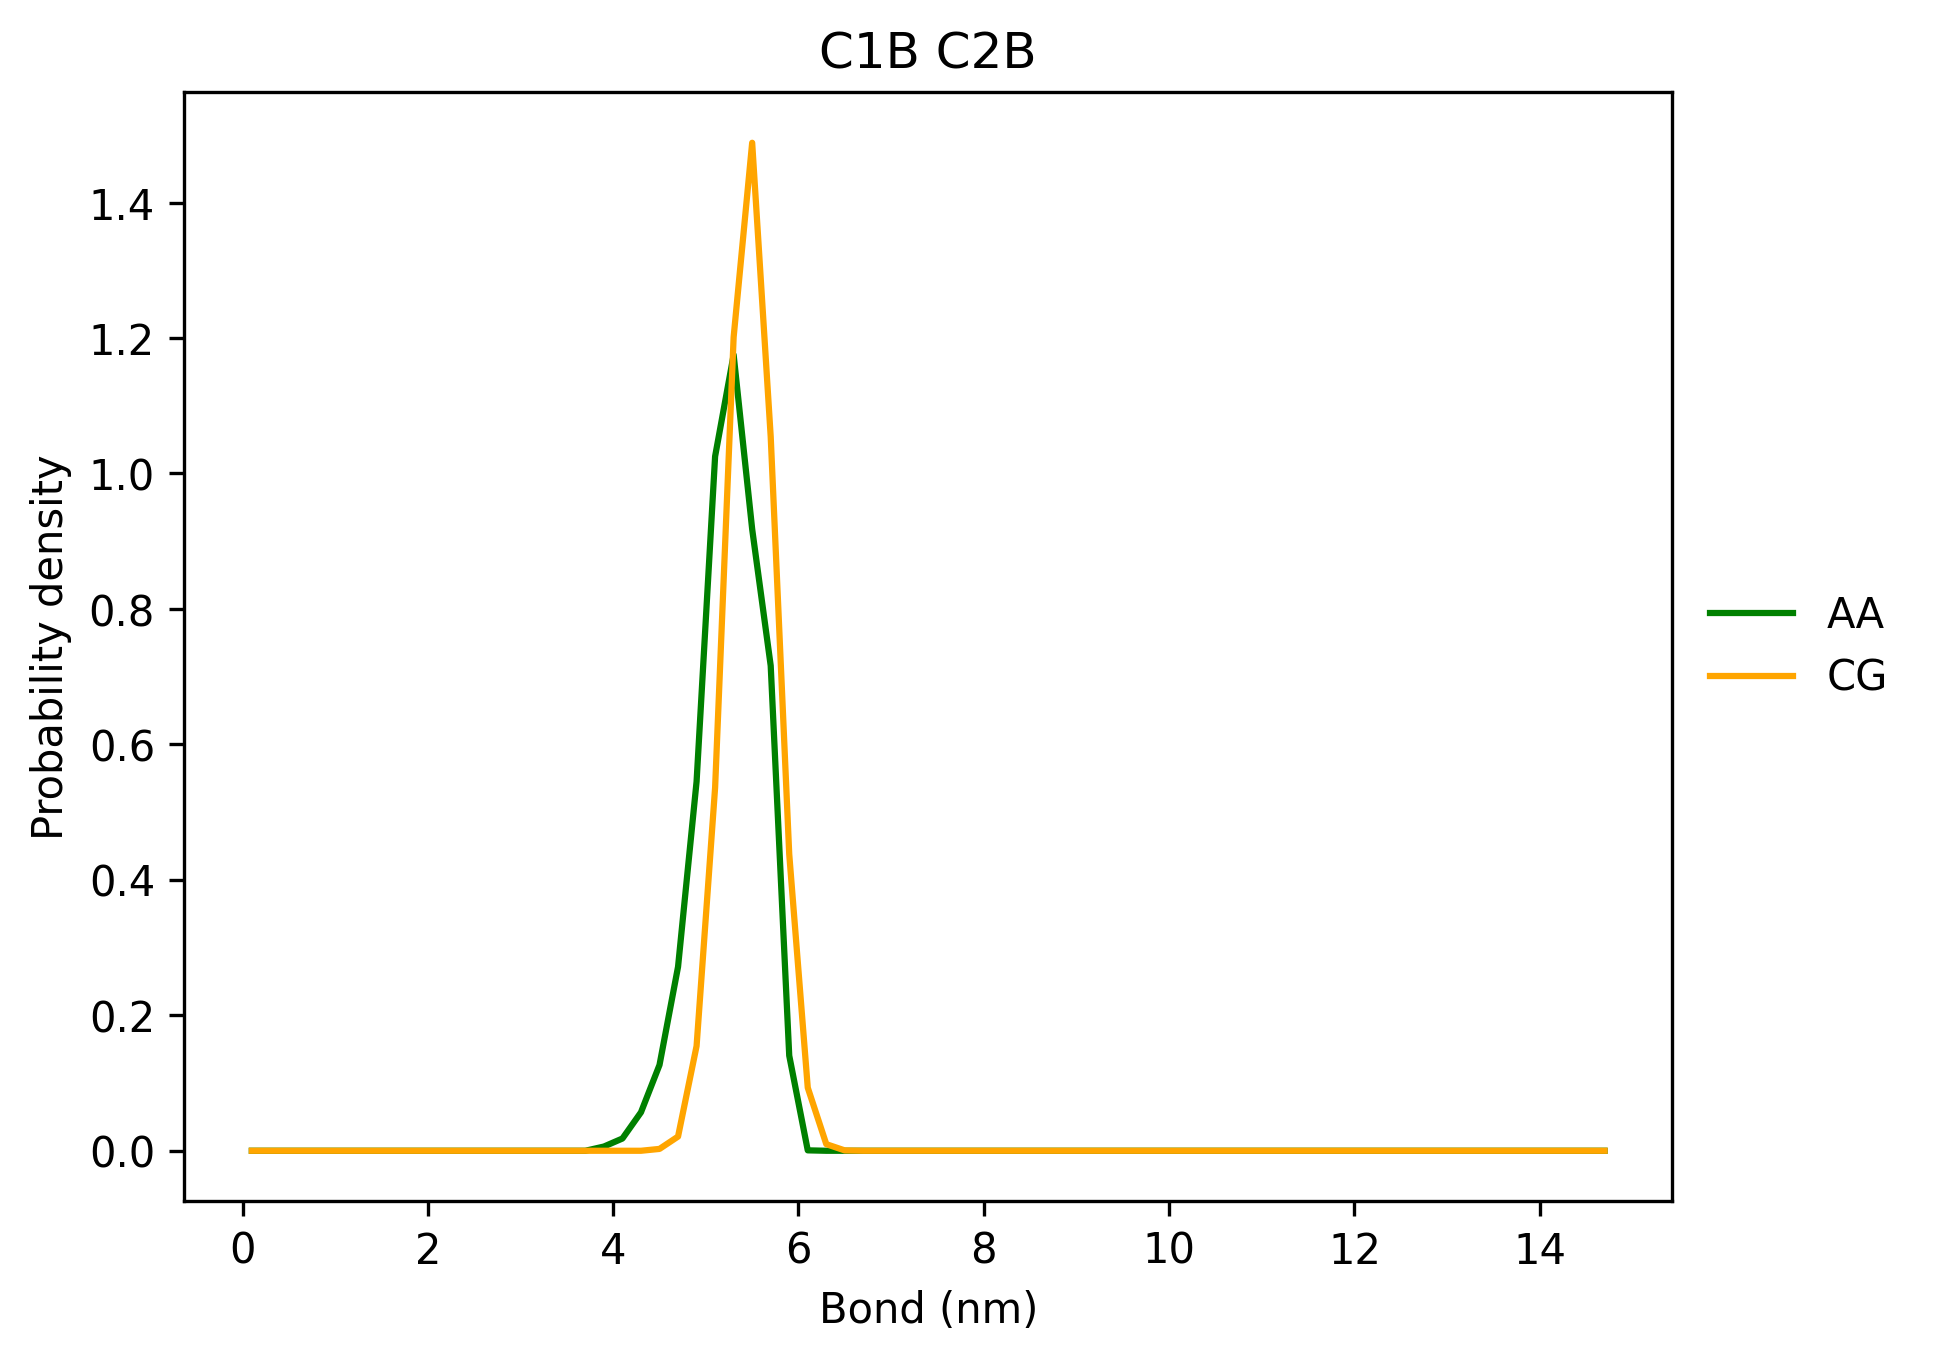

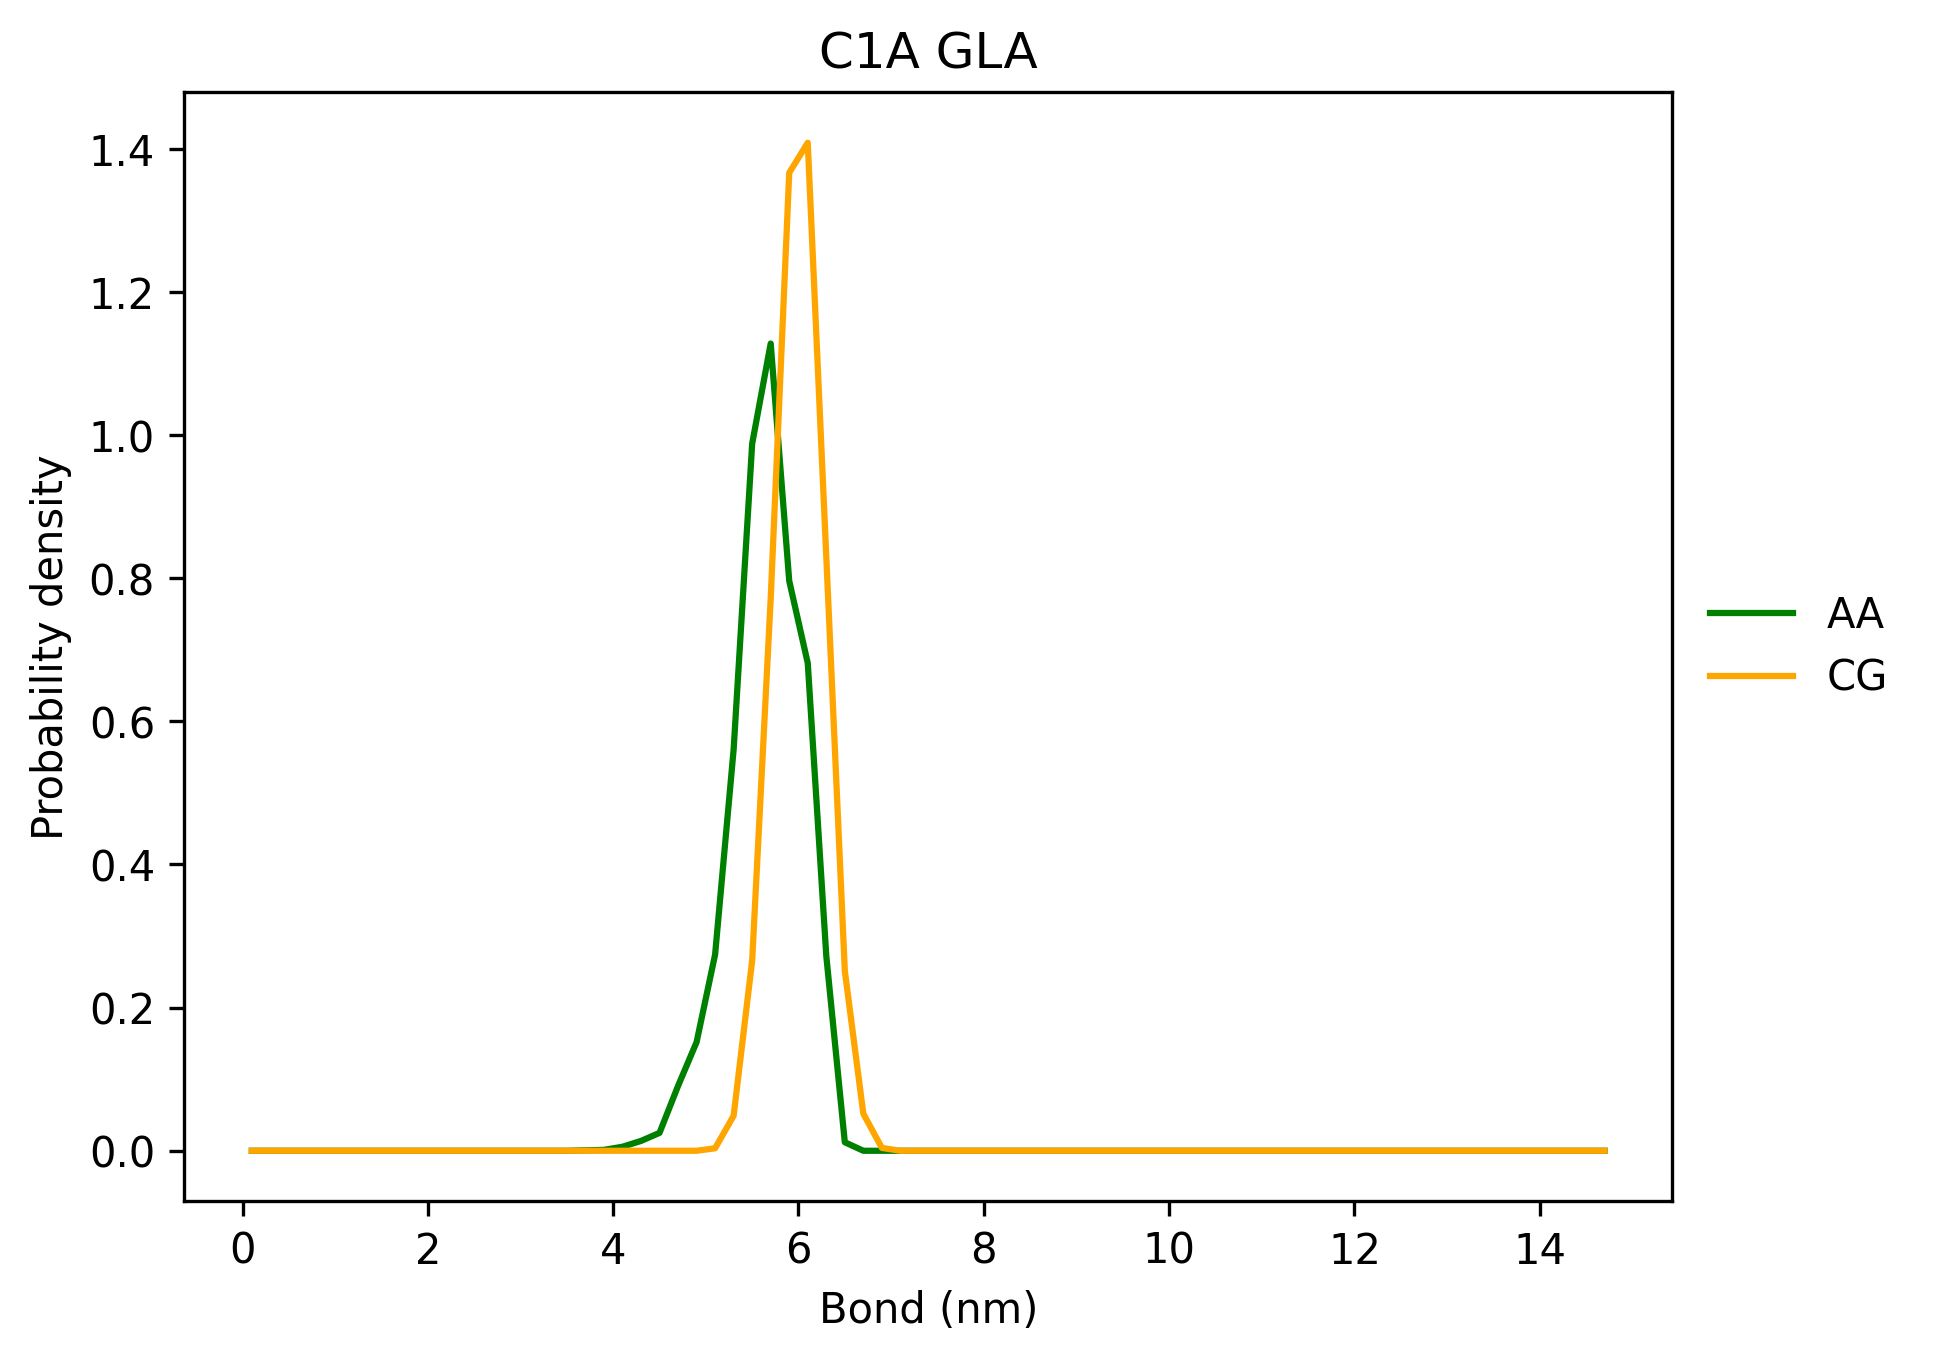

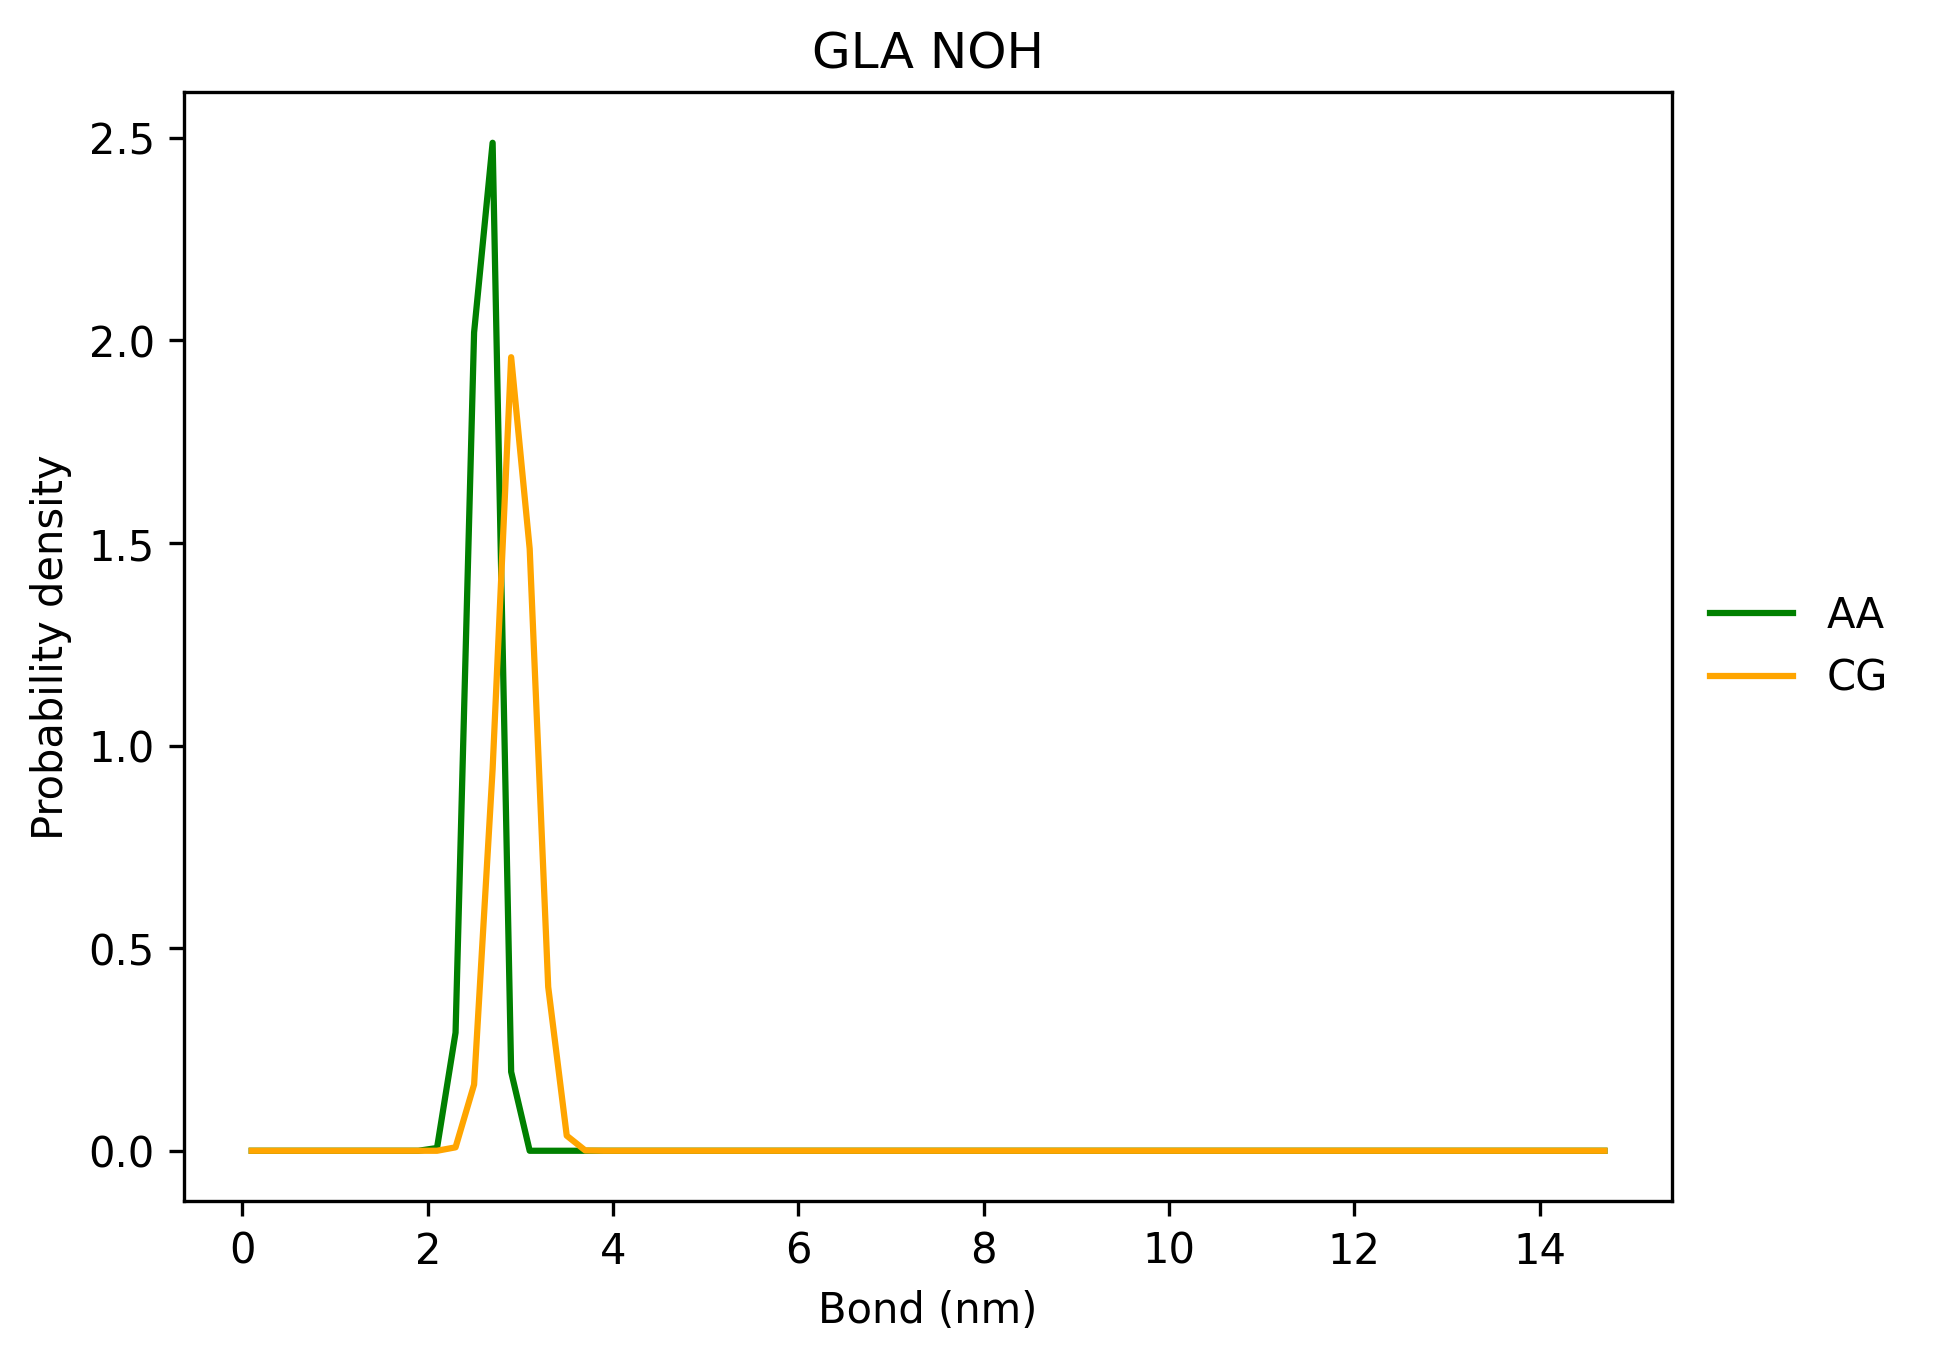

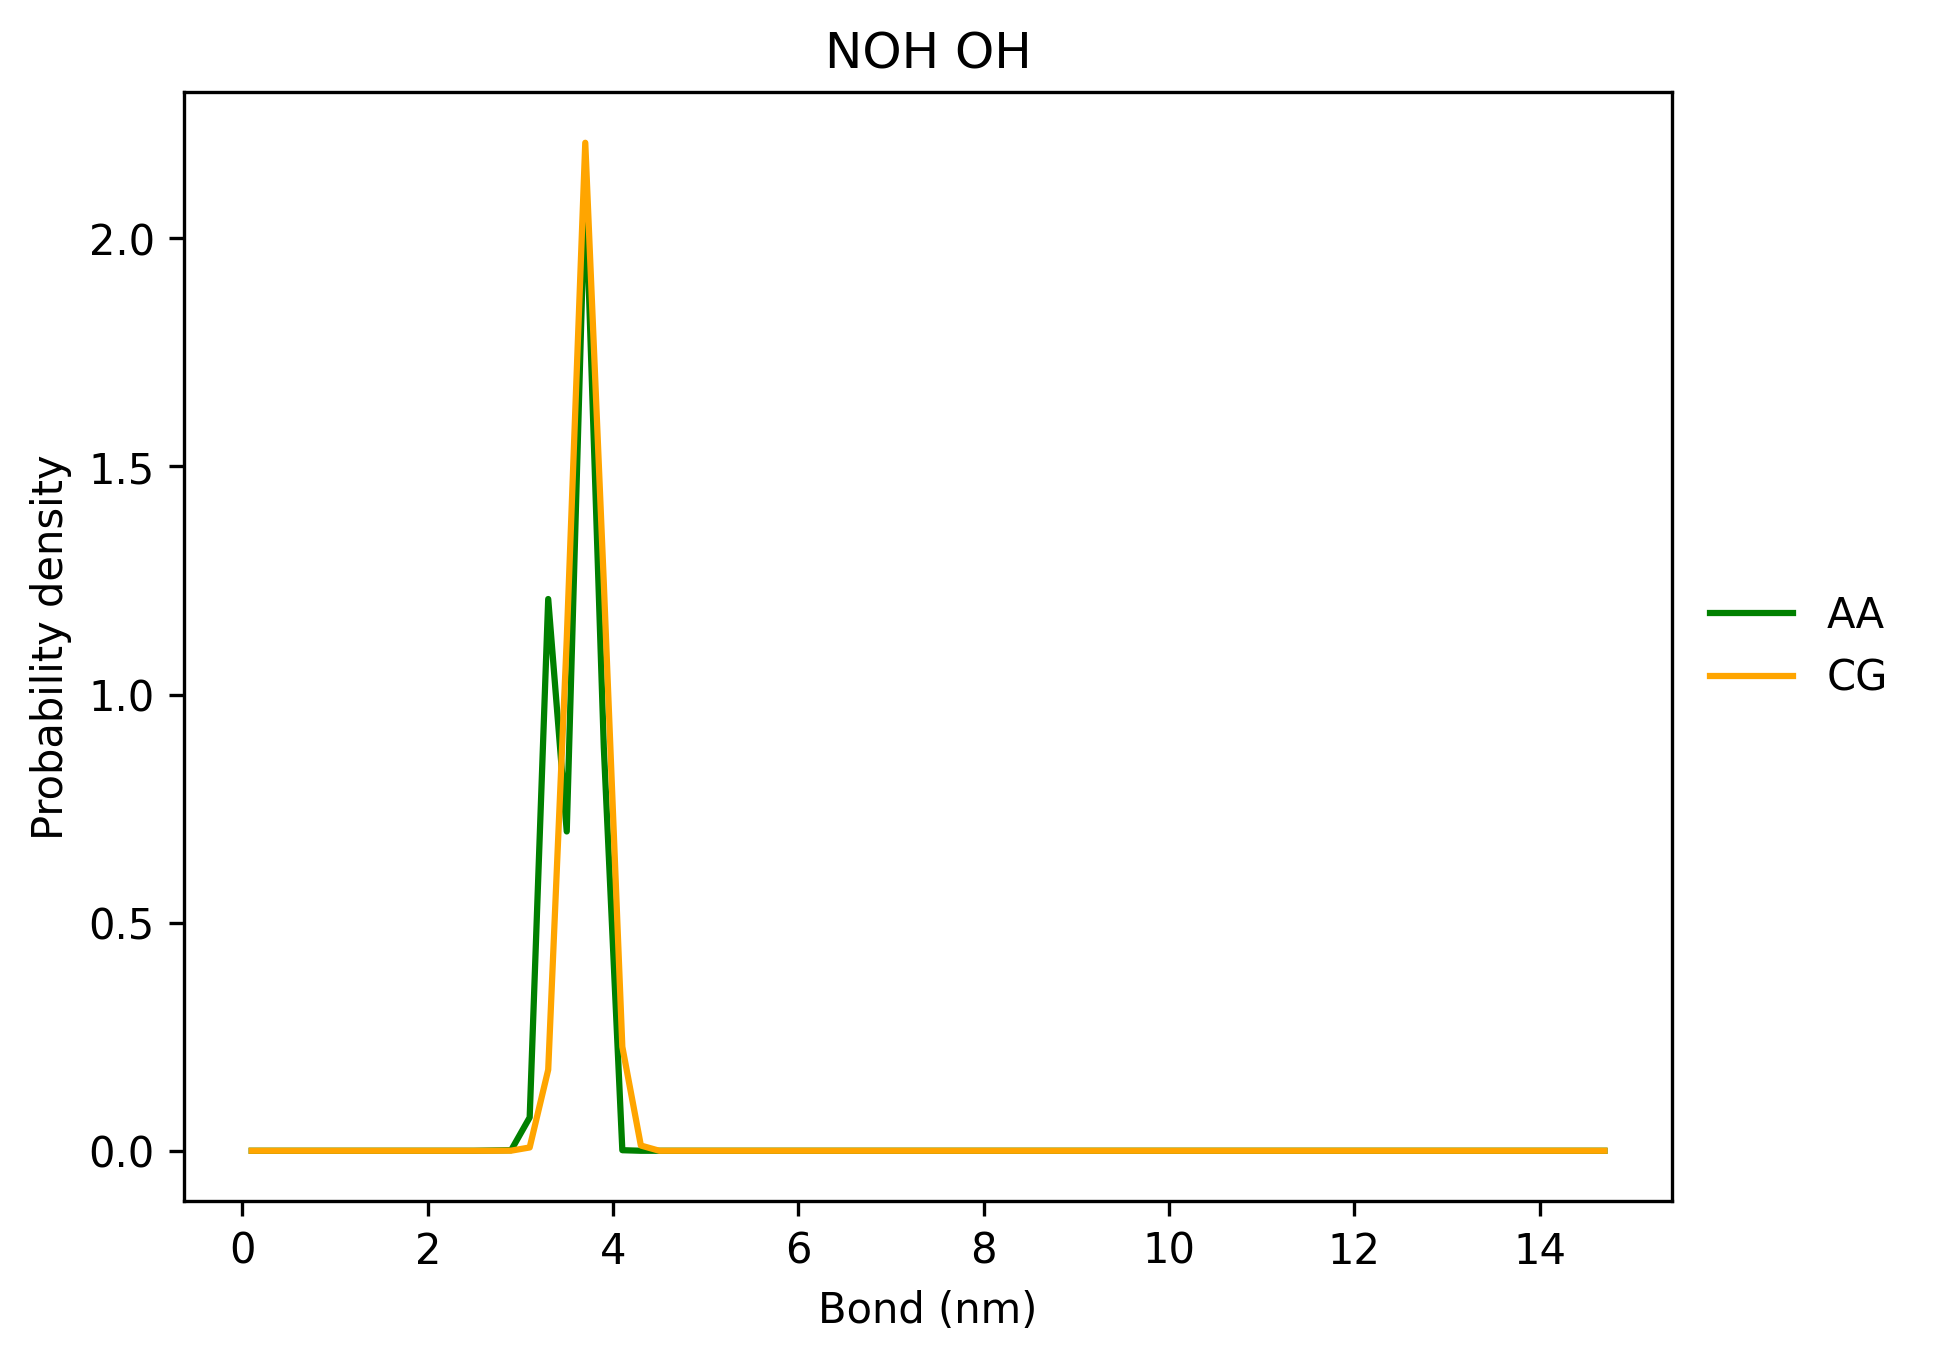

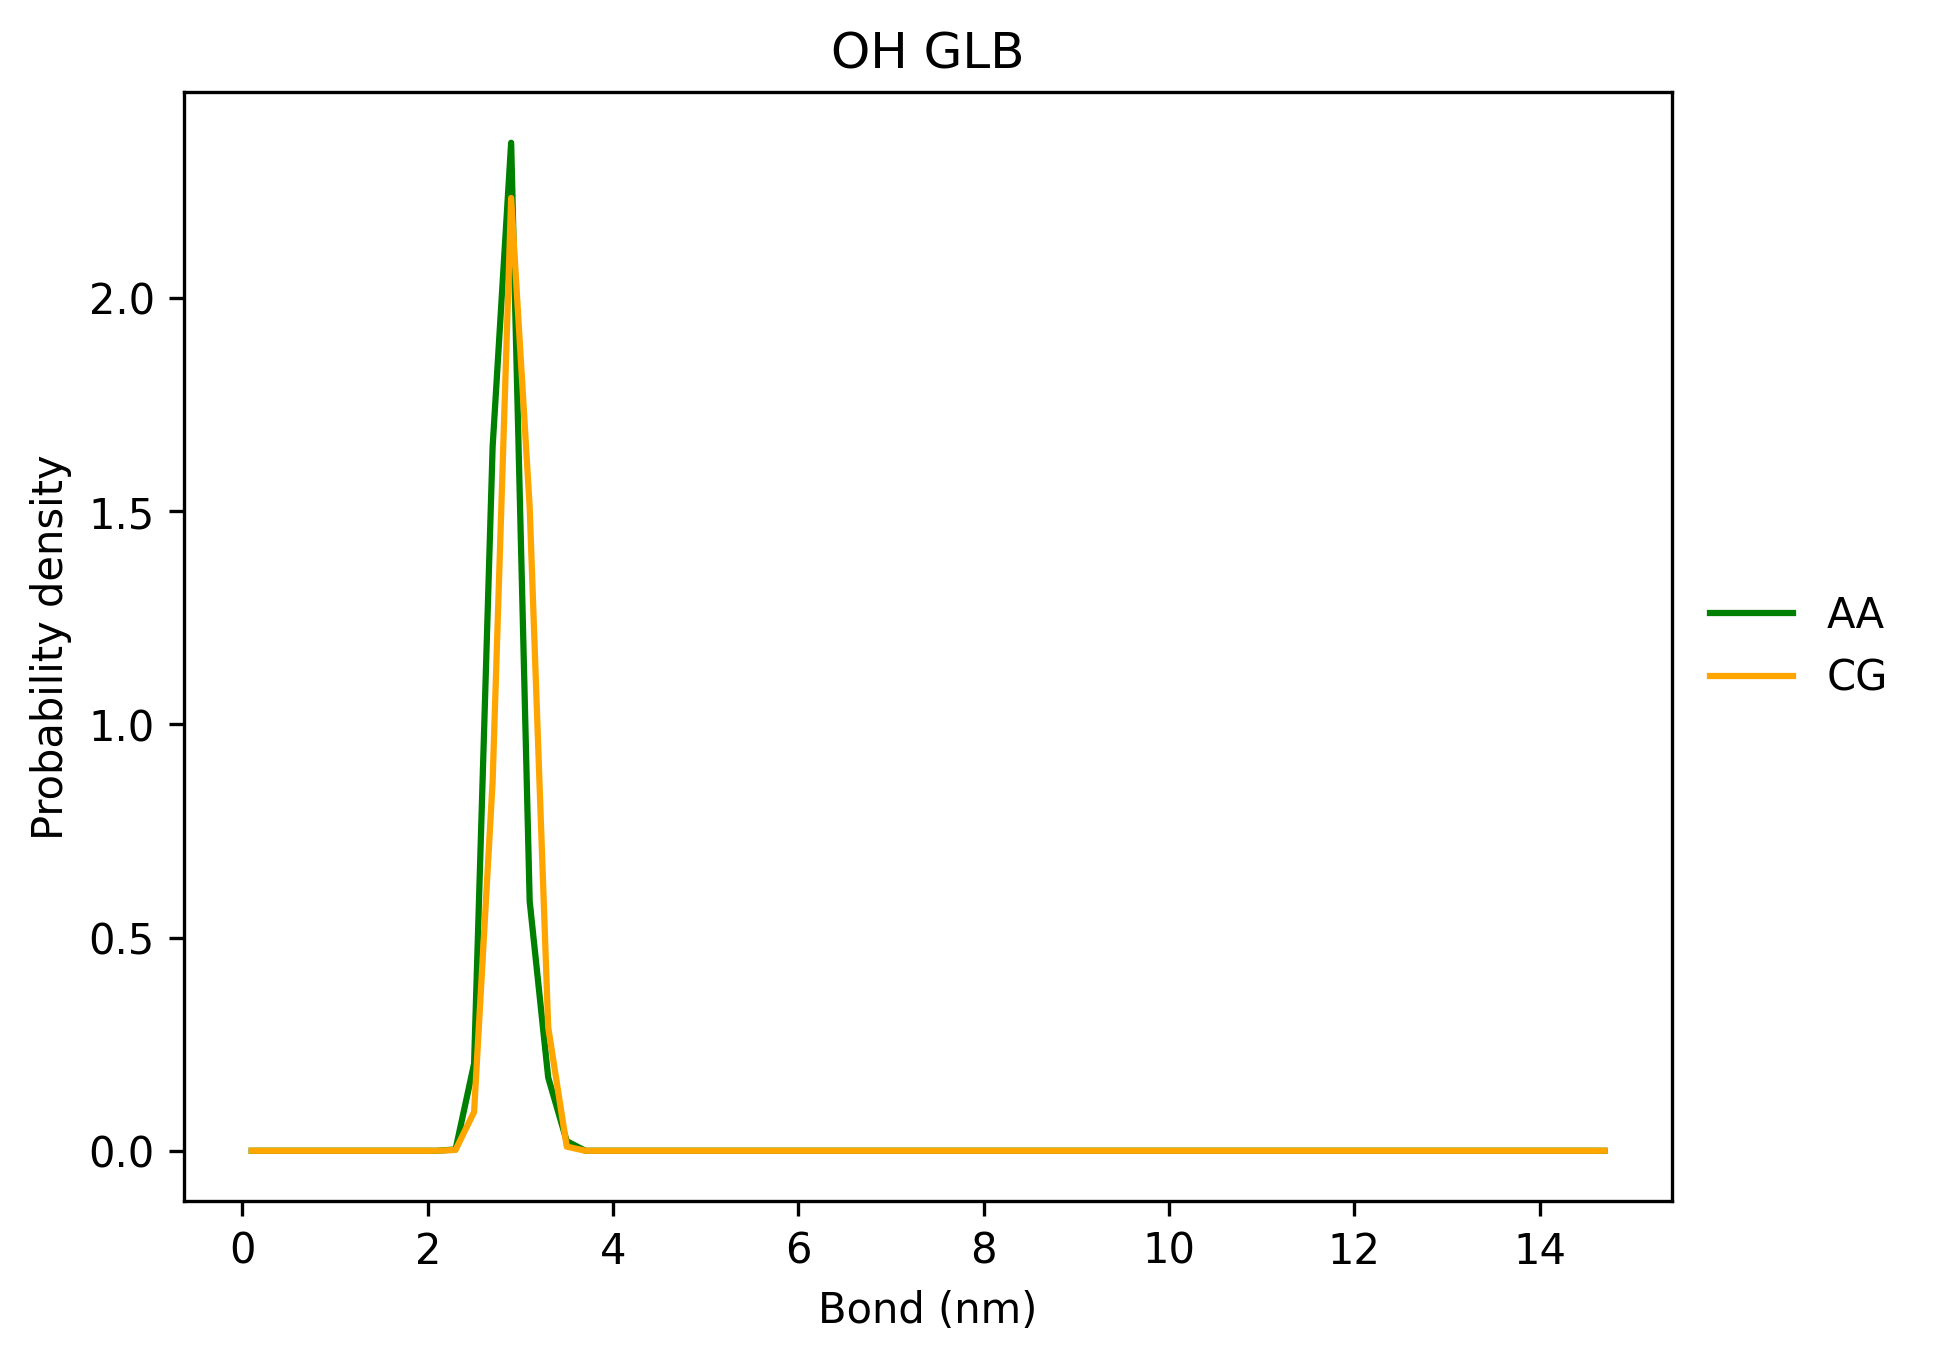

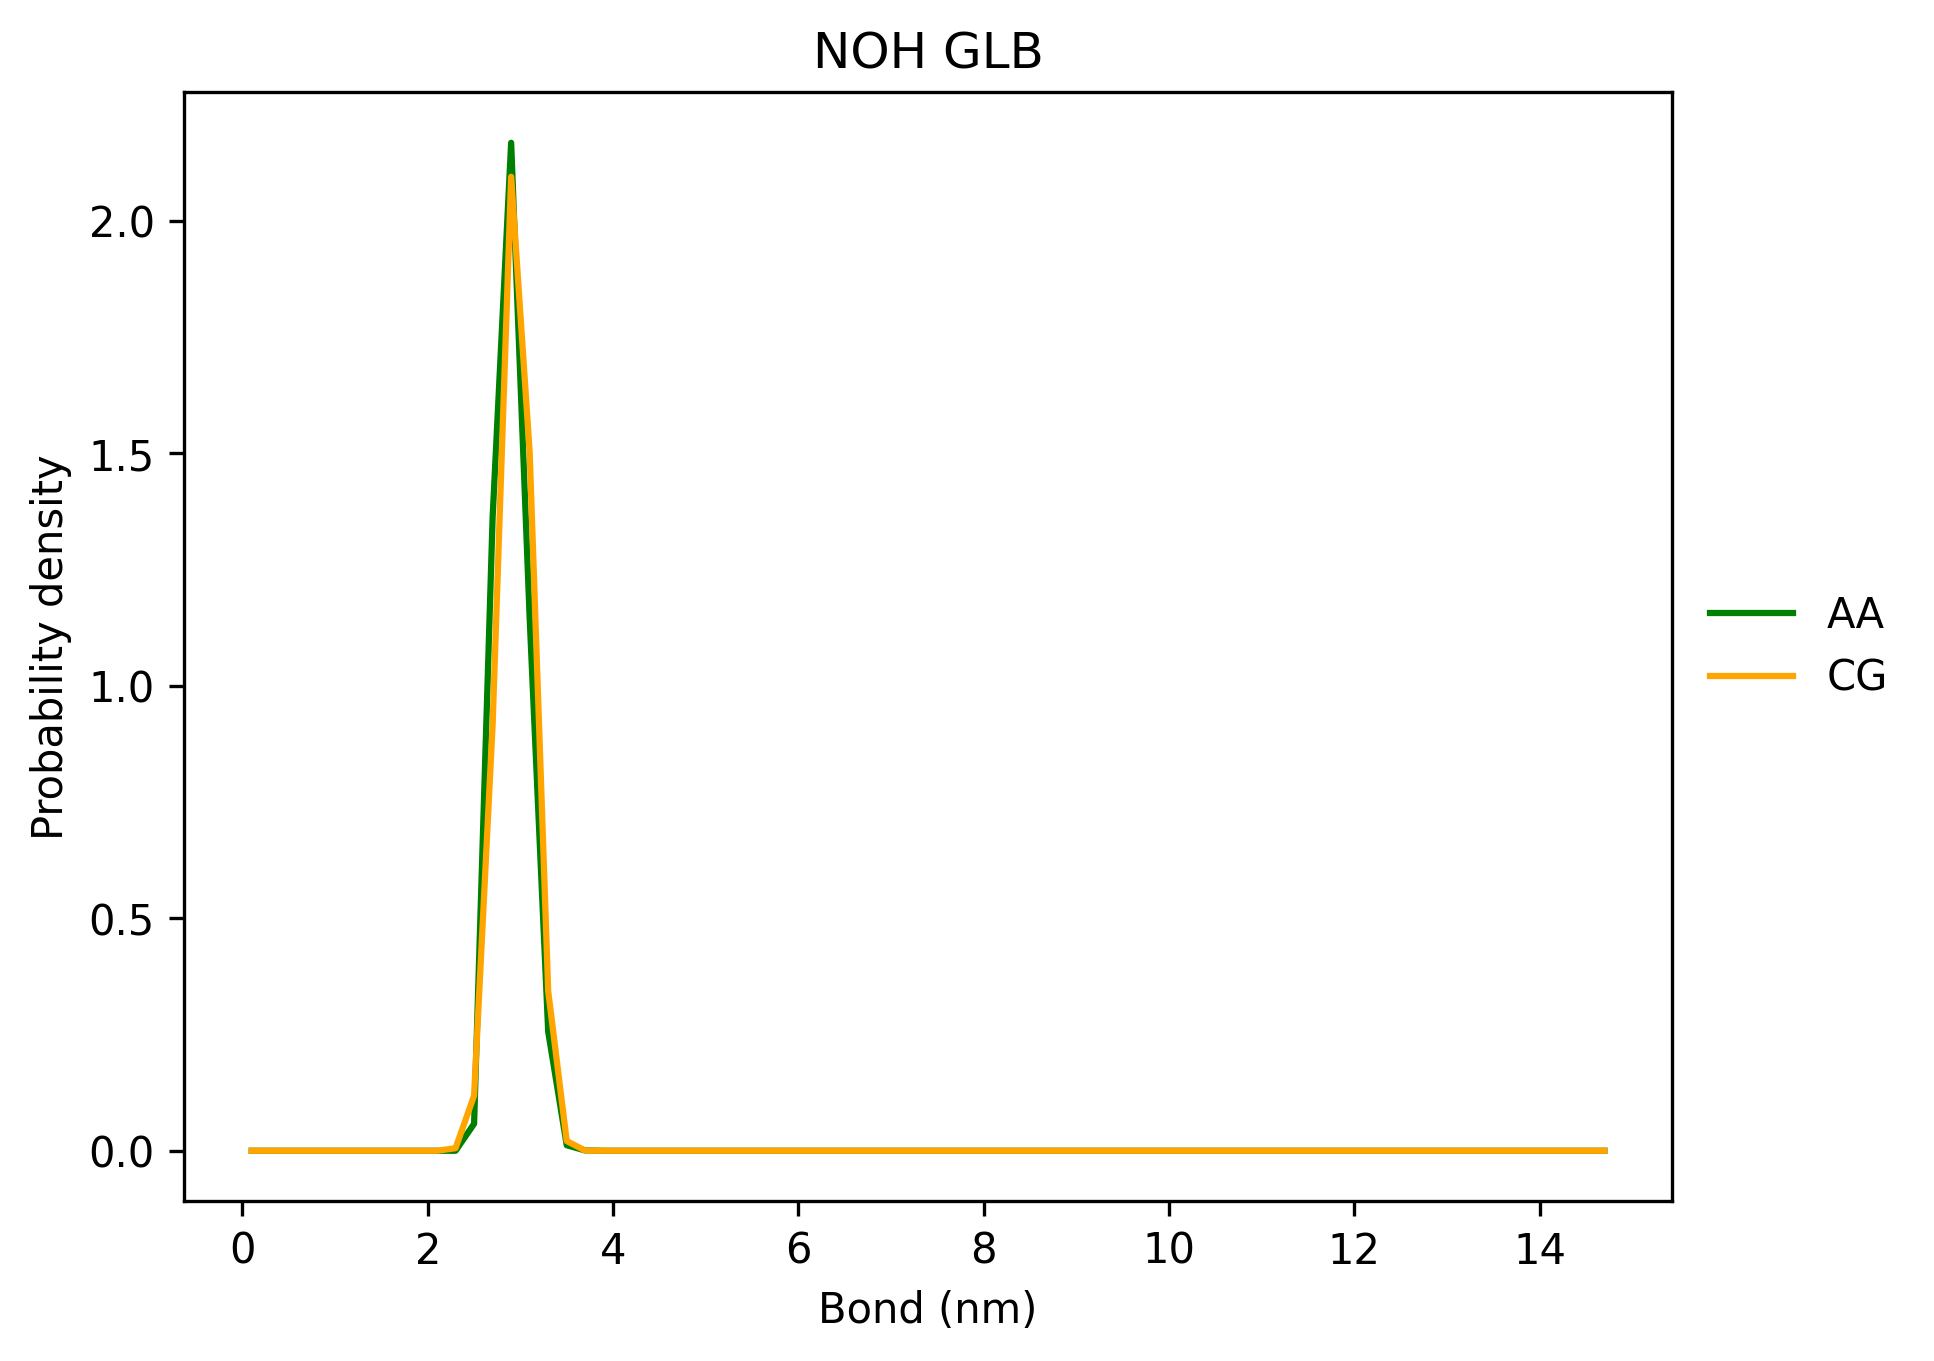

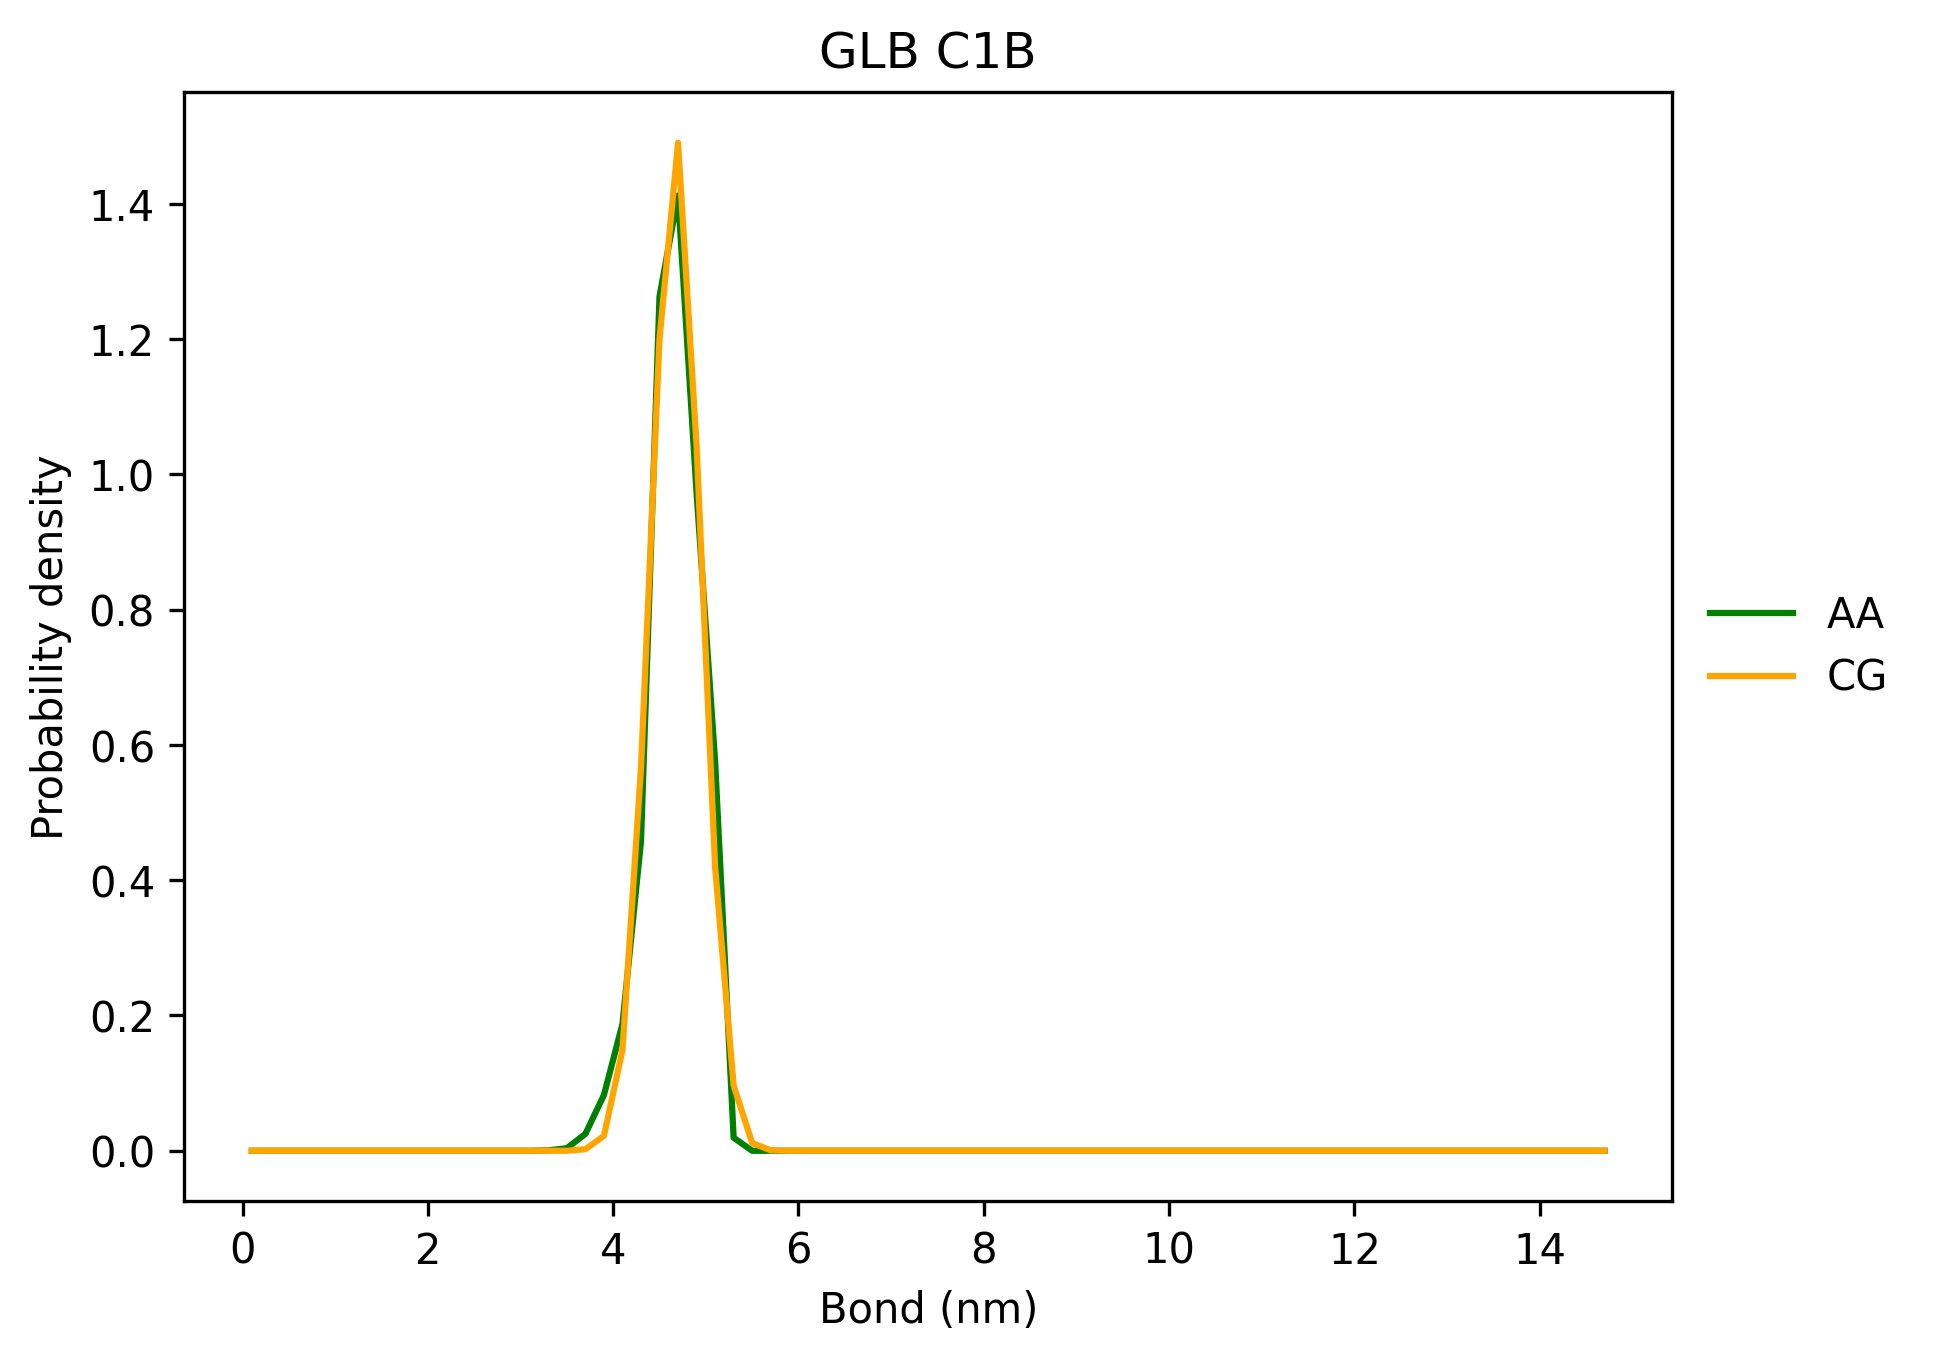

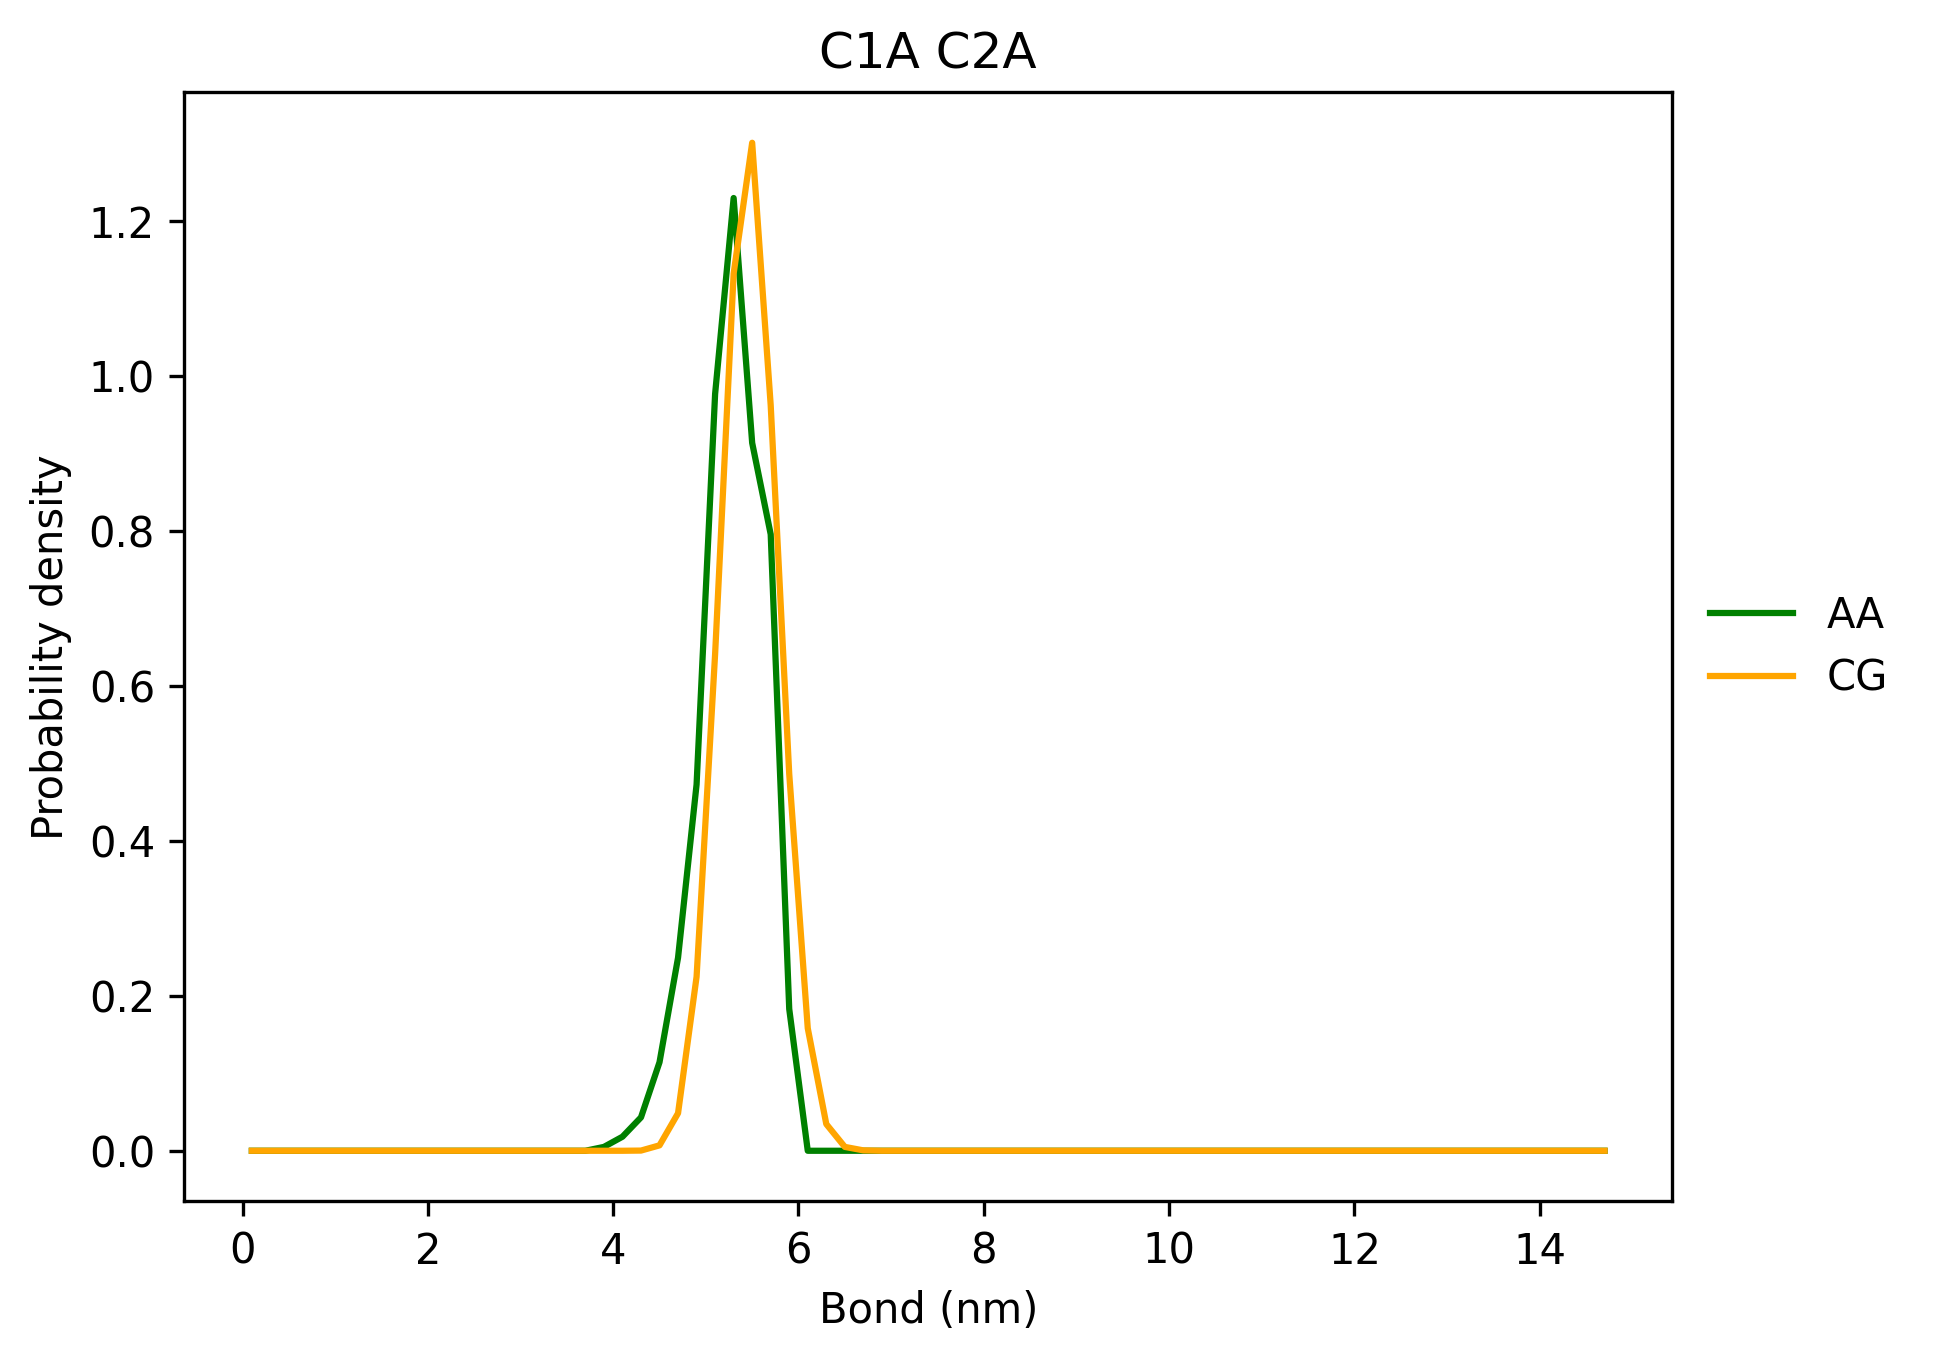

In [48]:
for bond in List_bonds:
    HAA,BAA = np.histogram(np.array(dist_aa)[bond,:], bins=bins_dist, density=True)
    HCG,BCG = np.histogram(np.array(dist_cg)[bond,:], bins=bins_dist, density=True)

    plt.plot(bins_dist_x, HAA, label='AA', color='green')
    plt.plot(bins_dist_x, HCG, label='CG', color='orange')

    title = ' '.join(i for i in dist_tgts[bond[0]])
    plt.title(title) 
    plt.xlabel('Bond (nm)')
    plt.ylabel('Probability density')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.savefig('{}_BL_bond.png'.format(title), dpi=300, bbox_inches='tight')
    plt.show()

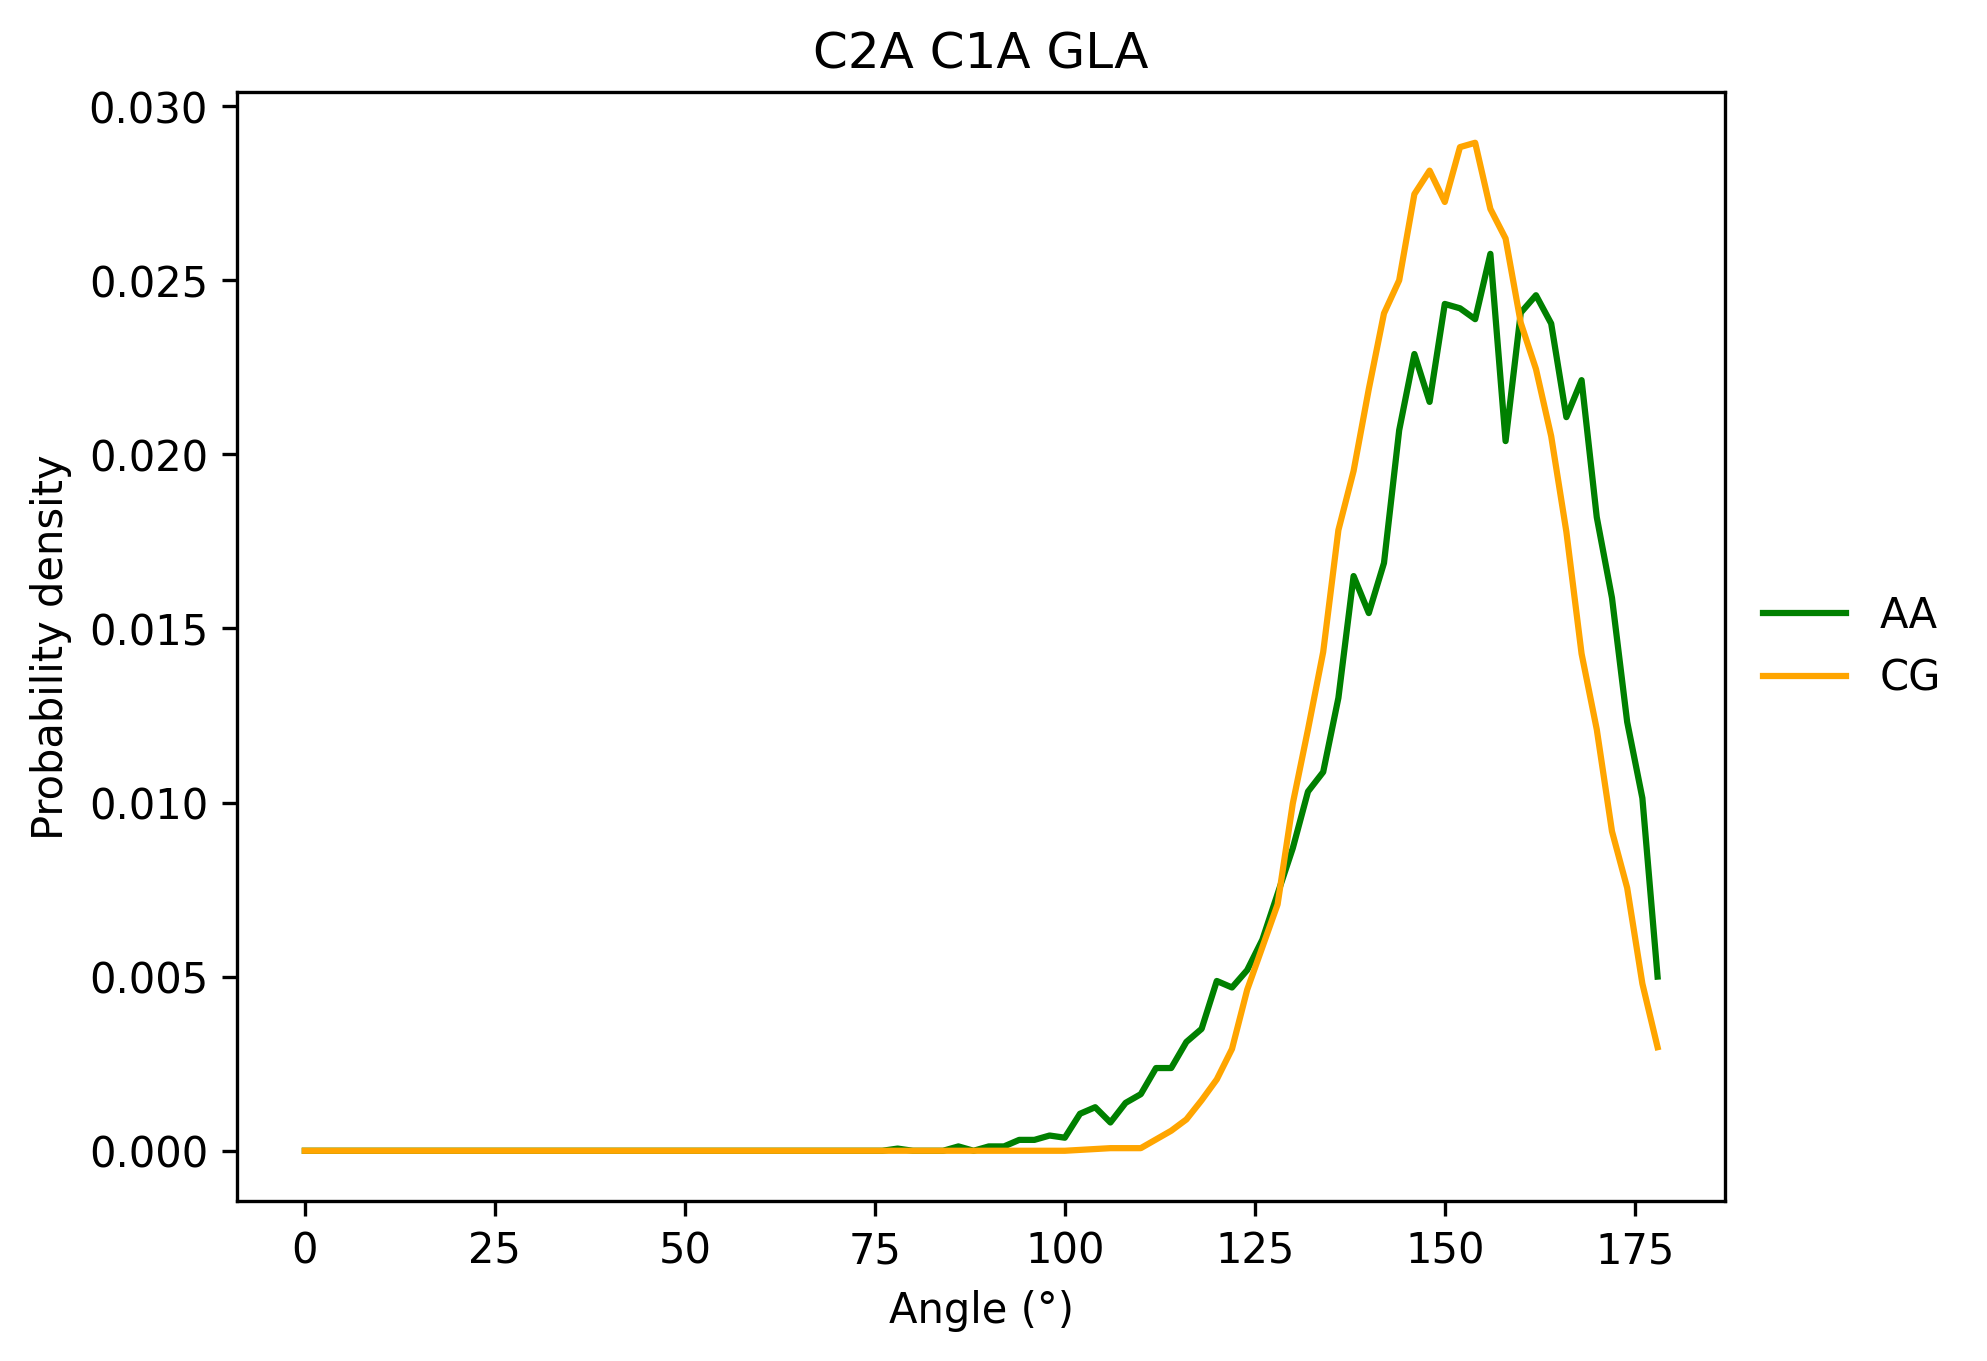

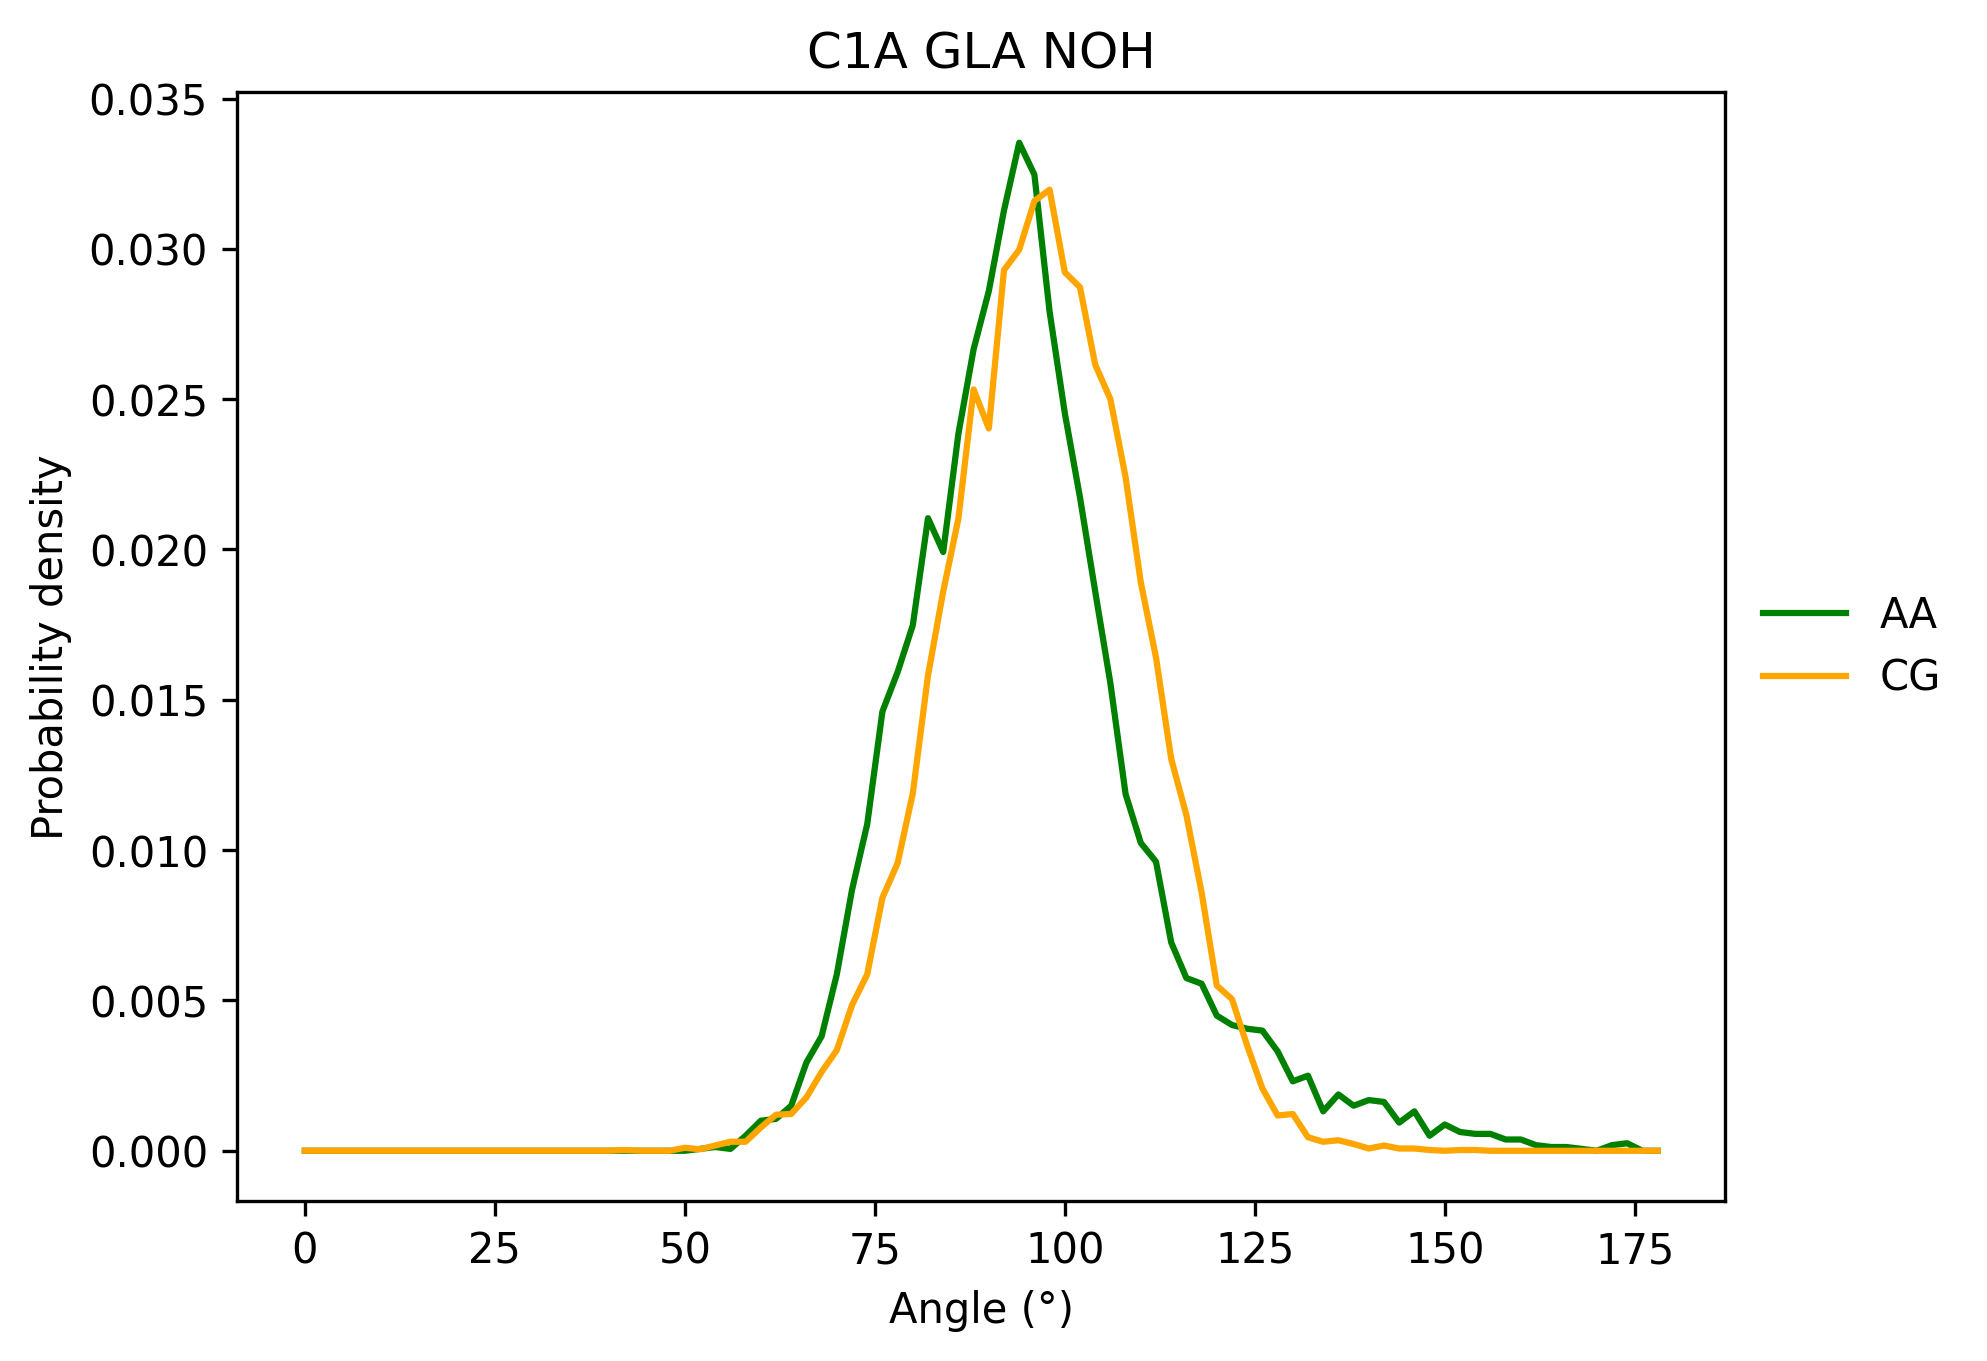

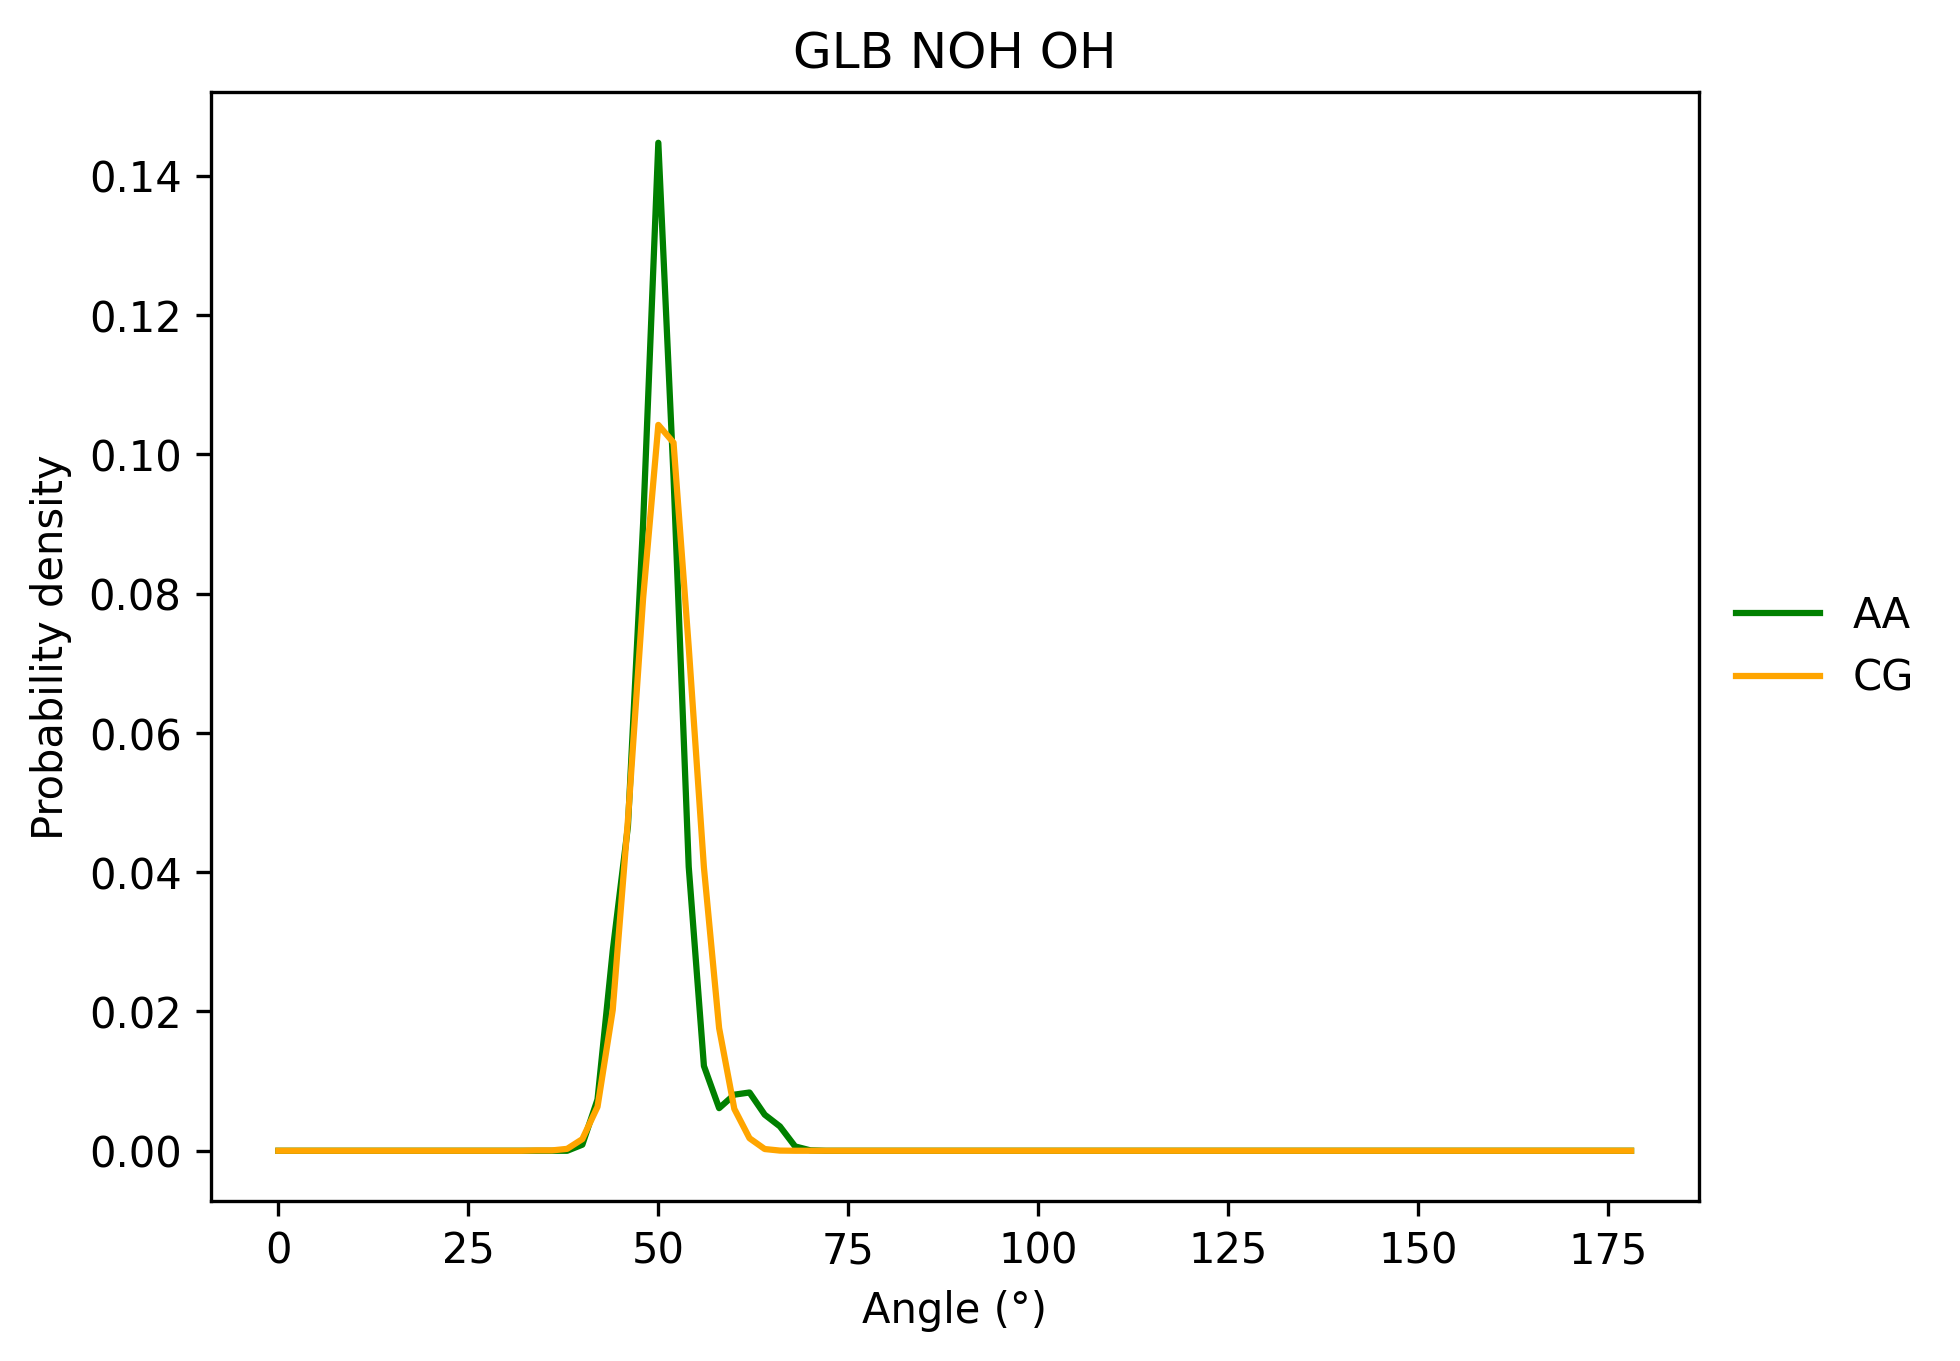

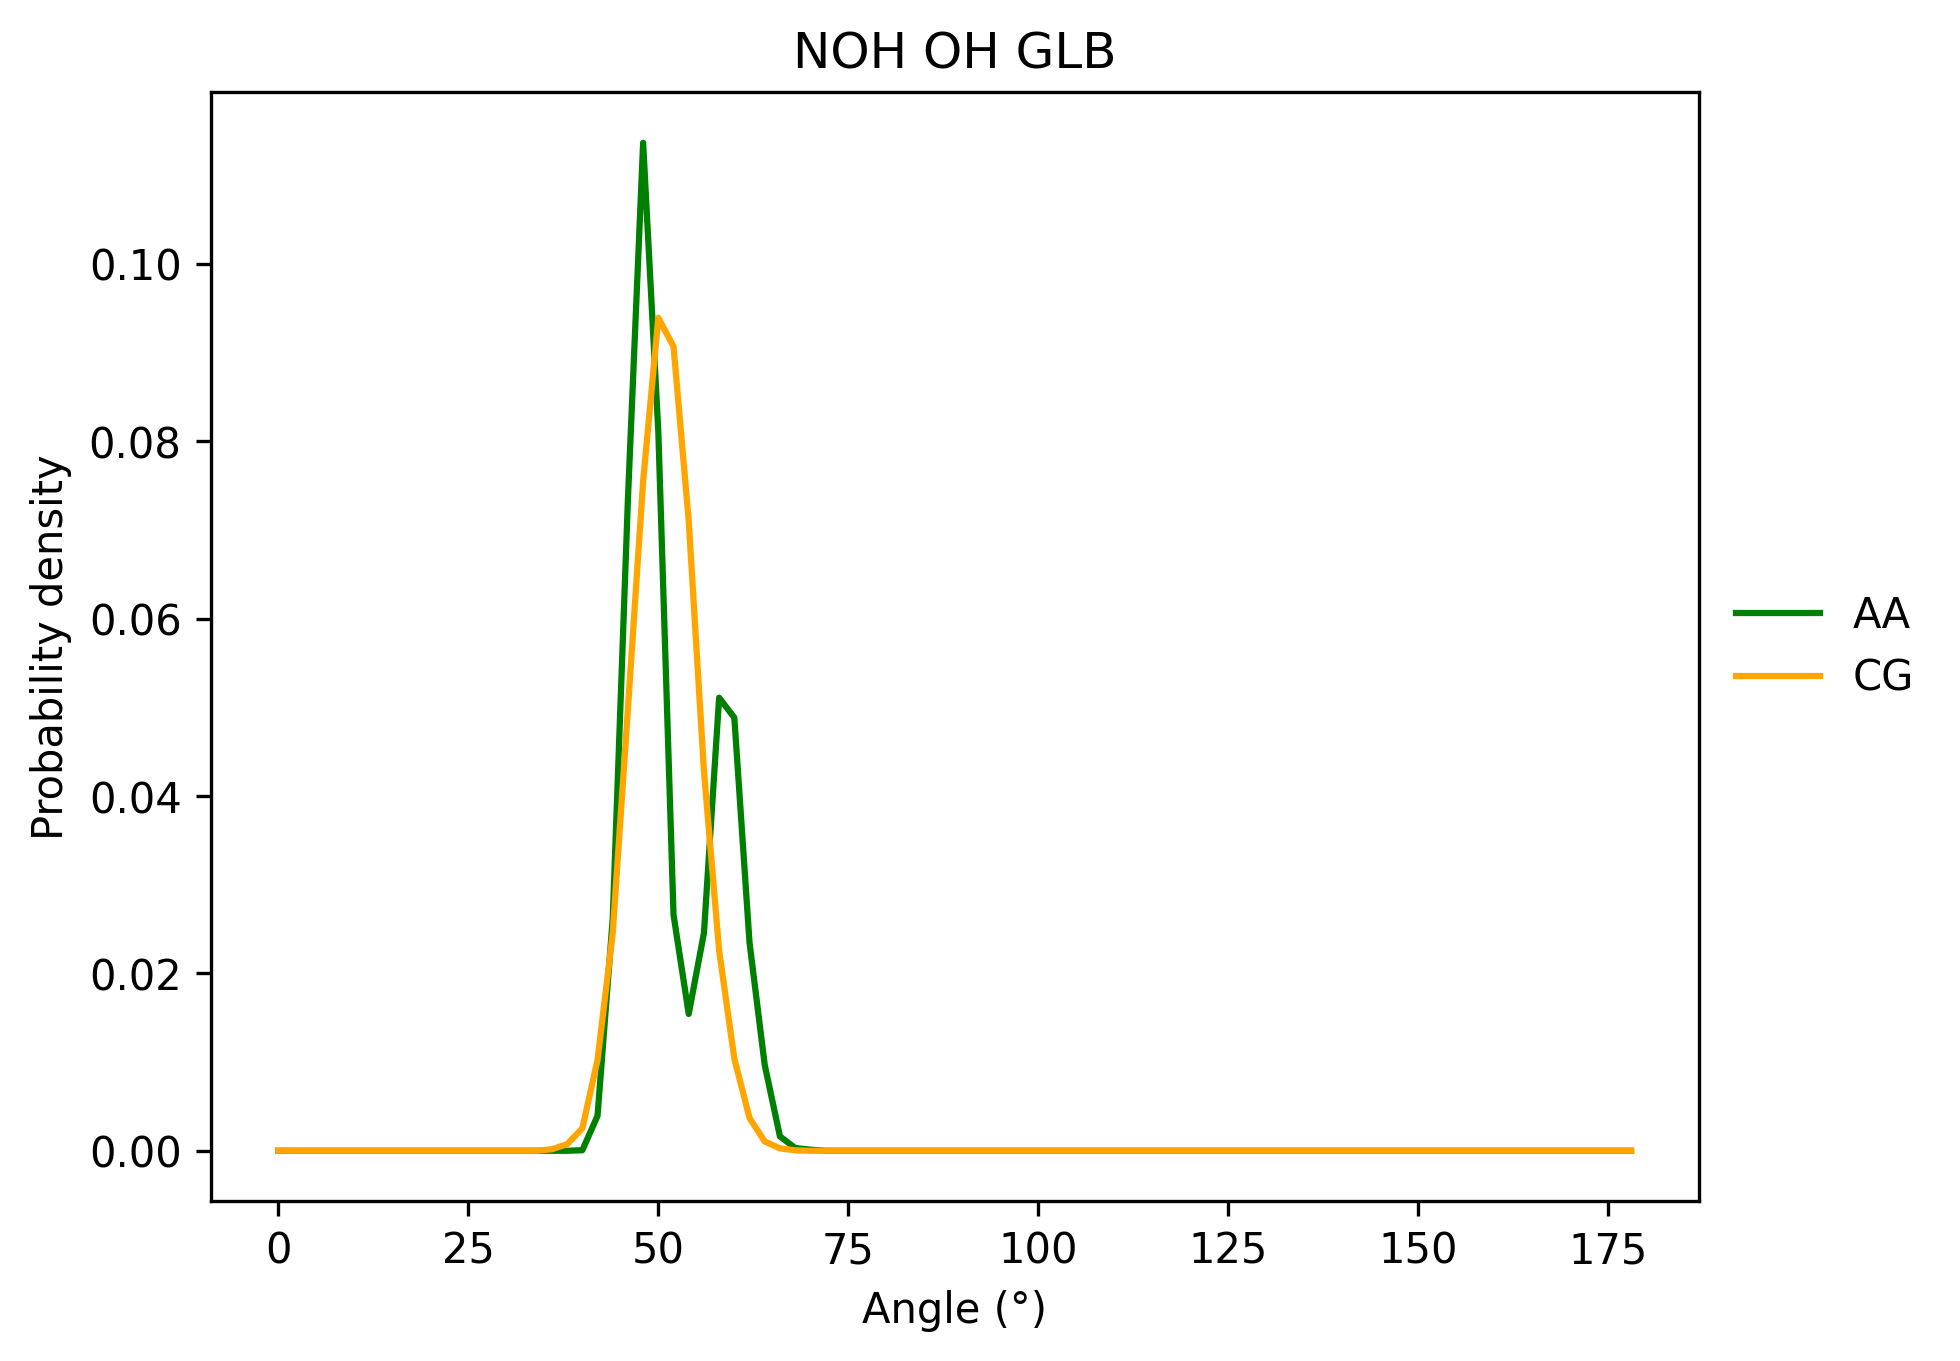

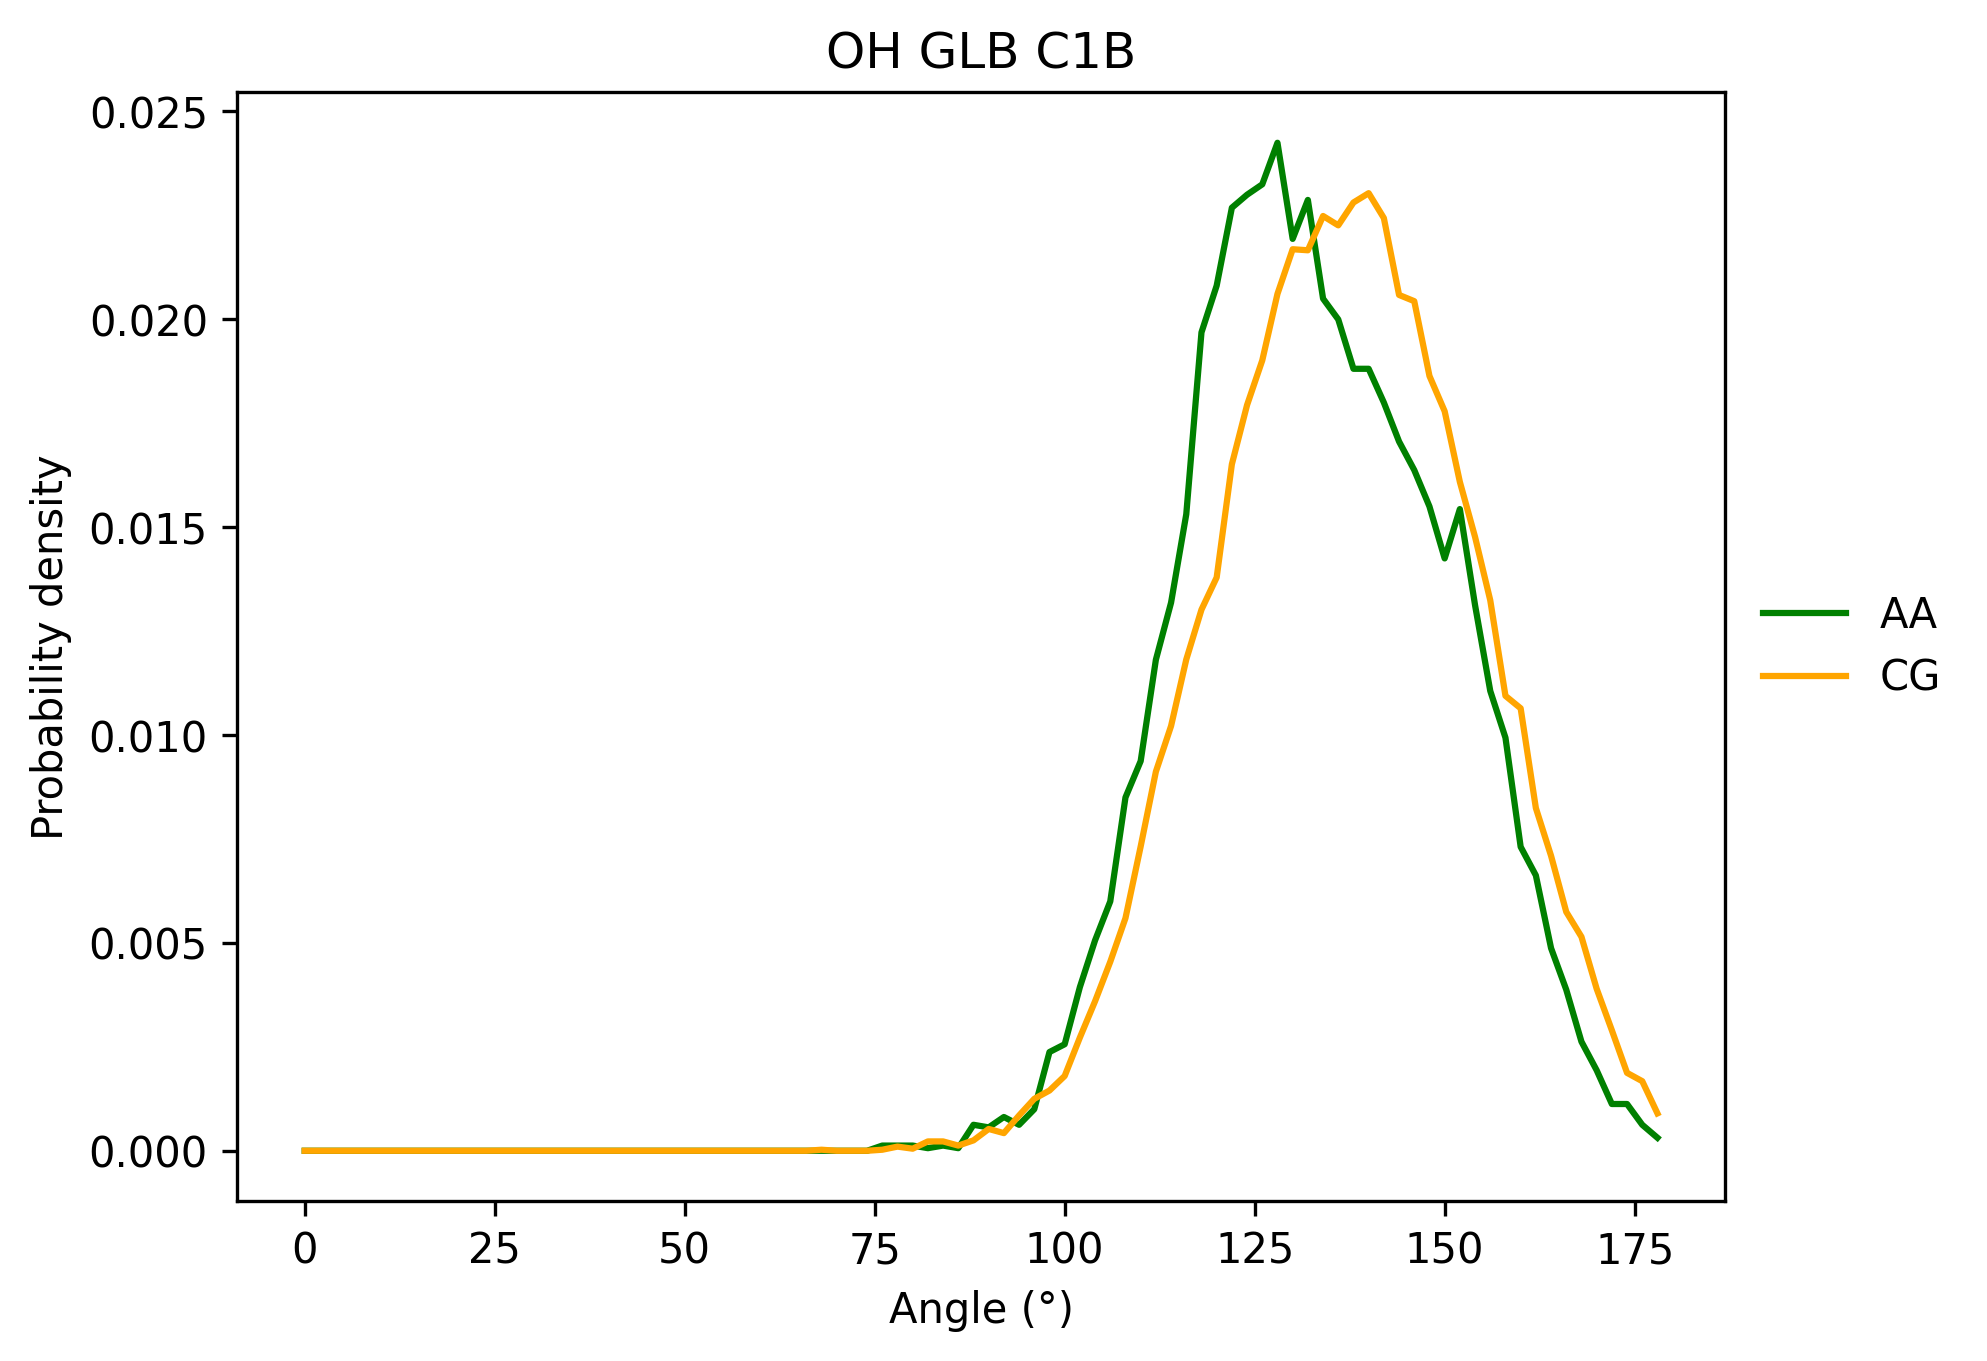

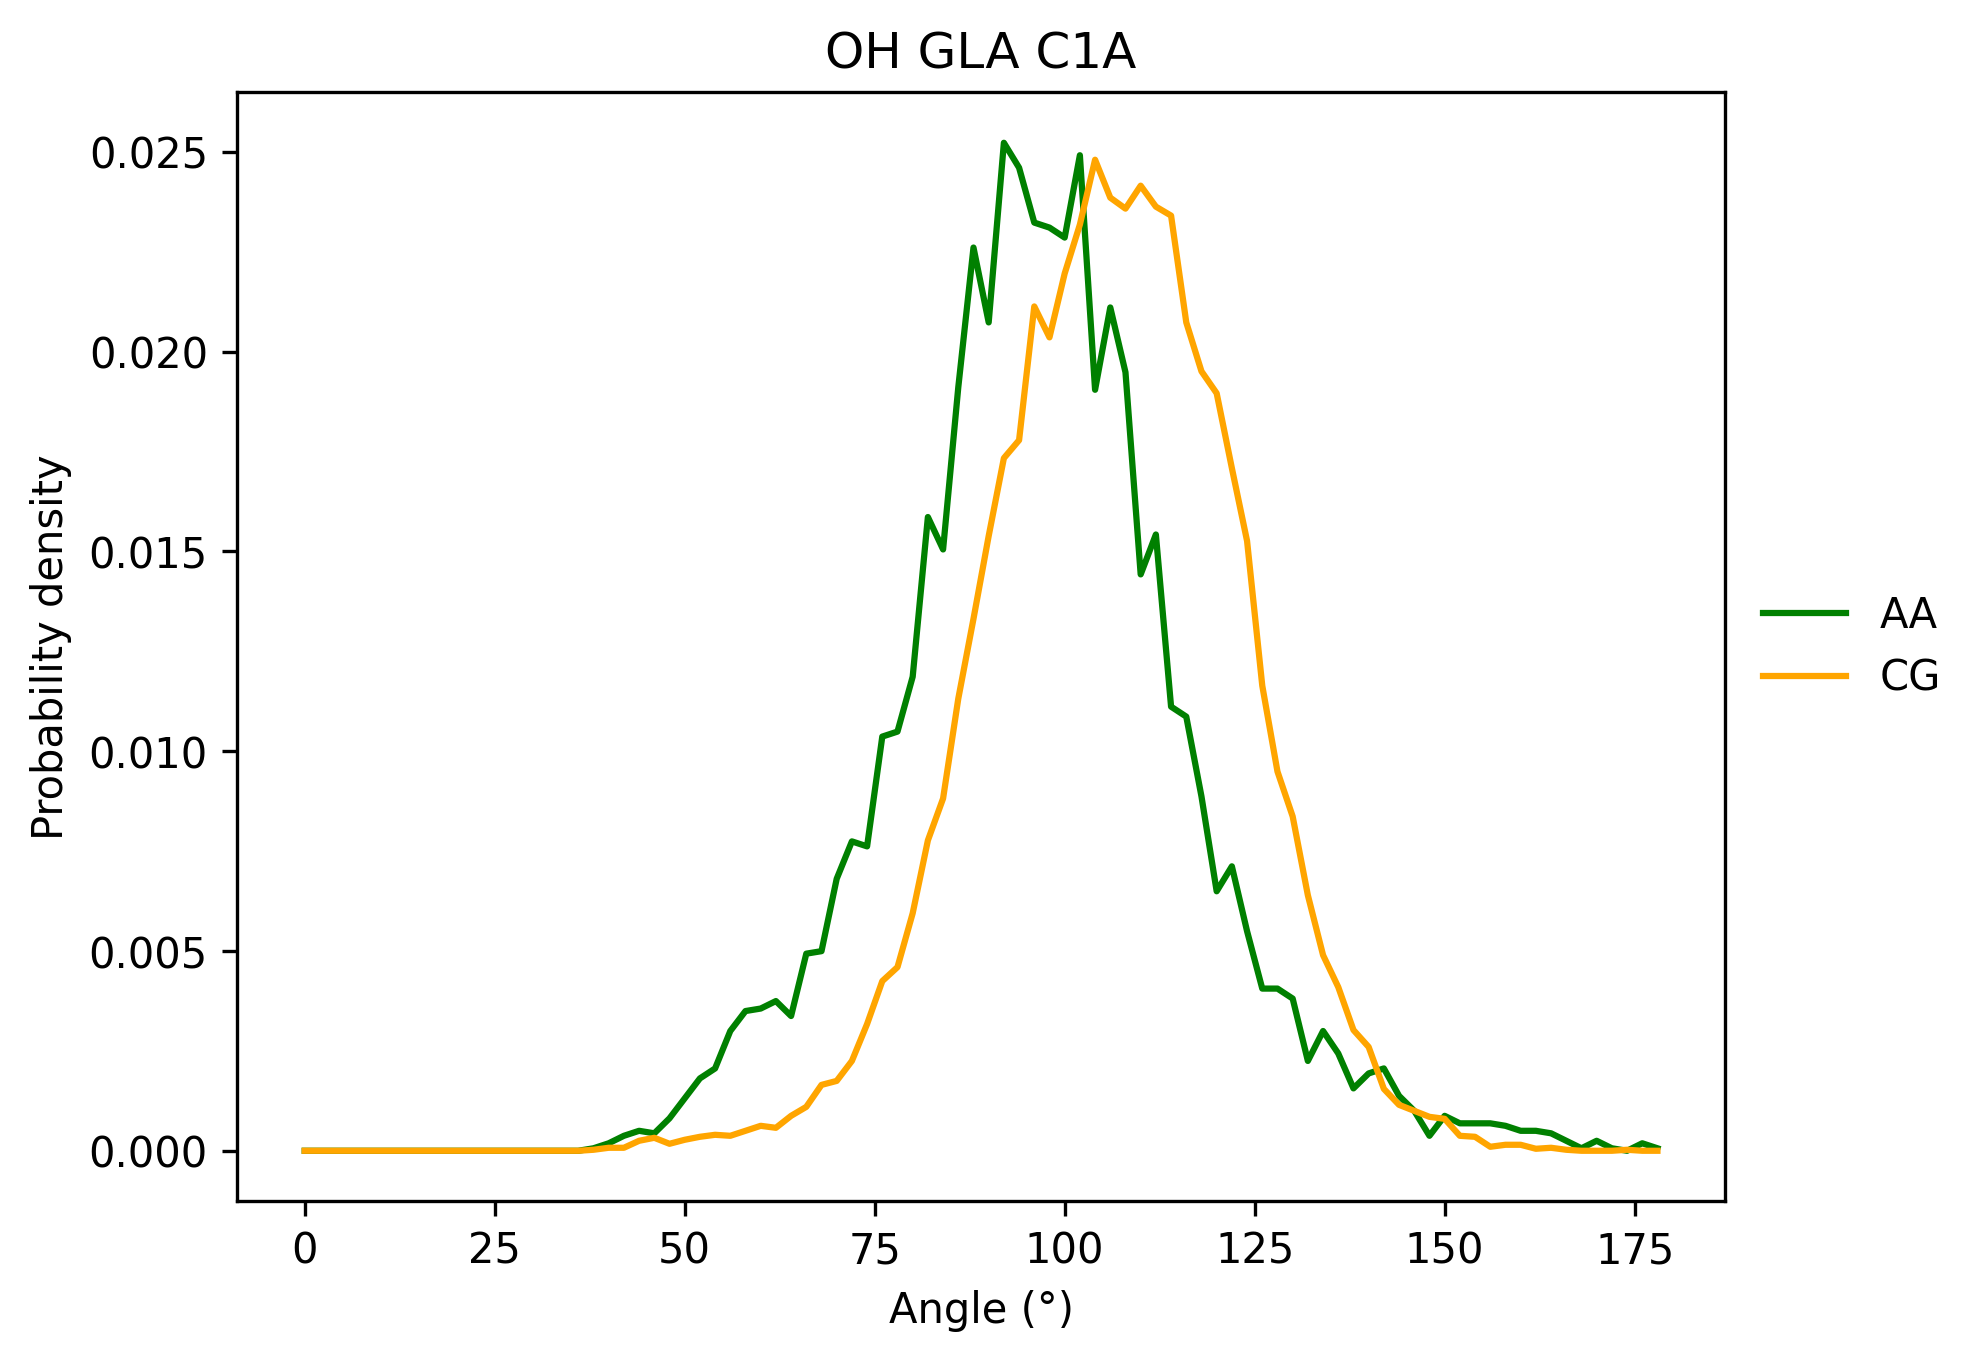

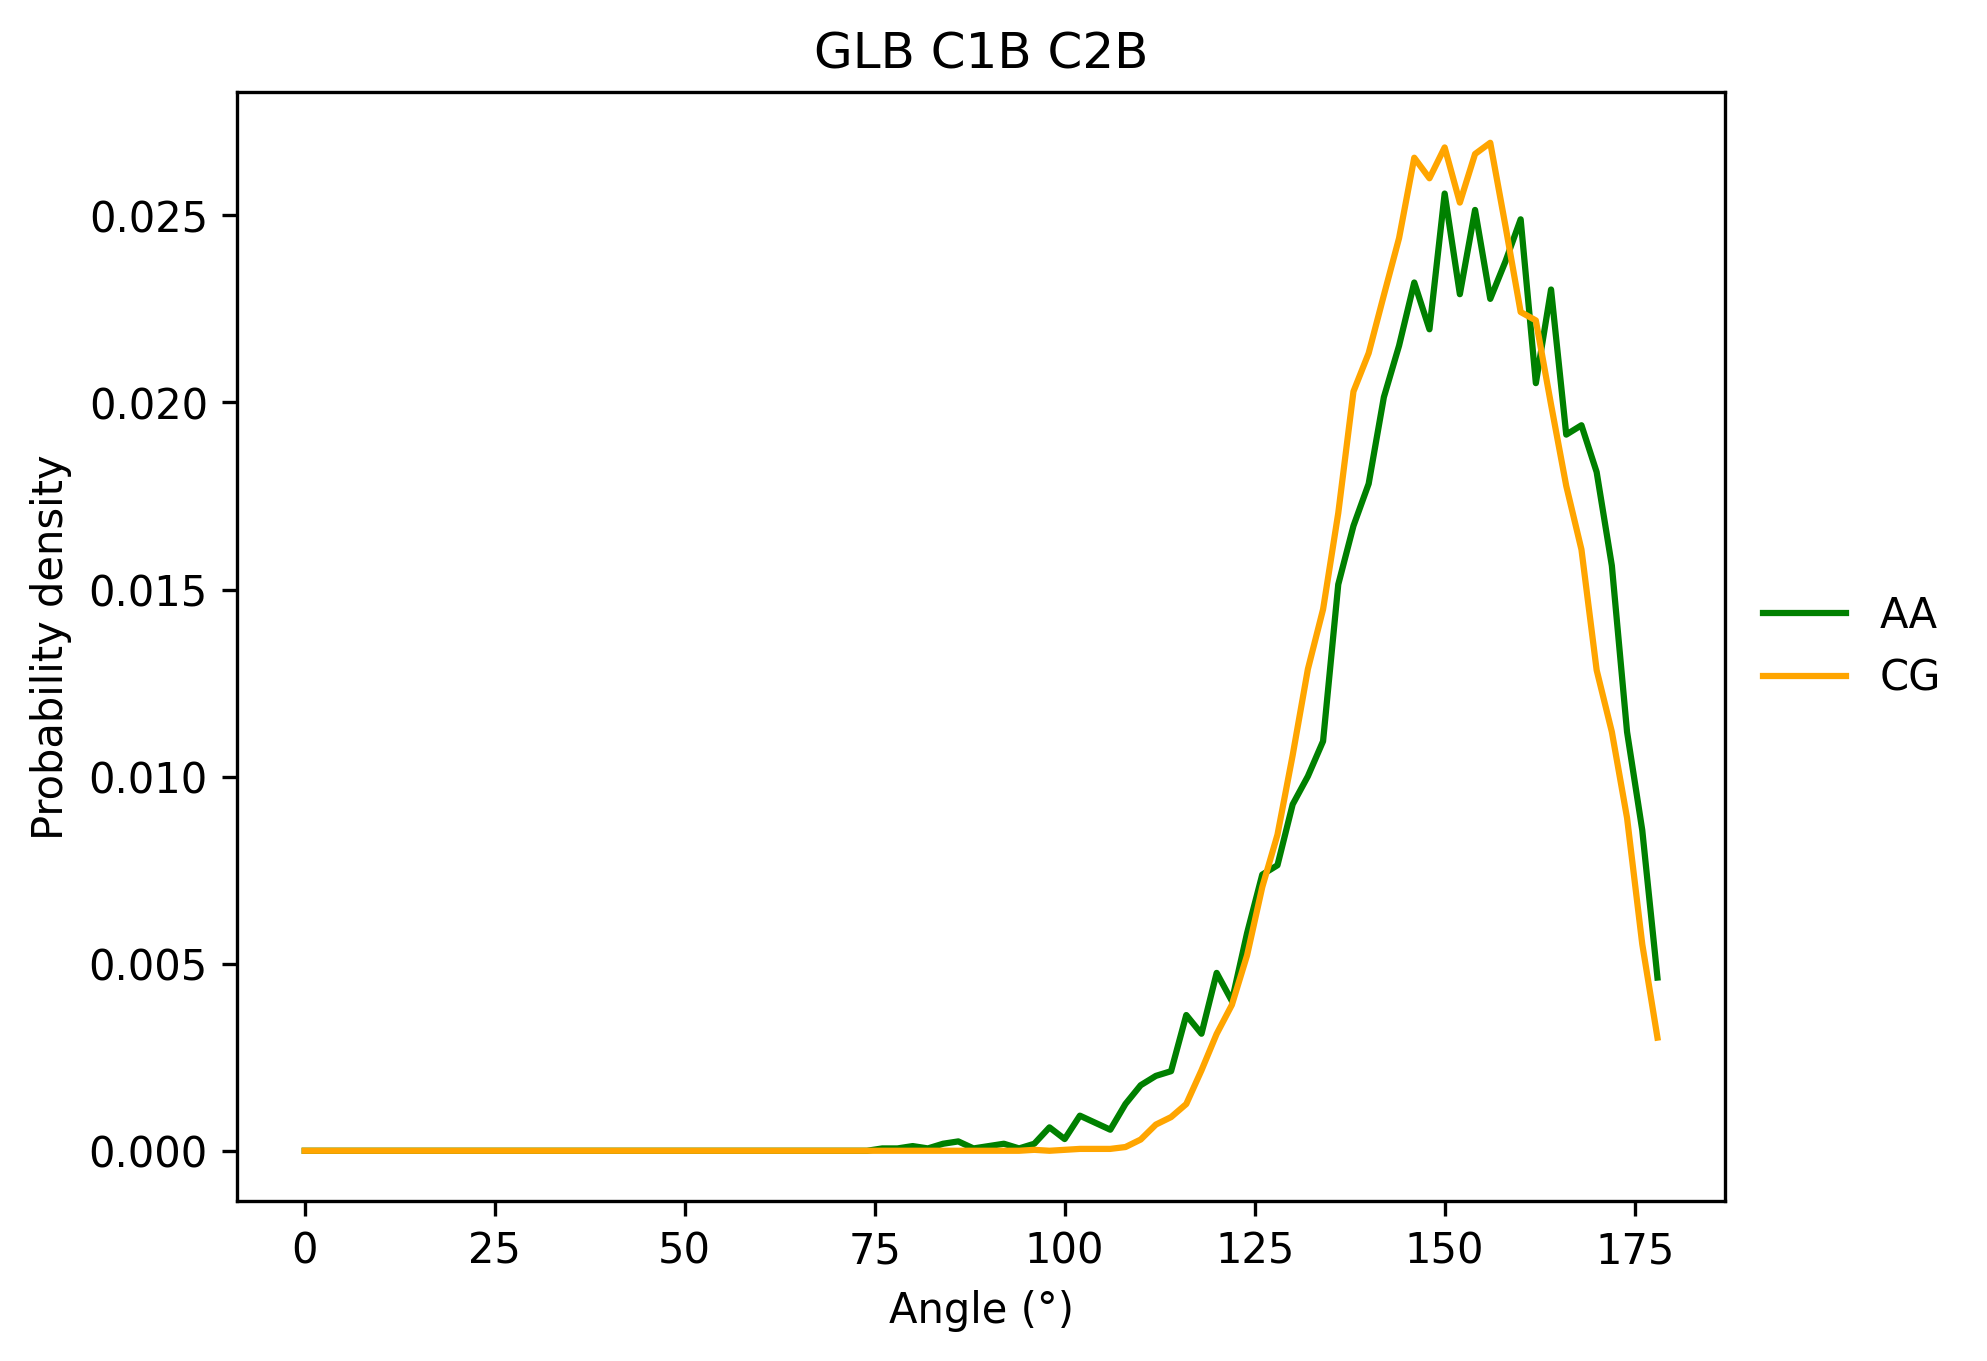

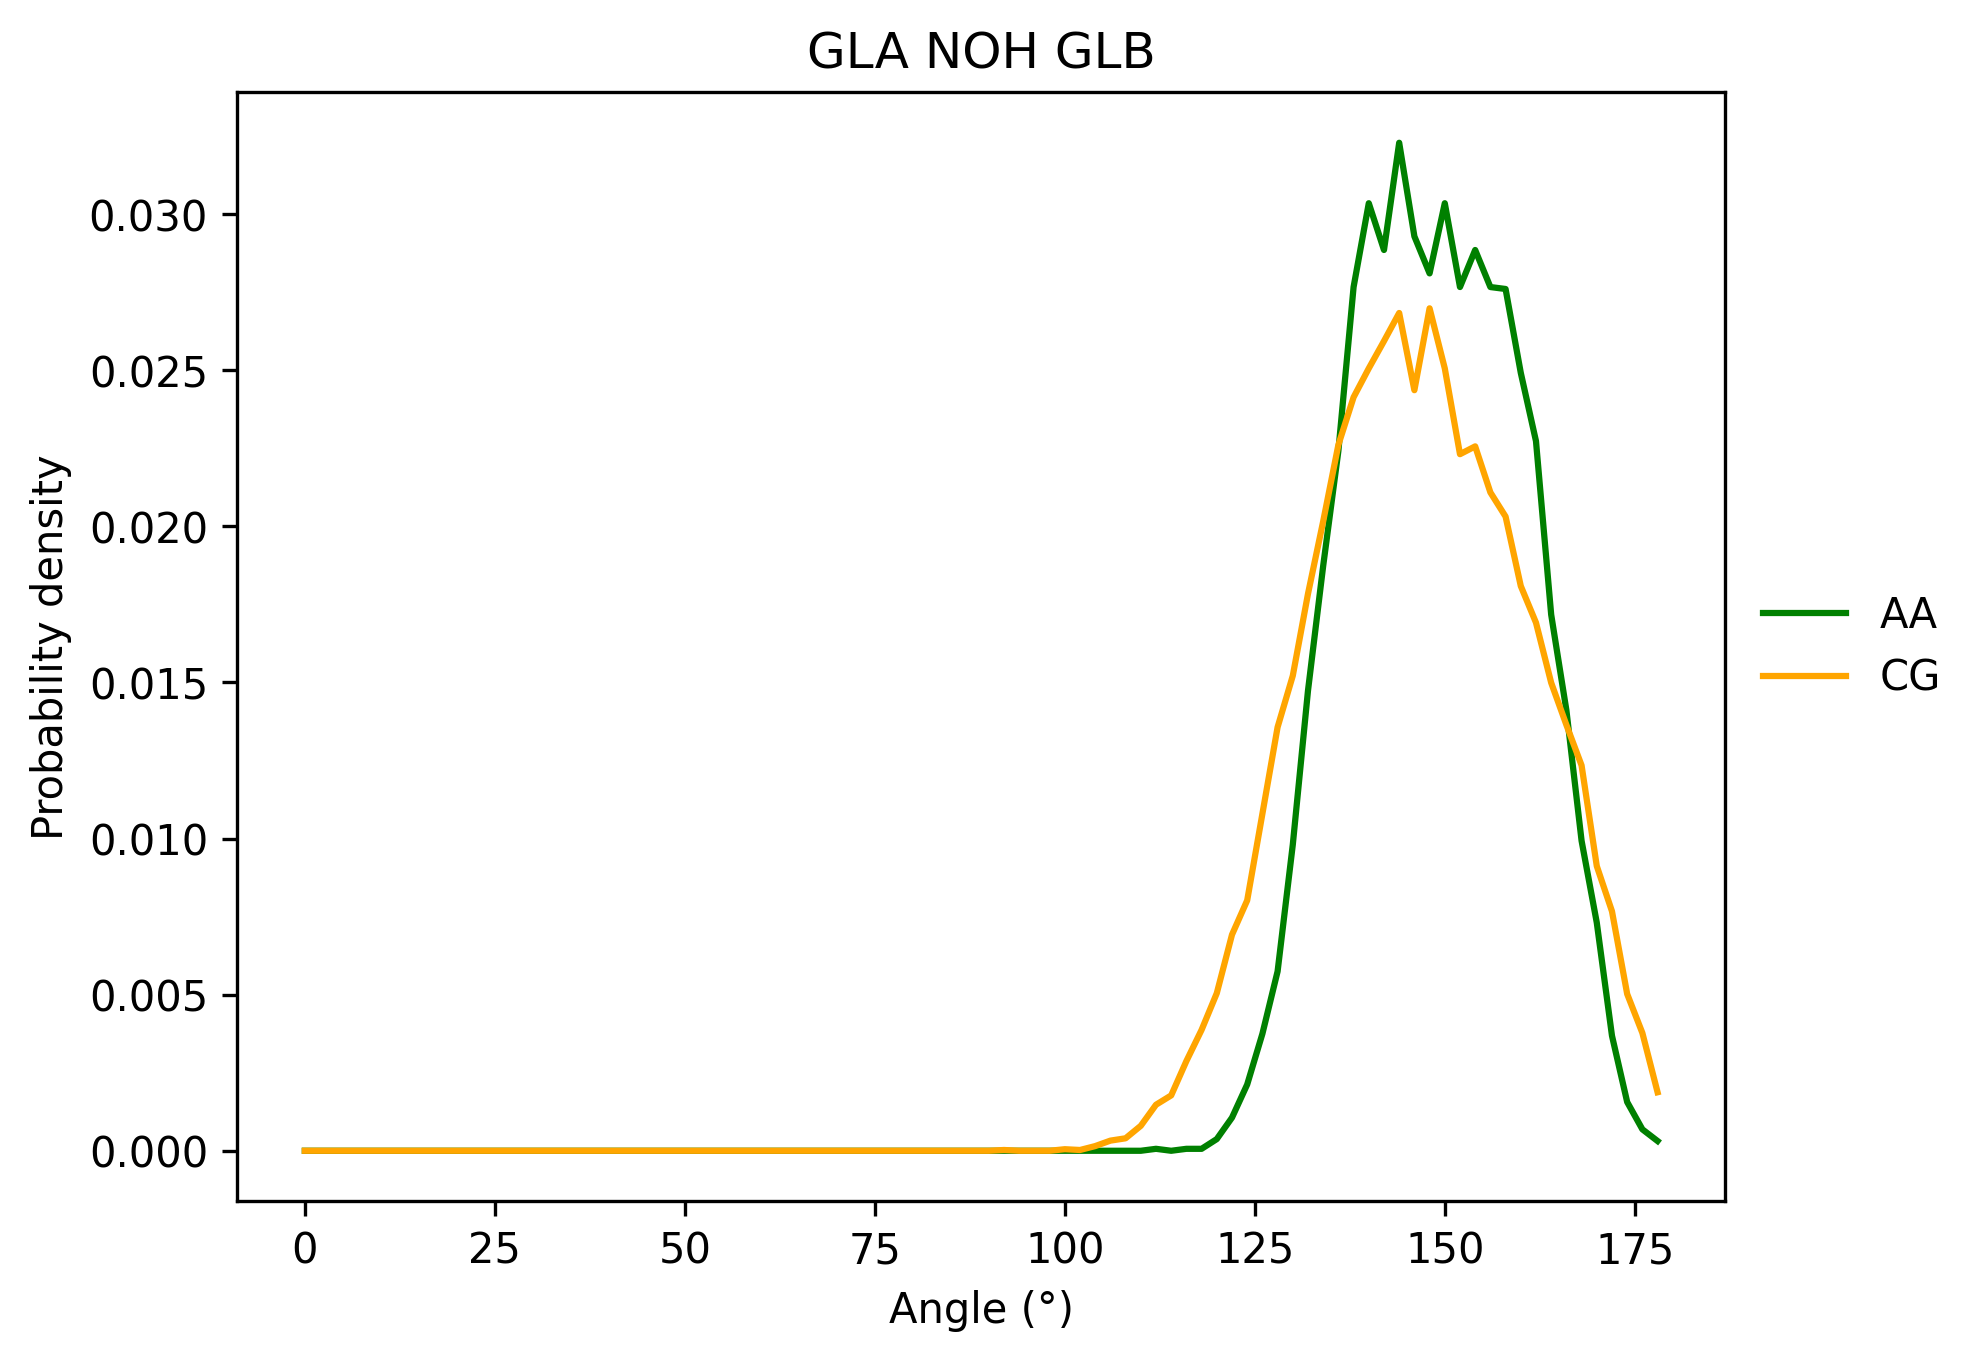

In [49]:
for angle in List_angles:
    HAA,BAA = np.histogram(np.array(ang_aa)[angle,:], bins=bins_angl, density=True)
    HCG,BCG = np.histogram(np.array(ang_cg)[angle,:], bins=bins_angl, density=True)

    plt.plot(bins_angl_x, HAA, label='AA', color='green')
    plt.plot(bins_angl_x, HCG, label='CG', color='orange')
    title = ' '.join(i for i in ang_tgts[angle[0]])
    plt.title(title) 
    plt.xlabel('Angle (°)')
    plt.ylabel('Probability density')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.savefig('{}_BL_angle.png'.format(title), dpi=300, bbox_inches='tight')
    plt.show()

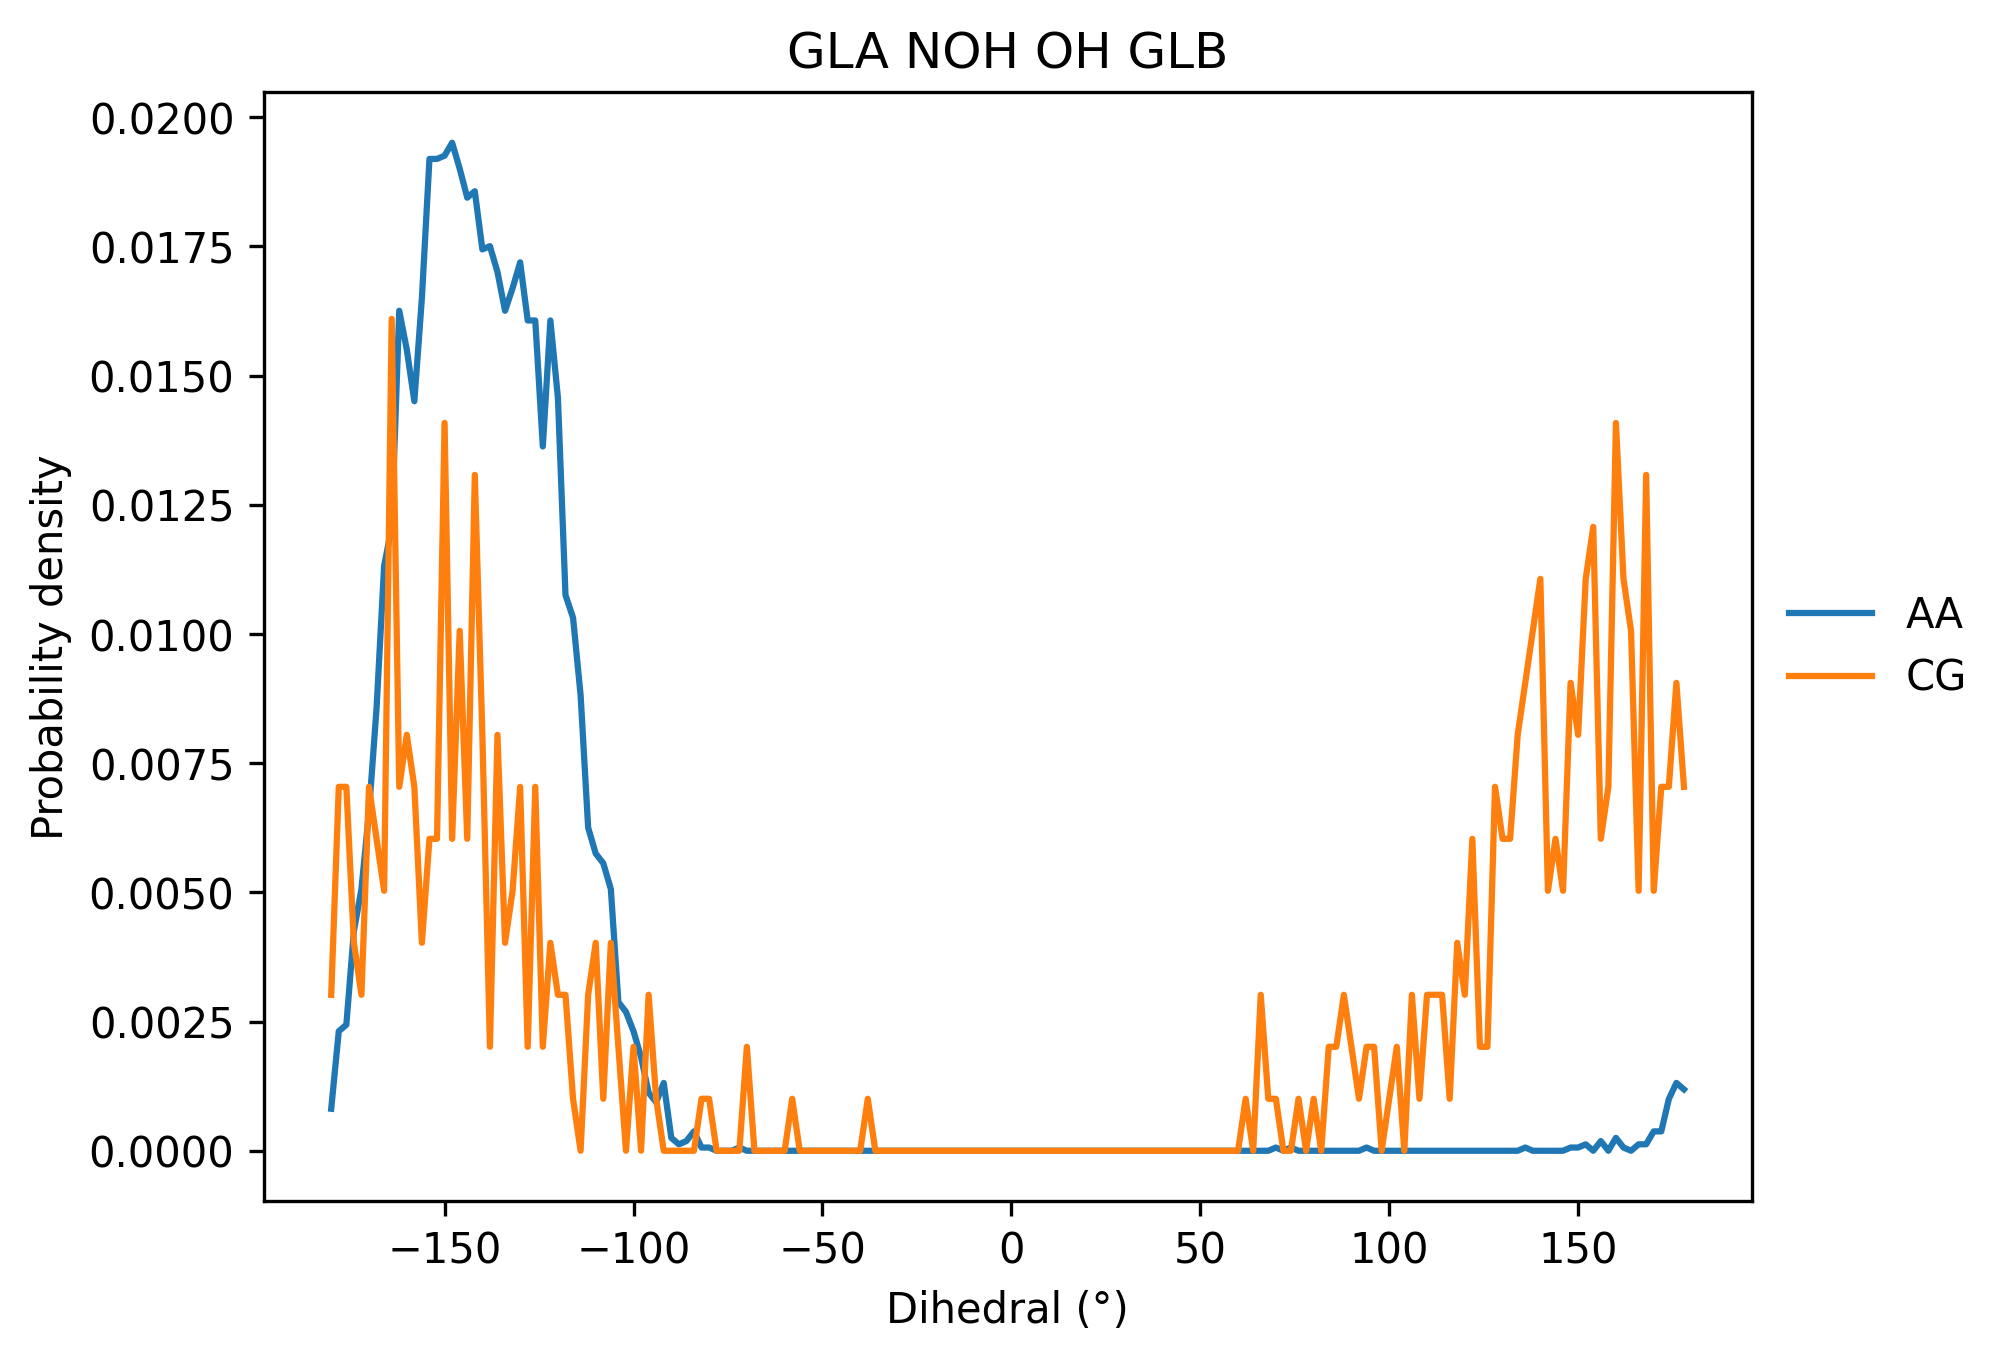

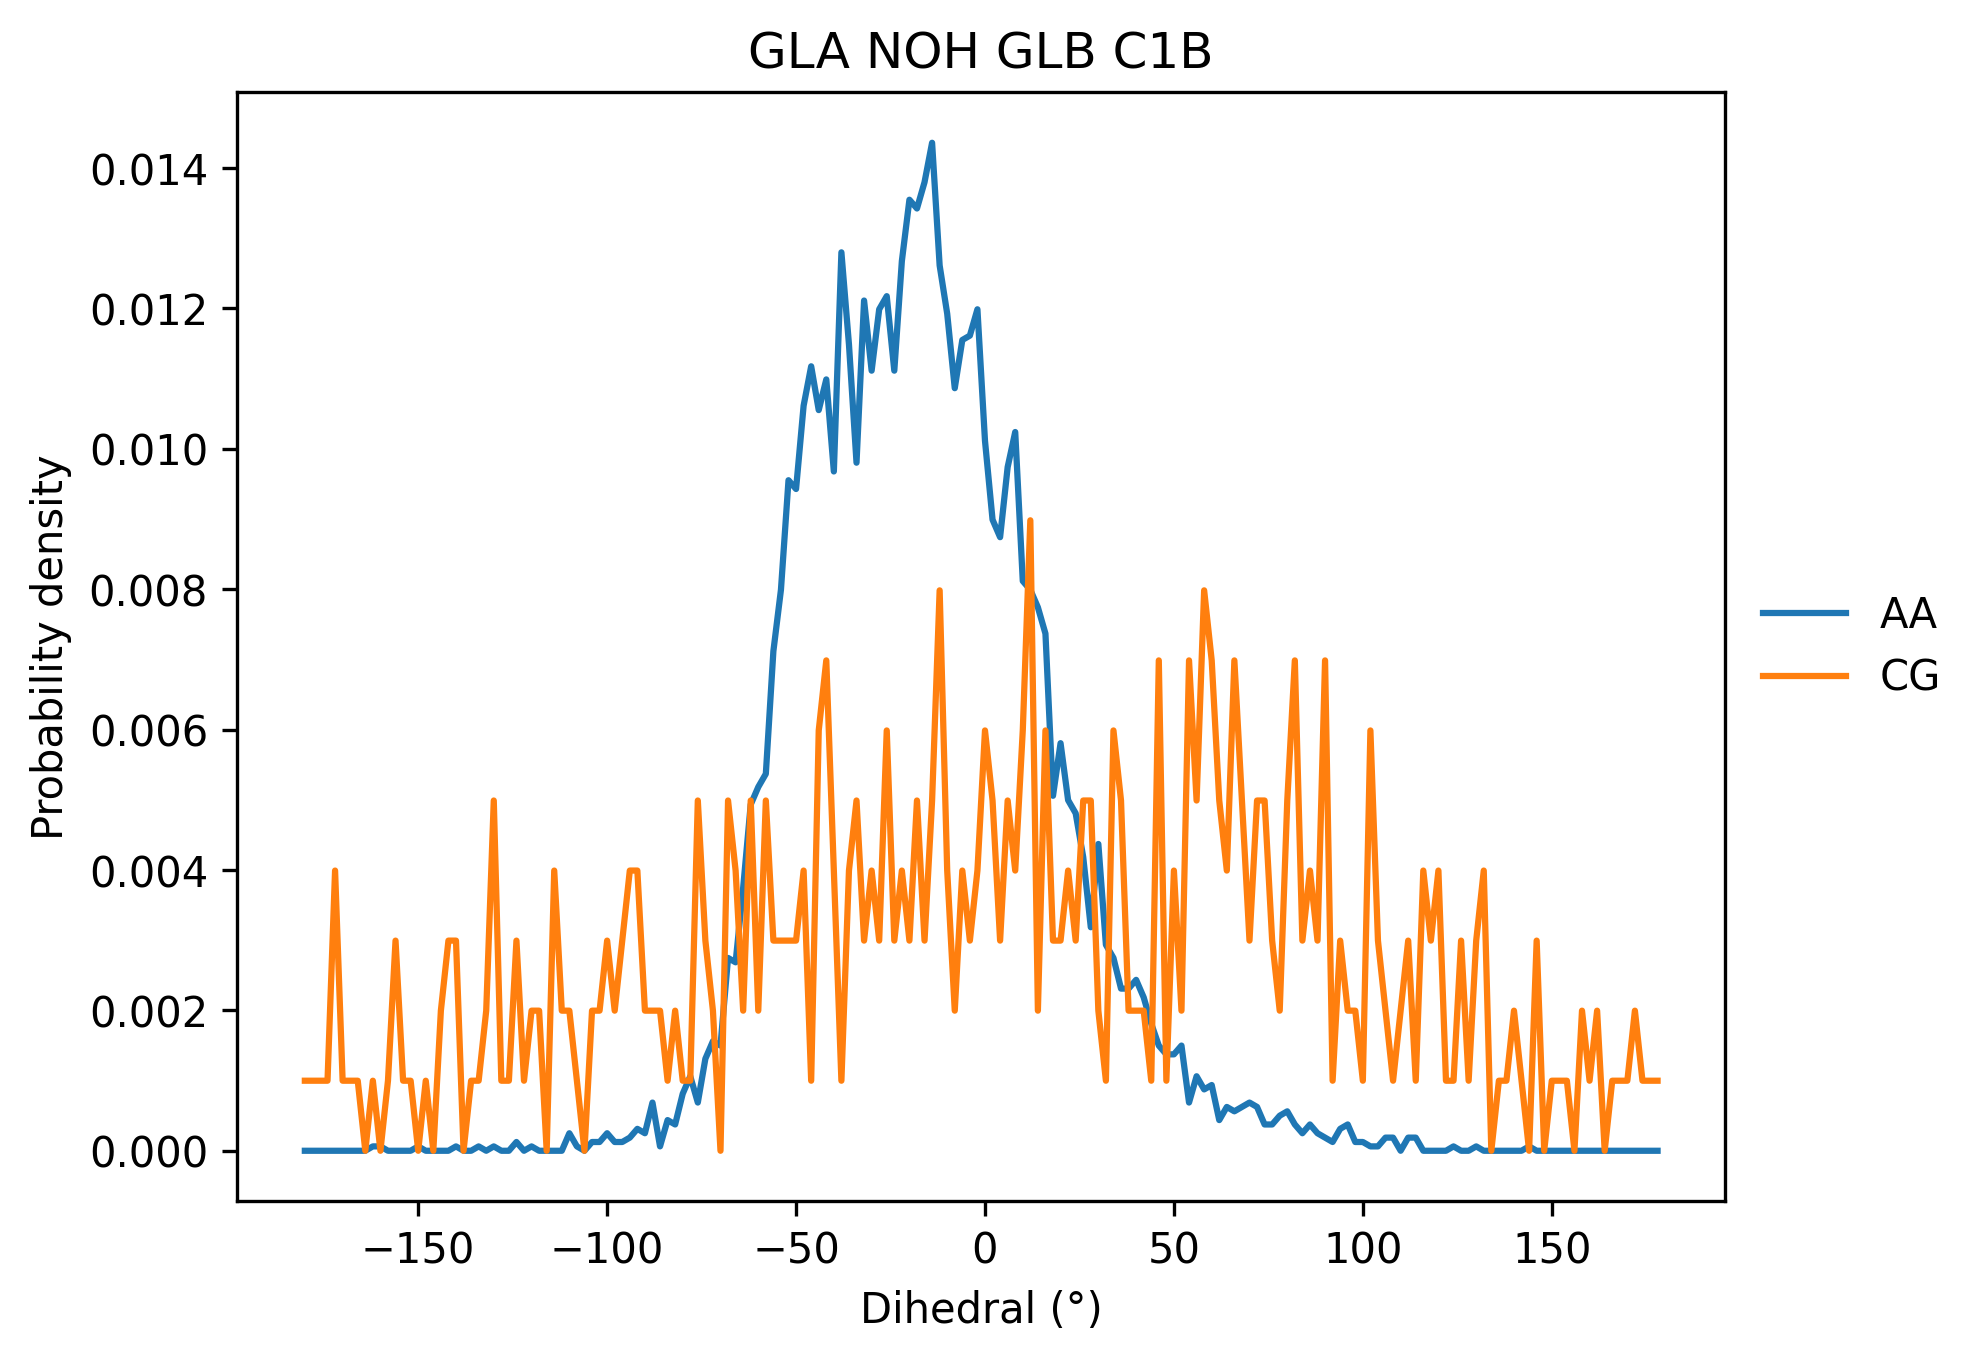

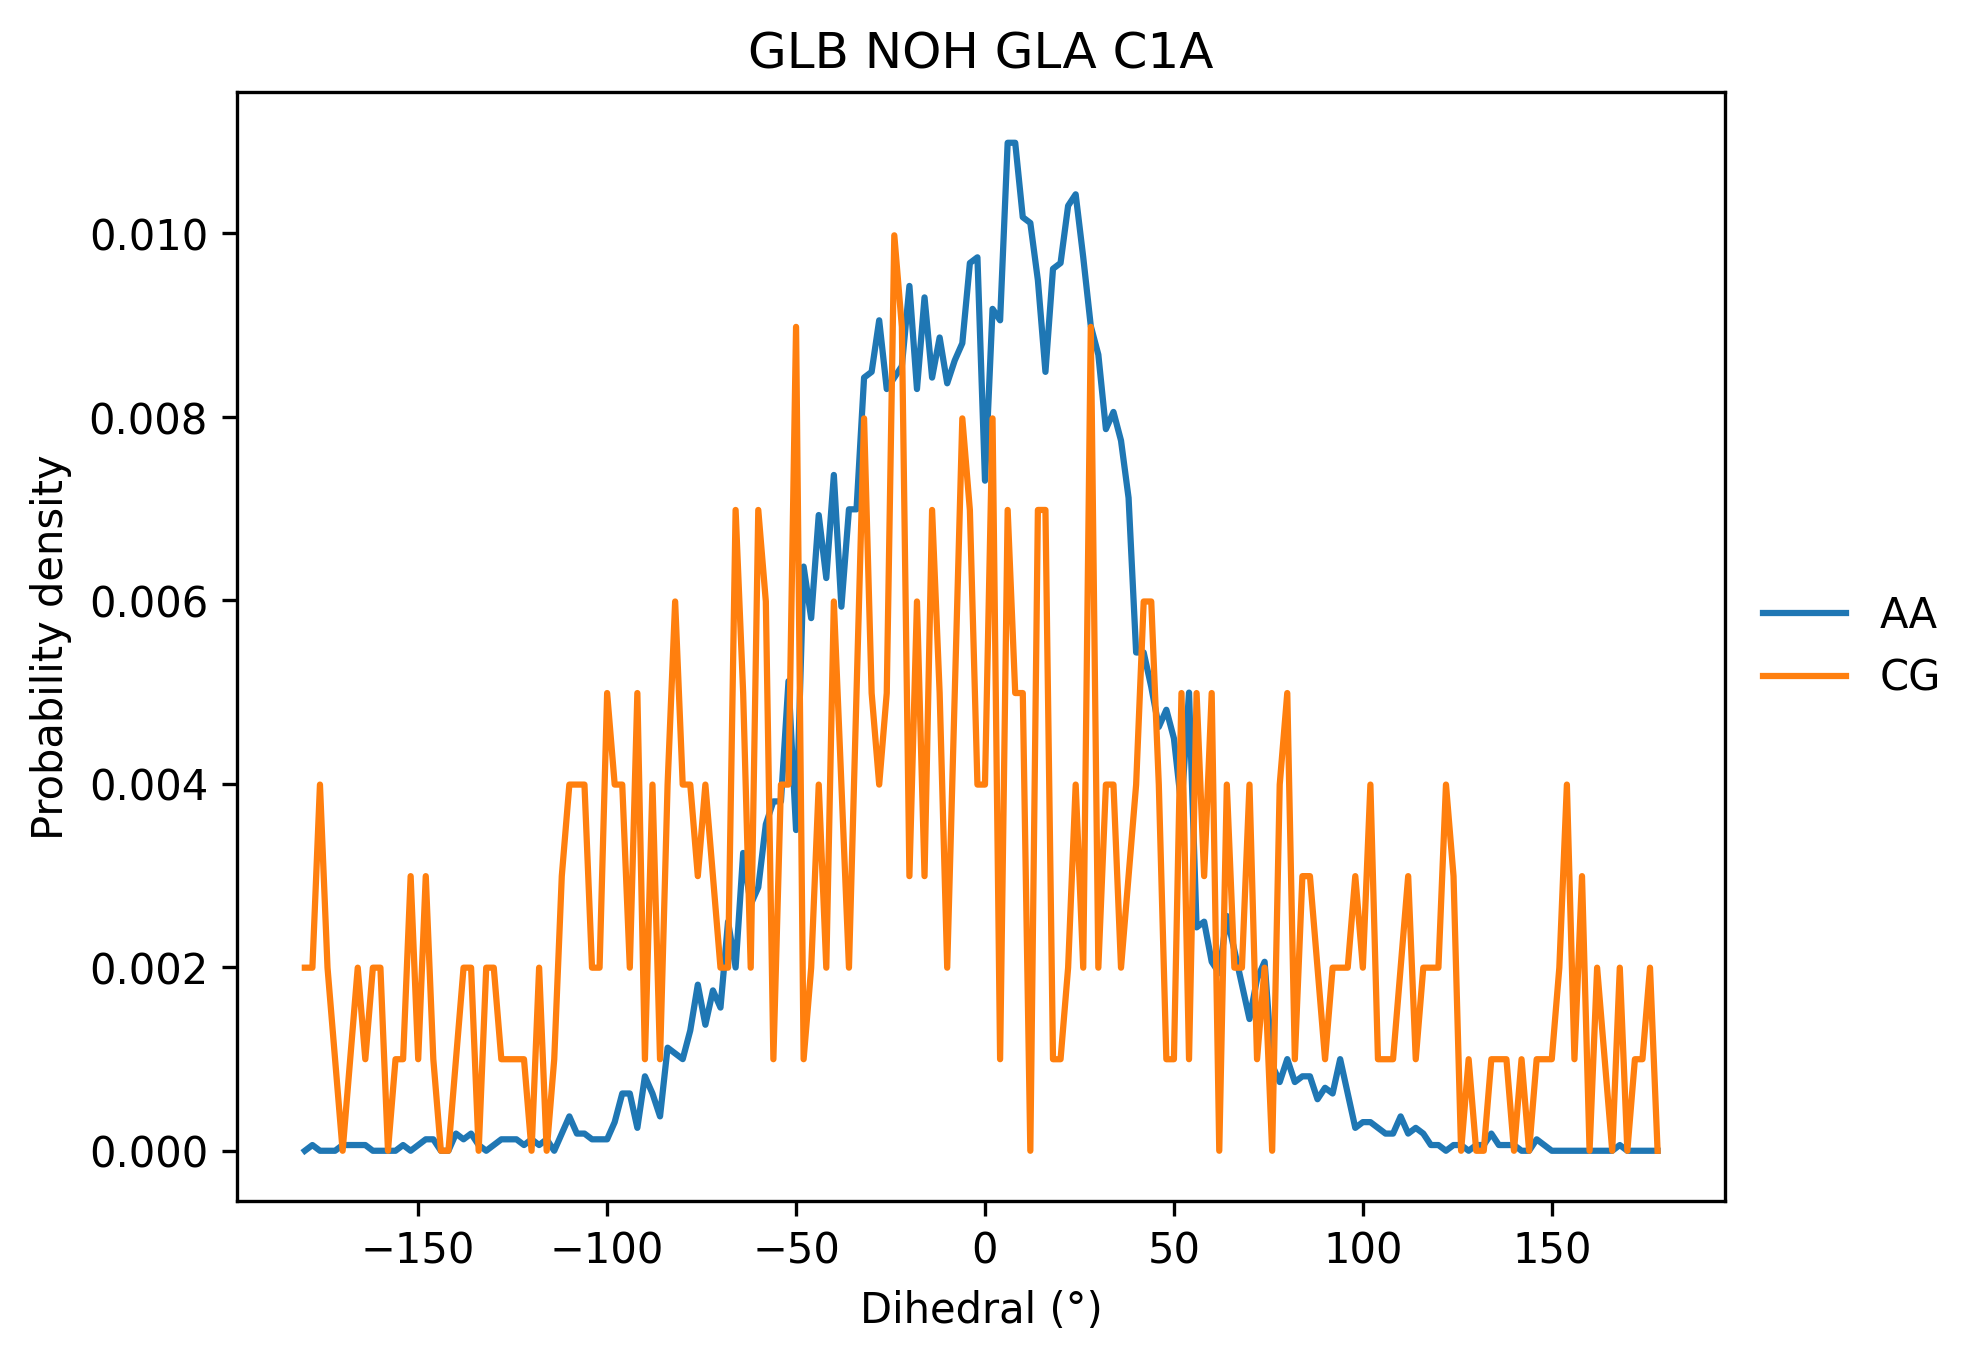

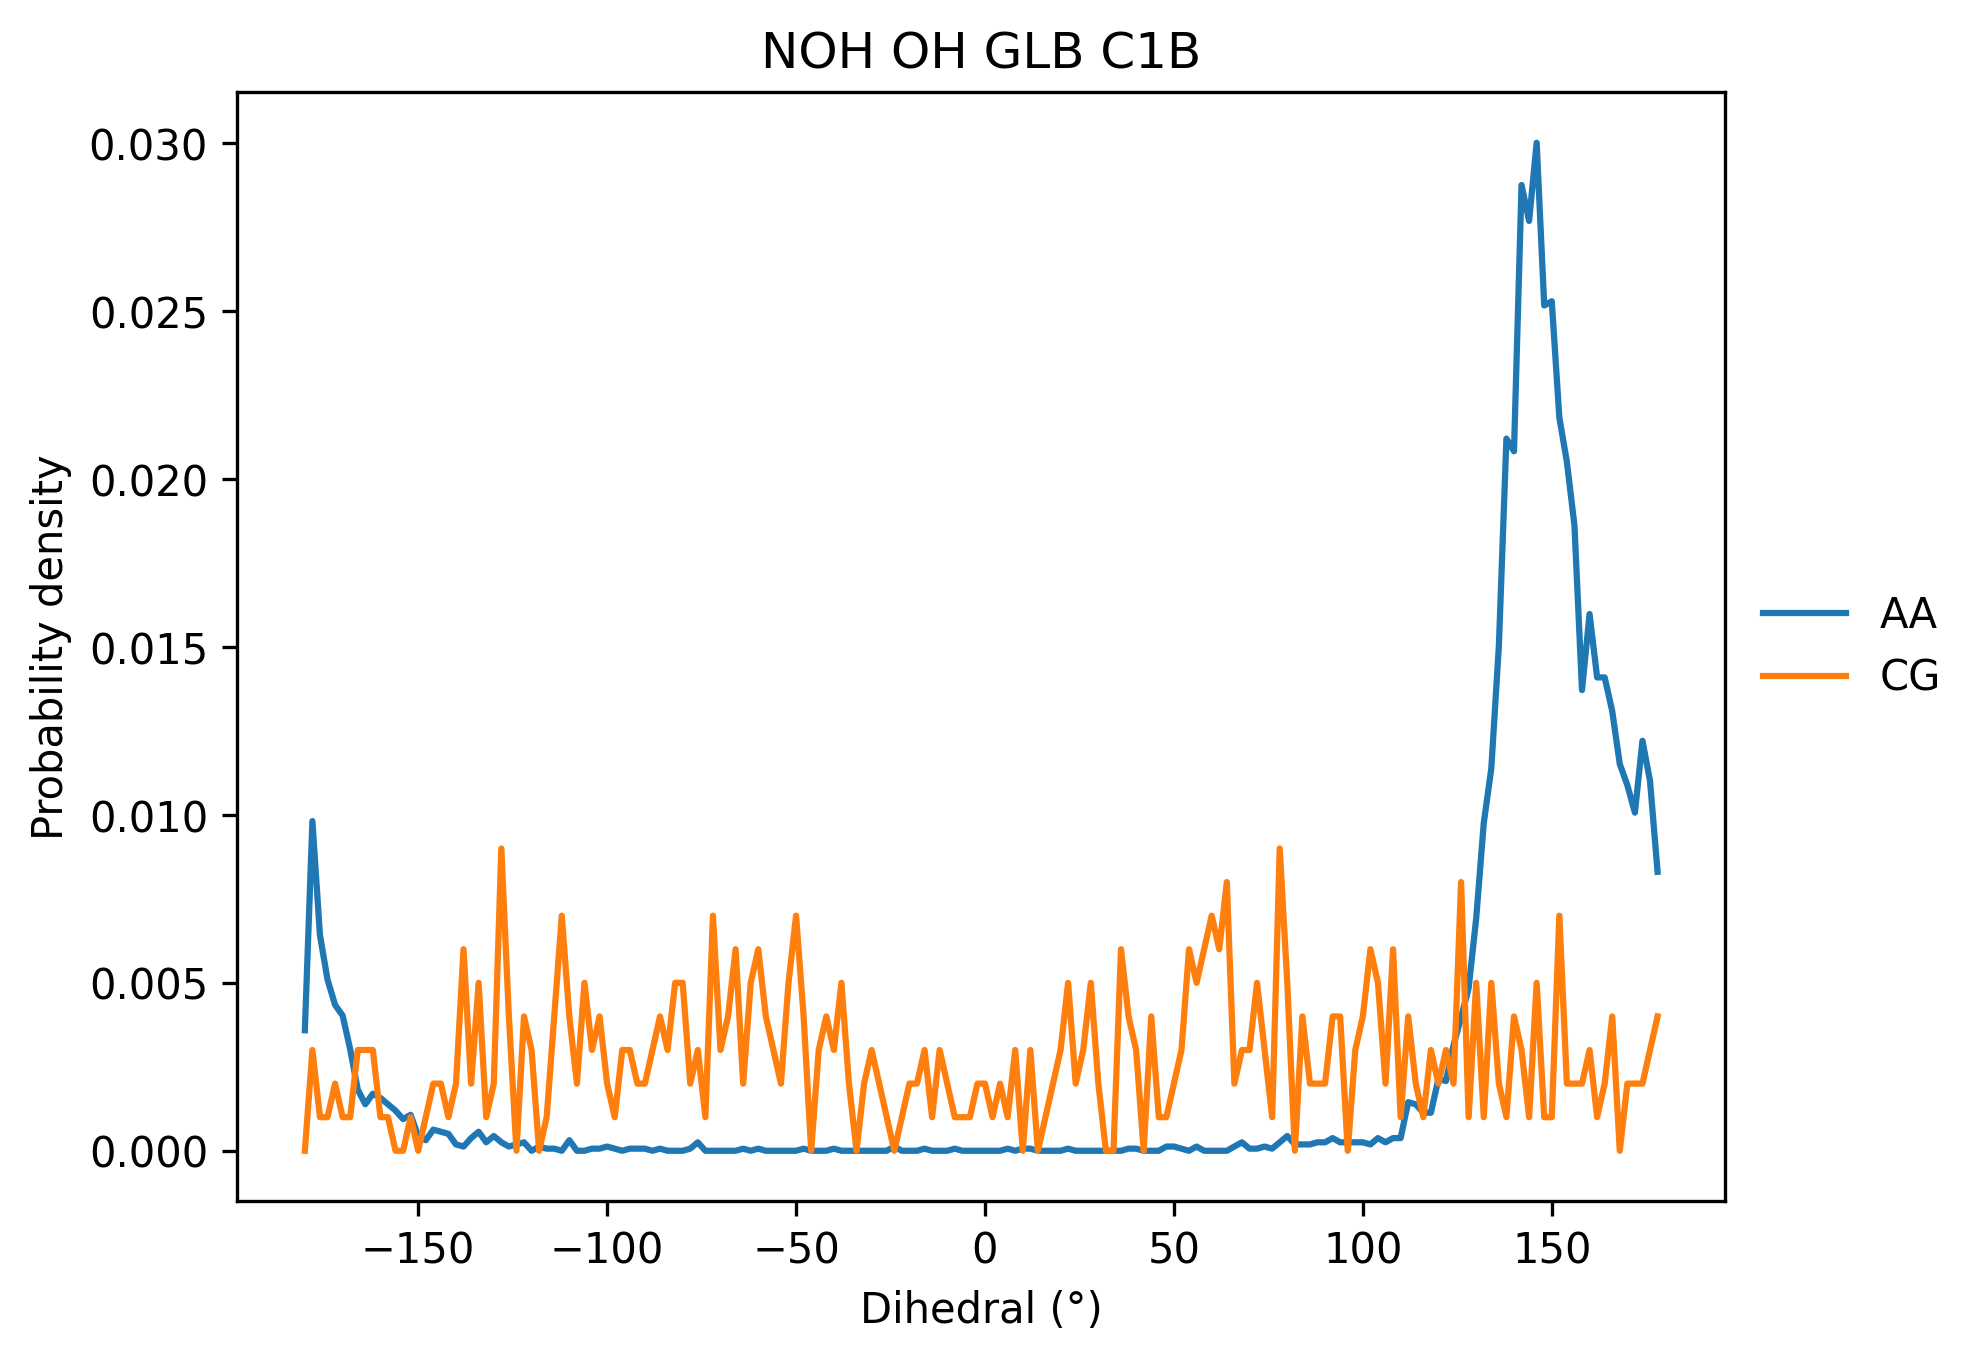

In [50]:
for dihed in List_dihed:

    HAA,BAA = np.histogram(np.array(dihed_aa)[dihed,:], bins=bins_dihed, density=True)
    HCG,BCG = np.histogram(np.array(dihed_cg)[dihed,:], bins=bins_dihed, density=True)


    plt.plot(bins_dihed_x, HAA, label='AA')
    plt.plot(bins_dihed_x, HCG, label='CG')
    title = ' '.join(i for i in dihed_tgts[dihed[0]])
    plt.title(title) 
    plt.xlabel('Dihedral (°)')
    plt.ylabel('Probability density')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.savefig('{}_BL_dihedral.png'.format(title), dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
## Check average APL with AA sims. You have the same amount of POPC in there, so it should be a fine estimate

## APL

In [51]:
u_aa = md.Universe('../step6.0_minimization.gro',
                   '../AA_whole.xtc')

## Open CG
u_cg = md.Universe('p.gro', 'p.xtc')


/home/ltr/anaconda3/envs/jupyter_env/lib/python3.10/site-packages/MDAnalysis/coordinates/XDR.py:240: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn("Reload offsets from trajectory\n "


In [61]:
APL_aa = []
for ts in u_aa.trajectory[::10]:
    x,y = u_aa.dimensions[:2]
    no_lipids_leaflet = int(np.unique(u_aa.select_atoms('all and not resname NA CL SOD CLA TIP3P TIP3').resids).shape[0]/2)
    A = x*y
    apl = A / no_lipids_leaflet
    APL_aa.append(apl)


In [64]:
APL_cg = []
for ts in u_cg.trajectory[::10]:
    x,y = u_cg.dimensions[:2]
    no_lipids_leaflet = int(np.unique(u_cg.select_atoms('all and not resname ION NA CL W WN WO').resids).shape[0]/2)
    A = x*y
    apl = A / no_lipids_leaflet
    APL_cg.append(apl)

In [65]:
print (np.average(APL_aa), np.std(APL_aa))
print (np.average(APL_cg), np.std(APL_cg))

61.88339 1.688749
57.52231 1.8658321


In [73]:
(float(np.average(APL_aa)/np.average(APL_cg)) - 1) * 100

7.581543922424316

In [ ]:
### Conclusion, keep GLB as a regular bead and dont use a small bead

In [ ]:
## Then make the final itps